# ✅ apollo-11-sysml-v2 SysML v2 Model Validation

**Generated**: 2026-08-05T14:05:29.685945+00:00  
**Repository**: `apollo-11-sysml-v2`  
**Result**: 28/28 files passed, 0 failed  
**Total Time**: 34.8s

---

Each cell below contains one `.sysml` package file, loaded in dependency order. Re-run this notebook in JupyterLab with the SysML kernel to reproduce the validation.

## Model Loading and Visualizations

The following cells load each package in topological dependency order. If a package has configured visualizations, they are run immediately after the package loads.

### ✅ `CoSMAQuantitiesAndUnitsPackage` — `CoSMA\CoSMAQuantitiesAndUnitsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

library package CoSMAQuantitiesAndUnitsPackage {
	
	private import NumericalFunctions::*;
	private import ISQ::*;
	private import SI::*;
	private import MeasurementReferences::*;
	private import Quantities::*;
	private import Base::DataValue;
	
	attribute def RatioValue :> MeasurementReferences::DimensionOneValue {
		doc /* Quantity of dimension one value that represents a ratio */
		attribute :>> num: ScalarValues::Real;
		attribute :>> mRef: RatioUnit;
	}

	attribute ratio : RatioValue nonunique :> Quantities::scalarQuantities;
	attribute def RatioUnit :> MeasurementReferences::DimensionOneUnit;

	attribute <'%'> 'per cent' : RatioUnit {
		attribute :>> unitConversion {
			attribute :>> conversionFactor = RationalFunctions::rat(1, 100);
		}
	}

	attribute <'m³⋅s⁻²'> 'metre to the power 3 second to the power minus 2' : SimpleUnit;

	attribute <kN> kilonewton : ForceUnit { :>> unitConversion: ConversionByPrefix { :>> prefix = kilo; :>> referenceUnit = N; } }
	attribute <kPa> kilopascal : PressureUnit { :>> unitConversion: ConversionByPrefix { :>> prefix = kilo; :>> referenceUnit = Pa; } }
	attribute <MN> meganewton : ForceUnit { :>> unitConversion: ConversionByPrefix { :>> prefix = mega; :>> referenceUnit = N; } }
	attribute <gn> standardgravity : AccelerationUnit {:>> unitConversion: ConversionByConvention { :>> referenceUnit = 'm⋅s⁻²'; :>> conversionFactor = 9.80665; :>> isExact = false; }}
	attribute <fps> framespersecond : FrequencyUnit;
	attribute <kB> kilobyte : StorageCapacityUnit { :>> unitConversion: ConversionByPrefix { :>> prefix = kilo; :>> referenceUnit = B; } }
	attribute <yr> year : TimeUnit {:>> unitConversion: ConversionByConvention { :>> referenceUnit = 's'; :>> conversionFactor = 31536000; :>> isExact = false; }}

	attribute def CurrencyUnit :> SimpleUnit {
		private attribute currencyPF: QuantityPowerFactor[1] { :>> quantity = Currency; :>> exponent = 1; }
		attribute :>> quantityDimension { :>> quantityPowerFactors = currencyPF; }
	}

	attribute def CurrencyValue :> ScalarQuantityValue {
		doc
		/*
		* application domain: generic
		* name: Currency
		* measurement unit(s): $
		* tensor order: 0
		*/
		attribute :>> num: Real;
		attribute :>> mRef: CurrencyUnit[1];
	}

	attribute Currency: CurrencyValue[1]; 
	attribute currency: CurrencyValue[*] nonunique :> scalarQuantities;
	attribute <'$'> dollar : CurrencyUnit;
	attribute <'€'> euro : CurrencyUnit;

	attribute def SpecificImpulseValue :> ScalarQuantityValue {
		doc
		/*
		* application domain: rocket engineering
		* name: Specific Impulse
		* measurement unit(s): s
		* tensor order: 0
		*/
		attribute :>> num: Real;
		attribute :>> mRef: DurationUnit[1];
	}

	attribute SpecificImpulse: SpecificImpulseValue[1]; 
	attribute specificImpulse: SpecificImpulseValue[*] nonunique :> scalarQuantities;    

	calc <ln> naturalLogarithm { in x: DataValue[1]; in y: DataValue[1]; return : DataValue[1]; }
}

✅ CoSMAQuantitiesAndUnitsPackage loaded successfully (0.991s)


#### ✅ Visualization: `%viz CoSMAQuantitiesAndUnitsPackage --view tree`

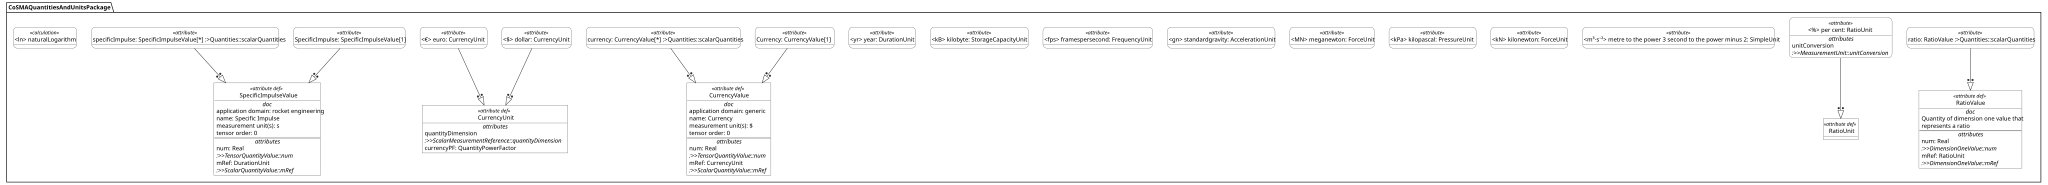

In [ ]:
%viz CoSMAQuantitiesAndUnitsPackage --view tree

### ✅ `TechnicalPortsPackage` — `Technical\TechnicalPortsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package TechnicalPortsPackage {
	
	private import SI::*;
	private import ISQ::*;

	item def StructuralLoad { doc /* Represents the transfer of physical forces (compression, tension, torsion). */ }
	item def CommandSignal { doc /* Represents a discrete command or electrical signal. */ }
	item def TelemetryData { doc /* Represents a flow of vehicle health and status data. */ }
	item def ElectricalPower { doc /* Represents a flow of electrical energy. */ }
	item def LifeSupportFlows { doc /* Represents a flow of oxygen, water, and thermal control fluids. */ }

	port def PayloadInterfacePort {
		doc /* Defines the connection point on the launch vehicle that structurally supports and electrically interfaces with the spacecraft payload before separation. */
		inout item loads : StructuralLoad;
		out item commands : CommandSignal;
		in item telemetry : TelemetryData;
		out item power : ElectricalPower;
	}

	port def StagingPort {
		doc /* A single definition for a staging interface port, viewed from the 'source' (lower) stage. */
		inout item loads : StructuralLoad;
		out item commands : CommandSignal;
	}
	
	port def ControlPort {
		doc /* A single definition for a guidance interface port, viewed from the 'controller' (e.g., Instrument Unit). */
		out item guidanceCmds : CommandSignal;
		out item thrustCmds : CommandSignal;
		in item telemetry : TelemetryData;
		out item power : ElectricalPower;
	}

	port def UmbilicalPort {
		doc /* A single definition for an umbilical port, viewed from the 'supplier' (e.g., Service Module). */
		out item power : ElectricalPower;
		out item lifeSupport : LifeSupportFlows;
		out item dataAndControl : CommandSignal;
	}
	
	port def DockingPort {
		doc /* A symmetric port for docking, where flows can be bidirectional. */
		inout item loads : StructuralLoad;
		inout item power : ElectricalPower;
		inout item data : TelemetryData;
	}

	port def LMStagingPort {
		doc /* A single definition for the Lunar Module staging port, viewed from the 'platform' (Descent Stage). */
		inout item loads : StructuralLoad;
		out item commands : CommandSignal;
		out item powerAndData : ElectricalPower;
	}
	
	port def EVAUmbilicalPort {
		doc /* A single definition for the spacesuit umbilical, viewed from the 'supplier' (the PLSS backpack). */
		out item lifeSupport : LifeSupportFlows;
		out item power : ElectricalPower;
		inout item commsAndData : TelemetryData;
	}
	
	port def LaunchEscapeSystemPort {
		doc /* Defines the connection point on the Command Module that supports and controls the LES. */
		inout item loads : StructuralLoad;
		out item abortSignal : CommandSignal;
		out item jettisonSignal : CommandSignal;
	}
	
	interface def StagingInterface {
		doc /* Defines the contract for a connection between two rocket stages. */
		end source : StagingPort;
		end target : ~StagingPort;
	}
	
	interface def GuidanceInterface {
		doc /* Defines the contract for a connection between a controller (IU) and a controlled component (S-IVB). */
		end controller : ControlPort;
		end controlled : ~ControlPort;
	}
	
	interface def CSMInterface {
		doc /* Defines the contract for the umbilical connection between the Command and Service Modules. */
		end supplier : UmbilicalPort;
		end consumer : ~UmbilicalPort;
	}
	
	interface def DockingInterface {
		doc /* Defines the contract for a symmetric docking connection between two vehicles. */
		end vehicle1 : DockingPort;
		end vehicle2 : DockingPort;
	}
	
	interface def LMStagingInterface {
		doc /* Defines the contract for the connection between the two stages of the Lunar Module. */
		end platform : LMStagingPort;
		end ascender : ~LMStagingPort;
	}
	
	interface def EVAInterface {
		doc /* Defines the contract for the connection between the spacesuit and its life support backpack. */
		end plss : EVAUmbilicalPort;
		end psa : ~EVAUmbilicalPort;
	}	
	
	interface def LVPayloadInterface {
		doc /* Defines the contract for the primary connection between the launch vehicle (Instrument Unit) and the spacecraft payload (SLA). */
		end launchVehicle : PayloadInterfacePort;
		end payload : ~PayloadInterfacePort;
	}	
	
	interface def LESInterface {
		doc /* Defines the contract for the connection between the Command Module and the Launch Escape System. */
		end commandModule : LaunchEscapeSystemPort;
		end launchEscapeSystem : ~LaunchEscapeSystemPort;
	}	

}

✅ TechnicalPortsPackage loaded successfully (0.322s)


#### ✅ Visualization: `%viz TechnicalPortsPackage --view tree`

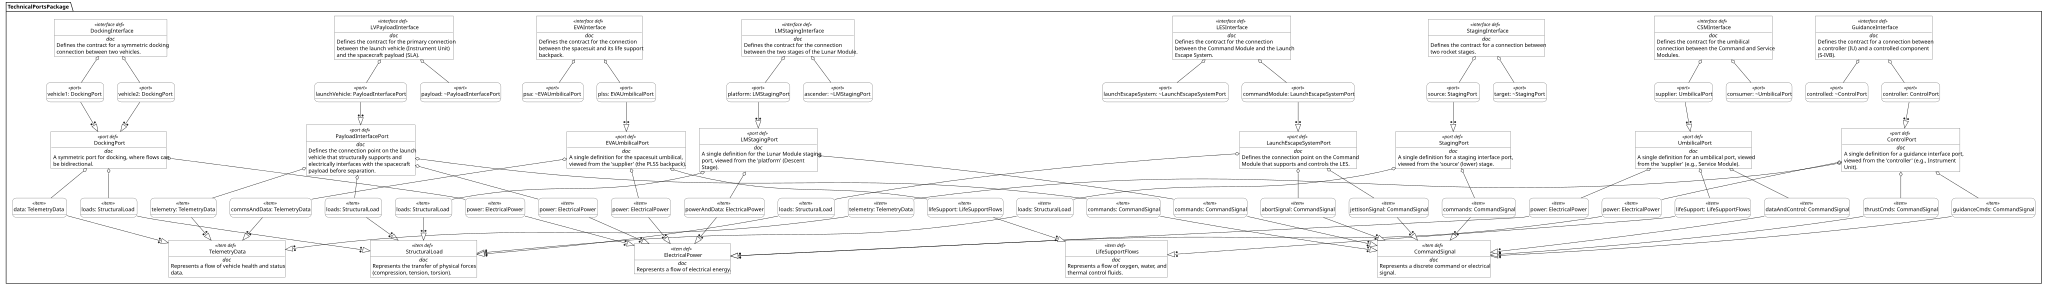

In [ ]:
%viz TechnicalPortsPackage --view tree

### ✅ `CoSMAPackage` — `CoSMA\CoSMAPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

library package CoSMAPackage {

	private import NumericalFunctions::*;
	private import States::*;
	private import ISQ::*;
	private import SI::*;
	private import MeasurementReferences::*;
	private import Quantities::*;
	private import Base::DataValue;
	private import Metaobjects::*;
	private import CoSMAQuantitiesAndUnitsPackage::*;
	
    part def MassedComponent {
        part subcomponents : MassedComponent [*] default null;
        attribute mass :> ISQ::mass;
        attribute totalMass :> ISQ::mass = mass + sum(subcomponents.totalMass);
    }

	abstract action def Operation;
	
	abstract action def Function {
		action subfunctions[*] : Function :>> subactions;
	}

	abstract part def SystemOfInterest;
	abstract part def LogicalComponent;

	abstract part def TechnicalComponent {
		attribute failureRate :> ISQ::frequency;
	}

	abstract part def SoftwareComponent :> TechnicalComponent;
	abstract part def HardwareComponent :> TechnicalComponent, MassedComponent;

	abstract part def PowerProvider :> HardwareComponent {
		attribute powerGenerated :> ISQ::power default 0 [W];	
	}

	abstract part def PowerConsumer :> HardwareComponent {
		attribute powerLoad :> ISQ::power;	
	}
	
	part def Program {
		part missions[1..*] : Mission;
	}

	state def Phase :> StateAction;

	part def Capability;

	part def Astronaut :> Person;

	abstract part def MannedSpaceMission :> Mission {
		part crew[1..*] : Astronaut;
	}

	abstract part def Mission {
		requirement goals[1..*] : Goal;
		part system : System;
		part context : Context;
		exhibit state phases : StateAction;
		part requiredCapabilites[0..*];
		abstract connection capabilityToGoals[*] : CapabilityToGoalDerivation;
		attribute plannedDuration :> ISQ::duration;

		attribute researchAndDevelopmentCost :> currency;
		attribute manufacturingCost :> currency;
		attribute operationsCost :> currency;
		attribute personnelCost :> currency;		
	}

	abstract connection def CapabilityToGoalDerivation {
		ref part capability[1] : Capability :> participant; 
		ref requirement goals[1..*] : Goal :> participant; 
	}

	requirement def Goal;

	item def Concern;

	enum def StakeholderInfluenceKind {
		enum direct;
		enum indirect;
	}

	enum def StakeholderInfluenceLevel {
		enum high;
		enum medium;
		enum low;
	}	

	part def Person;

	requirement def StakeholderNeed;

	part def Stakeholder {
		attribute influenceLevel: StakeholderInfluenceLevel;
		attribute influenceKind: StakeholderInfluenceKind;
		item concerns[*]: Concern;
		requirement needs[*]: StakeholderNeed;
	}
	
	part def Context :> System {
		part externalSystems[*] : System;
	}
	
	part def System :> MassedComponent {
		
	}
	
	part def SystemOfSystems :> System {
		part constituentSystems[*] : ConstituentSystem;
	}
	
	part def ConstituentSystem :> System {
		
	}

}

✅ CoSMAPackage loaded successfully (0.379s)


#### ✅ Visualization: `%viz CoSMAPackage --view tree`

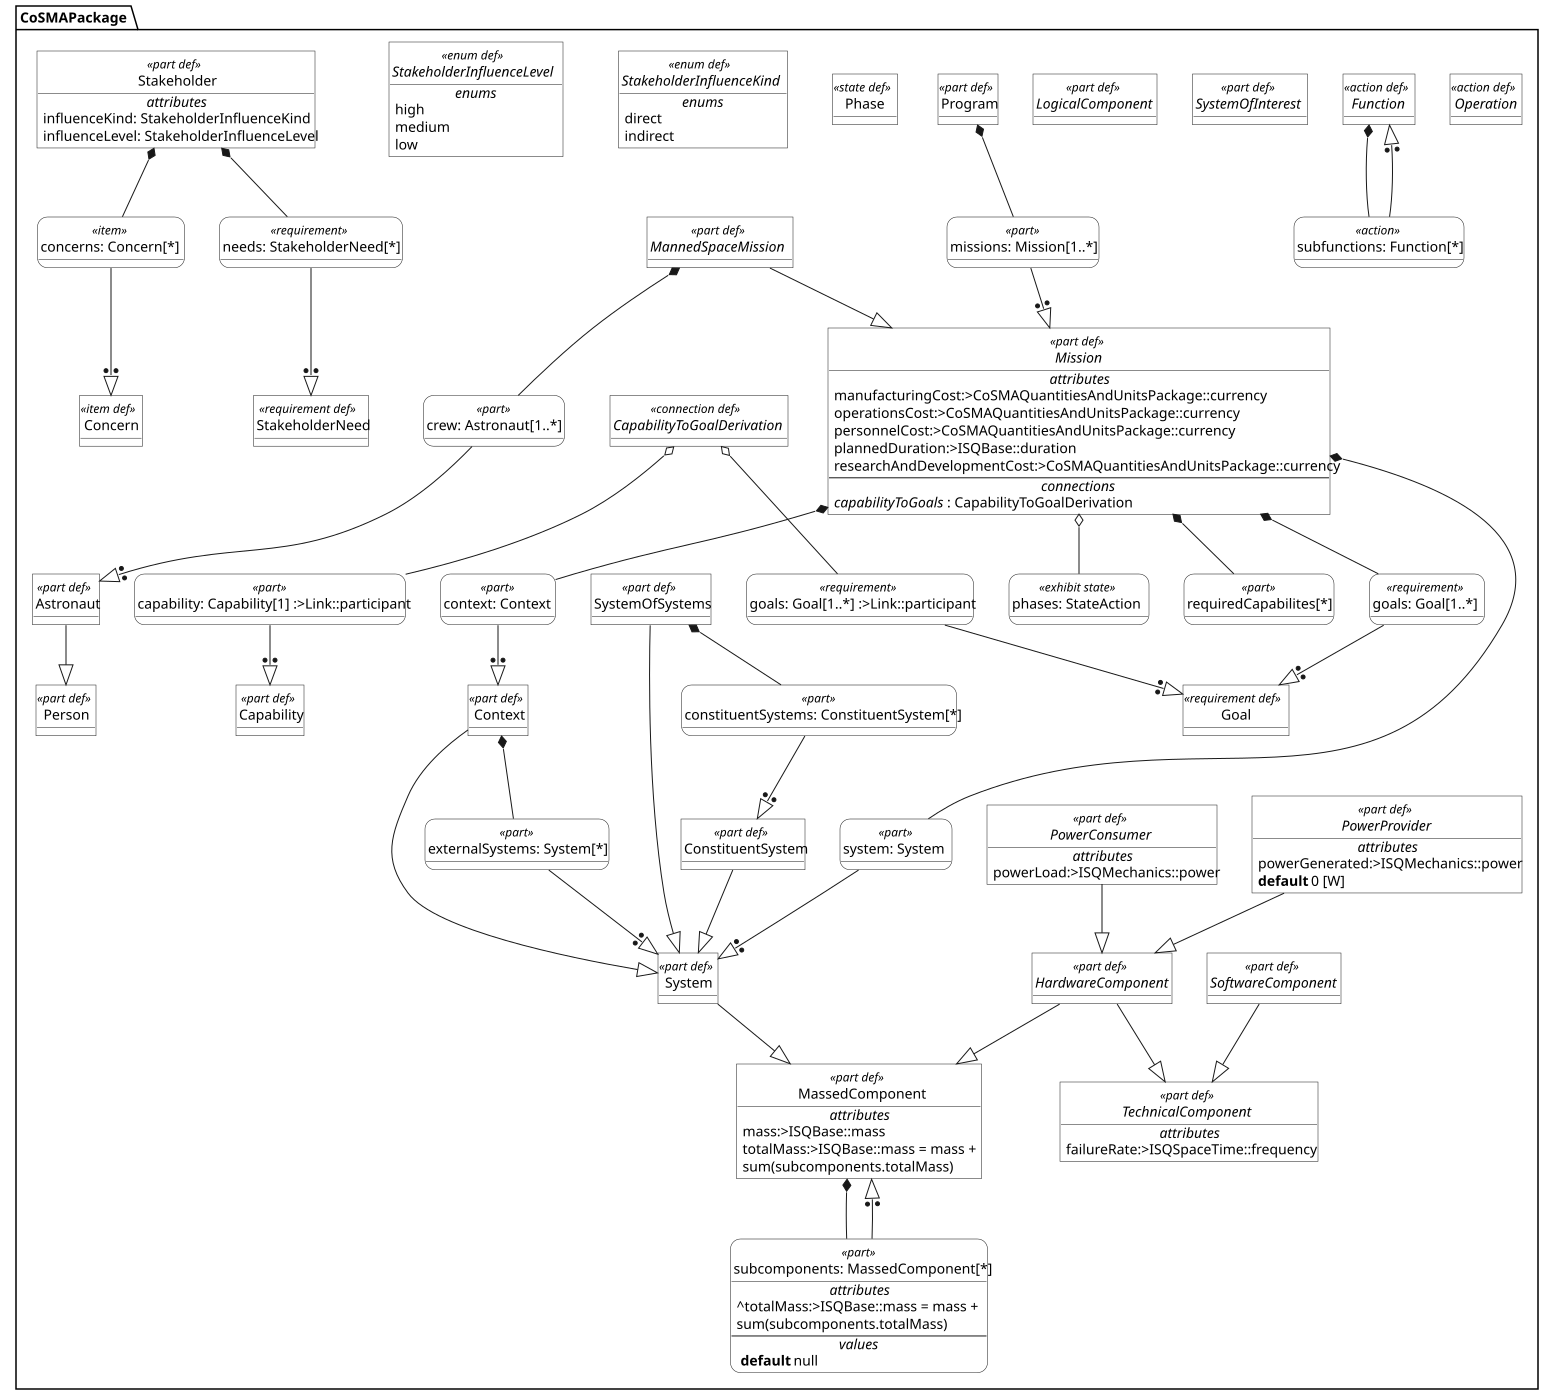

In [ ]:
%viz CoSMAPackage --view tree

### ✅ `AstronautsPackage` — `Technical\AstronautsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package AstronautsPackage {
	
	private import CoSMAPackage::*;
	private import ScalarValues::*;
	private import Time::*;
	
	individual part def 'Gus Grissom' :> Astronaut {
		doc /* Virgil "Gus" Grissom was one of the original Mercury Seven astronauts. He was the second American in space and the first person to fly in space twice. He was the commander of the ill-fated Apollo 1 mission and tragically died in the launch pad fire. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1926-04-03");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("1967-01-27");
	}
	individual part def 'Ed White' :> Astronaut {
		doc /* Edward H. White II was the first American to perform a spacewalk, during the Gemini 4 mission. As Senior Pilot for the Apollo 1 mission, he died in the launch pad fire alongside his crewmates. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1930-11-14");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("1967-01-27");
	}
	individual part def 'Roger B. Chaffee' :> Astronaut {
		doc /* A rookie astronaut selected for the first crewed low Earth orbital test of the Apollo spacecraft. He served as the Pilot for Apollo 1 and tragically died in the launch pad fire with his crew. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1935-02-15");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("1967-01-27");
	}
	individual part def 'Wally Schirra' :> Astronaut {
		doc /* Walter "Wally" Schirra was the only astronaut to fly in all three of America's first human spaceflight programs: Mercury, Gemini, and Apollo. He commanded Apollo 7, the first crewed flight of the Apollo program. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1923-03-12");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2007-05-03");
	}
	individual part def 'Walt Cunningham' :> Astronaut {
		doc /* Walter Cunningham was a physicist and the Lunar Module Pilot on Apollo 7. This mission was a critical 11-day Earth-orbital test of the Apollo Command/Service Module, proving its space-worthiness. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1932-03-16");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2023-01-03");
	}
	individual part def 'Donn Eisele' :> Astronaut {
		doc /* Donn F. Eisele was the Command Module Pilot on Apollo 7, the first crewed flight of the Apollo spacecraft, which successfully tested the vehicle in Earth orbit. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1930-06-23");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("1987-12-02");
	}
	individual part def 'Frank Borman' :> Astronaut {
		doc /* Frank Borman was the Commander of the Apollo 8 mission, the first crewed flight to orbit the Moon. This historic 1968 mission was a crucial step towards the lunar landing. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1928-03-14");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2023-11-07");
	}
	individual part def 'James Lovell' :> Astronaut {
		doc /* James "Jim" Lovell is one of only three men to have flown to the Moon twice. He flew on Apollo 8, the first mission to orbit the Moon, and was the Commander of the ill-fated Apollo 13 mission, which he and his crew safely returned to Earth after a major in-flight emergency. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1928-03-25");
	}
	individual part def 'William Anders' :> Astronaut {
		doc /* William "Bill" Anders was the Lunar Module Pilot on Apollo 8. He is famous for taking the iconic "Earthrise" photograph, showing the Earth rising above the lunar horizon. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1933-10-17");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2024-06-07");
	}
	individual part def 'James McDivitt' :> Astronaut {
		doc /* James McDivitt was the Commander of Gemini 4 and Apollo 9 (first flight of the Lunar Module). */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1929-06-10");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2022-10-13");
	}
	individual part def 'David Scott' :> Astronaut {
		doc /* David Scott flew on Gemini 8 and Apollo 9, and was the Commander of Apollo 15. As the seventh person to walk on the Moon, he was the first to drive the Lunar Roving Vehicle on the lunar surface. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1932-06-06");
	}
	individual part def 'Russell Schweickart' :> Astronaut {
		doc /* Russell "Rusty" Schweickart was the Lunar Module Pilot on Apollo 9. He performed the first extravehicular activity (EVA) of the Apollo program, testing the new spacesuit's life support system. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1935-10-25");
	}
	individual part def 'Thomas Stafford' :> Astronaut {
		doc /* Thomas Stafford was the Commander of Apollo 10, the final "dress rehearsal" mission that flew to the Moon and tested the Lunar Module in lunar orbit, descending to within 9 miles of the surface. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1930-09-17");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2024-03-18");
	}
	individual part def 'John Young' :> Astronaut {
		doc /* John Young had a long and distinguished career, flying in the Gemini, Apollo, and Space Shuttle programs. He was the Command Module Pilot on Apollo 10 and the Commander of Apollo 16, becoming the ninth person to walk on the Moon. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1930-09-24");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2018-01-05");
	}
	individual part def 'Eugene Cernan' :> Astronaut {
		doc /* Eugene "Gene" Cernan was one of three men to fly to the Moon twice, on Apollo 10 and Apollo 17. As Commander of Apollo 17, he was the last person to walk on the Moon. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1934-03-14");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2017-01-16");
	}
	individual part def 'Neil Armstrong' :> Astronaut {
		doc /* Neil Armstrong was the Commander of Apollo 11. A veteran of the Gemini program and a skilled test pilot, he became the first human to walk on the lunar surface on July 20, 1969. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1930-08-05");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2012-08-25");
	}
	individual part def 'Michael Collins' :> Astronaut {
		doc /* Michael Collins was the Command Module Pilot for Apollo 11. He remained in lunar orbit aboard the Command Module "Columbia" while his crewmates explored the surface, a critical role for their safe return. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1930-10-31");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2021-04-28");
	}
	individual part def 'Buzz Aldrin' :> Astronaut {
		doc /* Edwin "Buzz" Aldrin was the Lunar Module Pilot for Apollo 11. He joined Neil Armstrong on the lunar surface, becoming the second human to walk on the Moon. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1930-01-20");
	}
	individual part def 'Pete Conrad' :> Astronaut {
		doc /* Charles "Pete" Conrad Jr. was the Commander of Apollo 12, the second lunar landing mission. He was the third person to walk on the Moon. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1930-06-02");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("1999-07-08");
	}
	individual part def 'Richard Gordon' :> Astronaut {
		doc /* Richard "Dick" Gordon Jr. was the Command Module Pilot for Apollo 12, orbiting the Moon while his crewmates landed in the Ocean of Storms. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1929-10-05");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2017-11-06");
	}
	individual part def 'Alan Bean' :> Astronaut {
		doc /* Alan Bean was the Lunar Module Pilot for Apollo 12, becoming the fourth person to walk on the Moon. After retiring from NASA, he became a renowned artist, painting scenes from the Apollo missions. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1932-03-15");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2018-05-26");
	}
	individual part def 'Jack Swigert' :> Astronaut {
		doc /* John "Jack" Swigert Jr. was the Command Module Pilot for the dramatic Apollo 13 mission. He was a late replacement for Ken Mattingly and played a key role in the crew's safe return. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1931-08-30");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("1982-12-27");
	}
	individual part def 'Fred Haise' :> Astronaut {
		doc /* Fred Haise was the Lunar Module Pilot for Apollo 13. He was scheduled to be the sixth person to walk on the Moon before an in-flight emergency forced the mission to abort its landing. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1933-11-14");
	}
	individual part def 'Alan Shepard' :> Astronaut {
		doc /* Alan Shepard was one of the original Mercury Seven and the first American in space. After overcoming an inner-ear disorder, he commanded Apollo 14, becoming the fifth person to walk on the Moon, where he famously hit two golf balls. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1923-11-18");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("1998-07-21");
	}
	individual part def 'Stuart Roosa' :> Astronaut {
		doc /* Stuart Roosa was the Command Module Pilot for Apollo 14. He carried hundreds of tree seeds into lunar orbit as part of a joint project with the U.S. Forest Service. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1933-08-16");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("1994-12-12");
	}
	individual part def 'Edgar Mitchell' :> Astronaut {
		doc /* Edgar Mitchell was the Lunar Module Pilot for Apollo 14 and the sixth person to walk on the Moon, exploring the Fra Mauro formation. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1930-09-17");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2016-02-04");
	}
	individual part def 'Alfred Worden' :> Astronaut {
		doc /* Alfred Worden was the Command Module Pilot for Apollo 15. During the return journey from the Moon, he performed the first-ever deep-space extravehicular activity (EVA). */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1932-02-07");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2020-03-18");
	}
	individual part def 'James Irwin' :> Astronaut {
		doc /* James Irwin was the Lunar Module Pilot for Apollo 15 and the eighth person to walk on the Moon. He was one of the first to explore the lunar mountains and drive the Lunar Roving Vehicle. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1930-03-17");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("1991-08-08");
	}
	individual part def 'Ken Mattingly' :> Astronaut {
		doc /* Thomas Kenneth "Ken" Mattingly II was famously removed from the Apollo 13 crew due to exposure to measles but later served as the Command Module Pilot for Apollo 16, orbiting the Moon during the mission. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1936-03-17");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("2023-10-31");
	}
	individual part def 'Charles Duke' :> Astronaut {
		doc /* Charles Duke served as the CAPCOM for Apollo 11, and his voice was heard by millions during the landing. He later flew as the Lunar Module Pilot for Apollo 16, becoming the tenth person to walk on the Moon. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1935-10-03");
	}
	individual part def 'Ronald Evans' :> Astronaut {
		doc /* Ronald Evans was the Command Module Pilot for Apollo 17. During the return flight from the Moon, he performed an EVA to retrieve film cassettes from the Service Module, which was the last deep-space EVA of the Apollo program. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1933-11-10");
		attribute dateOfDeath: Iso8601DateTime = new Iso8601DateTime("1990-04-07");
	}
	individual part def 'Harrison Schmitt' :> Astronaut {
		doc /* Harrison "Jack" Schmitt was the Lunar Module Pilot for Apollo 17. As a professional geologist, he was the only scientist to walk on the Moon and the twelfth person to do so. */
		attribute dateOfBirth: Iso8601DateTime = new Iso8601DateTime("1935-07-03");
	}
}

✅ AstronautsPackage loaded successfully (0.442s)


#### ✅ Visualization: `%viz AstronautsPackage --view tree`

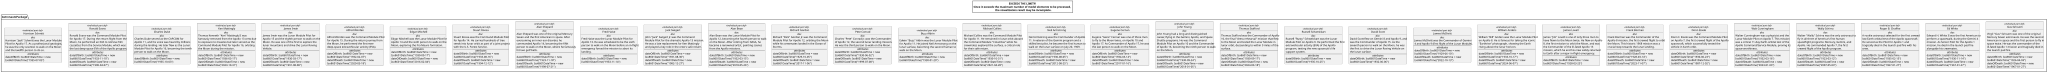

In [ ]:
%viz AstronautsPackage --view tree

### ✅ `OperationsPackage` — `Operation\OperationsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package OperationsPackage {
	
	private import CoSMAPackage::*;

	action def LoadConsumablesAndPropellants :> Operation {
		doc /* The process of fueling the Saturn V rocket and loading all necessary consumables like oxygen and water into the spacecraft. */
	}
	action def TransferCrewToVehicle :> Operation {
		doc /* The operation where the flight crew moves from the crew quarters to the launch pad and ingresses the Command Module. */
	}

	action def PerformPreLaunchCountdown :> Operation {
		doc /* The synchronized sequence of checks and configurations performed in the final hours and minutes leading up to liftoff. */
	}
	action def ExecuteLaunchSequence :> Operation {
		doc /* The automated and monitored sequence of engine ignitions, vehicle ascent, and staging events that propel the vehicle into orbit. */
	}
	action def MonitorAscentTrajectory :> Operation {
		doc /* The continuous tracking of the vehicle's speed, altitude, and flight path during ascent to ensure it is following the correct trajectory. */
	}

	action def ExecuteTLIBurn :> Operation {
		doc /* The critical engine burn of the S-IVB third stage to propel the spacecraft out of Earth orbit and onto a trajectory to the Moon. */
	}
	action def PerformTranspositionDockingExtraction :> Operation {
		doc /* The complex maneuver where the CSM separates, turns around, docks with the LM, and extracts it from the S-IVB stage. */
	}
	action def ConductMidCourseCorrections :> Operation {
		doc /* Small propulsive burns performed during the coast phases to refine the spacecraft's trajectory. */
	}
	action def MonitorSpacecraftSystems :> Operation {
		doc /* The continuous monitoring of all onboard systems by the crew and Mission Control to ensure vehicle health. */
	}
	action def CommunicateWithMissionControl :> Operation {
		doc /* The two-way exchange of voice, telemetry, and command data between the spacecraft and ground stations. */
	}
	action def ManageCrewRestPeriods :> Operation {
		doc /* The scheduling and management of sleep, meals, and downtime for the crew to ensure their health and performance. */
	}

	action def ExecuteLOIBurn :> Operation {
		doc /* The engine burn of the Service Module to slow the spacecraft, allowing it to be captured into a stable lunar orbit. */
	}
	action def ConductLunarOrbitCheckouts :> Operation {
		doc /* A series of system health checks performed on the CSM and LM while in lunar orbit. */
	}
	action def PrepareLMforUndocking :> Operation {
		doc /* The process of activating the Lunar Module's systems and configuring it for independent flight. */
	}
	action def PerformLMUndocking :> Operation {
		doc /* The physical separation of the Lunar Module from the Command Module in lunar orbit. */
	}

	action def ExecutePoweredDescentBurn :> Operation {
		doc /* The continuous, throttleable engine burn of the LM Descent Stage to control the descent from orbit to the lunar surface. */
	}
	action def MonitorDescentTelemetry :> Operation {
		doc /* The real-time tracking of the LM's altitude and velocity during the landing phase. */
	}
	action def PerformManualPiloting :> Operation {
		doc /* The manual control of the LM by the Commander during the final phase of landing to avoid hazards. */
	}
	action def ConductLMPostLandingChecks :> Operation {
		doc /* A series of procedures performed after landing to safe the LM's systems and verify its integrity. */
	}
	action def PrepareForEVA :> Operation {
		doc /* The process of the crew donning their spacesuits and depressurizing the LM cabin for surface exploration. */
	}
	action def PerformLunarEVA :> Operation {
		doc /* The extravehicular activity where the crew operates on the lunar surface to explore and conduct experiments. */
	}
	action def CollectLunarSamples :> Operation {
		doc /* The task of gathering and storing rock and soil samples from the lunar surface. */
	}
	action def DeployScientificInstruments :> Operation {
		doc /* The setup of the Early Apollo Scientific Experiments Package (EASEP) on the lunar surface. */
	}
	action def ConcludeEVA :> Operation {
		doc /* The process of the crew re-entering the LM, stowing equipment, and closing the hatch. */
	}
	action def ManageLunarSurfaceRestPeriod :> Operation {
		doc /* The scheduled rest and sleep period for the crew while on the Moon. */
	}

	action def ExecuteLunarAscentBurn :> Operation {
		doc /* The firing of the LM Ascent Stage engine to lift off from the lunar surface and return to orbit. */
	}
	action def PerformRendezvousManeuvers :> Operation {
		doc /* A series of precise orbital maneuvers performed by the LM to match the orbit of and approach the CSM. */
	}
	action def ConductLMCSMDocking :> Operation {
		doc /* The physical connection of the LM Ascent Stage with the orbiting CSM. */
	}
	action def TransferCrewAndSamples :> Operation {
		doc /* The movement of the crew and collected lunar samples from the LM back into the Command Module. */
	}
	action def JettisonLM :> Operation {
		doc /* The final separation from the LM Ascent Stage, leaving it in lunar orbit. */
	}

	action def ExecuteTEIBurn :> Operation {
		doc /* The engine burn of the Service Module to propel the CSM out of lunar orbit and onto a trajectory back to Earth. */
	}
	action def PrepareCMforReentry :> Operation {
		doc /* Final checks and configurations of the Command Module in preparation for atmospheric entry. */
	}

	action def SeparateModules :> Operation {
		doc /* The pyrotechnic separation of the Command Module from the Service Module just before reentry. */
	}
	action def GuideReentryTrajectory :> Operation {
		doc /* The controlled, lifting flight of the Command Module through the atmosphere to manage heating and target the landing zone. */
	}
	action def DeployParachutes :> Operation {
		doc /* The sequential deployment of drogue and main parachutes to slow the Command Module for a safe splashdown. */
	}
	action def ConductSplashdownOperations :> Operation {
		doc /* The final water landing of the Command Module and the activation of its recovery systems. */
	}

	action def RetrieveCrewAndCM :> Operation {
		doc /* The location and recovery of the crew and capsule from the ocean by naval forces. */
	}
	action def InitiateQuarantineProcedures :> Operation {
		doc /* The implementation of biological isolation protocols for the crew, capsule, and samples upon their return. */
	}
	action def SecureLunarSamples :> Operation {
		doc /* The process of packaging and transporting the returned lunar samples to the Lunar Receiving Laboratory. */
	}
}

✅ OperationsPackage loaded successfully (0.128s)


#### ✅ Visualization: `%viz OperationsPackage --view tree`

In [ ]:
%viz OperationsPackage --view tree

### ✅ `StakeholderNeedsPackage` — `Requirements\StakeholderNeedsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package StakeholderNeedsPackage {

	private import ModelingMetadata::*;
    private import CoSMAPackage::*;

	requirement def <'SHN-N001'> MissionSuccess :> StakeholderNeed {
		doc /* The mission shall succeed in all its technical and operational objectives. */
		@Rationale {
			text = "The primary responsibility of the agency is to successfully execute the missions it is tasked with, thereby fulfilling its national mandate.";
		}
	}

	requirement def <'SHN-N002'> AstronautSafety :> StakeholderNeed {
		doc /* The mission shall ensure the safety and survival of the astronauts throughout all phases. */
		@Rationale {
			text = "The agency has a fundamental duty of care for its personnel, and the success of the human spaceflight program depends on ensuring crew safety.";
		}
	}

	requirement def <'SHN-N003'> ProgrammaticFunding :> StakeholderNeed {
		doc /* The mission's execution and public profile shall be managed to maintain continued public and political support and funding. */
		@Rationale {
			text = "The Apollo program's existence is contingent on a massive financial commitment, which requires sustained political and public approval.";
		}
	}

	requirement def <'SHN-N004'> InternationalPrestige :> StakeholderNeed {
		doc /* The mission shall demonstrate technological superiority and achieve its primary objectives before any competing nation. */
		@Rationale {
			text = "A core driver of the Apollo program was to win the Space Race, a key element of the Cold War geopolitical landscape.";
		}
	}

	requirement def <'SHN-N005'> ScientificReturn :> StakeholderNeed {
		doc /* The mission shall yield significant scientific data, primarily through the return of lunar samples. */
		@Rationale {
			text = "Beyond the political goals, a key justification for the mission is the unique opportunity for scientific discovery.";
		}
	}

	requirement def <'SHN-N006'> PlanetaryProtection :> StakeholderNeed {
		doc /* The mission shall prevent the contamination of Earth's biosphere by potential extraterrestrial life forms. */
		@Rationale {
			text = "As a matter of public safety and scientific integrity, the agency must ensure that no harm comes from introducing unsterilized materials to Earth.";
		}
	}

	requirement def <'SHN-N007'> CrewSurvival :> StakeholderNeed {
		doc /* The mission systems and procedures shall ensure the crew can survive all mission phases. */
		@Rationale {
			text = "The most fundamental need of any human participant in a high-risk endeavor is to survive the experience.";
		}
	}

	requirement def <'SHN-N008'> ProceduralSuccess :> StakeholderNeed {
		doc /* The mission shall provide the tools, training, and systems necessary for the successful execution of all assigned procedures. */
		@Rationale {
			text = "The crew's professional responsibility and the mission's success depend on their ability to perform their tasks correctly.";
		}
	}

	requirement def <'SHN-N009'> PerformanceUnderPressure :> StakeholderNeed {
		doc /* The mission environment and crew selection shall enable the management of extreme stress and pressure to ensure peak performance. */
		@Rationale {
			text = "The psychological demands of a lunar mission are extreme; the crew's ability to cope is critical to success and safety.";
		}
	}

	requirement def <'SHN-N010'> TrainingFidelity :> StakeholderNeed {
		doc /* The mission training program shall adequately prepare the crew for all nominal and contingency scenarios. */
		@Rationale {
			text = "High-fidelity training is the primary tool for mitigating risks and ensuring the crew can respond correctly to any situation.";
		}
	}

	requirement def <'SHN-N011'> EnvironmentalHazardProtection :> StakeholderNeed {
		doc /* The mission systems shall protect the crew from the known and unknown hazards of the lunar environment. */
		@Rationale {
			text = "Hazards such as abrasive dust and unstable ground pose a direct threat to the crew and equipment on the lunar surface.";
		}
	}

	requirement def <'SHN-N012'> RealtimeProblemSolving :> StakeholderNeed {
		doc /* The mission systems shall provide the necessary data and communication links to enable real-time problem solving from the ground. */
		@Rationale {
			text = "Unforeseen anomalies are expected, and Mission Control's ability to analyze and solve them in real-time is a critical safety function.";
		}
	}

	requirement def <'SHN-N013'> DataAccuracy :> StakeholderNeed {
		doc /* The mission shall provide accurate and reliable telemetry to support critical ground-based decision making. */
		@Rationale {
			text = "The safety of the crew and success of the mission depend on ground controllers making decisions based on correct data.";
		}
	}

	requirement def <'SHN-N014'> ContinuousSupport :> StakeholderNeed {
		doc /* The mission shall enable continuous communication to provide uninterrupted support to the flight crew. */
		@Rationale {
			text = "The crew in space relies on the ground team for information, calculations, and support that they cannot manage alone.";
		}
	}

	requirement def <'SHN-N015'> OperationalCoordination :> StakeholderNeed {
		doc /* The mission shall be executed with a high degree of coordination between all flight and ground control teams. */
		@Rationale {
			text = "A complex mission requires flawless teamwork and communication across multiple specialized teams to function correctly.";
		}
	}
	
	requirement def <'SHN-N016'> LunarModulePerformance :> StakeholderNeed {
		doc /* The Lunar Module vehicle shall perform all its functions successfully, including landing, life support, and ascent. */
		@Rationale {
			text = "As the manufacturer, the company's primary interest is the successful and reliable performance of its product.";
		}
	}

	requirement def <'SHN-N017'> ProgrammaticAdherence :> StakeholderNeed {
		doc /* The development and delivery of the Lunar Module shall adhere to the programmatic schedule and budget. */
		@Rationale {
			text = "Meeting contractual obligations regarding schedule and budget is a primary business need for any contractor.";
		}
	}

	requirement def <'SHN-N018'> ReputationalSuccess :> StakeholderNeed {
		doc /* The success of the Lunar Module shall enhance the company's reputation as a leading aerospace contractor. */
		@Rationale {
			text = "A successful high-profile mission provides immense reputational value and secures opportunities for future contracts.";
		}
	}

	requirement def <'SHN-N019'> NationalPrestige :> StakeholderNeed {
		doc /* The mission shall achieve its goal of a crewed lunar landing to demonstrate national technological supremacy. */
		@Rationale {
			text = "The mission was a central element of the Cold War Space Race, and achieving the landing was a primary geopolitical objective.";
		}
	}

	requirement def <'SHN-N020'> PublicConfidence :> StakeholderNeed {
		doc /* The mission shall be conducted successfully and safely to bolster public confidence and morale. */
		@Rationale {
			text = "A successful mission serves as a unifying national event and a demonstration of the government's capabilities.";
		}
	}

	requirement def <'SHN-N021'> InvestmentJustification :> StakeholderNeed {
		doc /* The mission shall produce sufficient scientific and symbolic returns to justify the significant national financial investment. */
		@Rationale {
			text = "The high cost of the program necessitates tangible results, such as scientific knowledge and national prestige, to be considered a worthwhile expenditure.";
		}
	}

	requirement def <'SHN-N022'> NationalSecurityDemonstration :> StakeholderNeed {
		doc /* The mission shall demonstrate advanced technological capabilities relevant to national security. */
		@Rationale {
			text = "The capabilities required for a lunar mission (e.g., large rockets, global tracking, precision guidance) are inherently linked to national security interests.";
		}
	}
}

✅ StakeholderNeedsPackage loaded successfully (0.44s)


#### ✅ Visualization: `%viz StakeholderNeedsPackage --view tree`

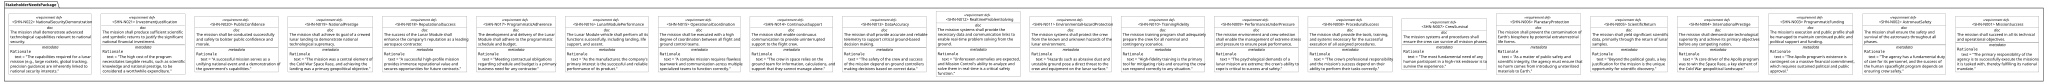

In [ ]:
%viz StakeholderNeedsPackage --view tree

### ✅ `MissionPhasesPackage` — `Purpose\MissionPhasesPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package MissionPhasesPackage {

	private import CoSMAPackage::*;
	private import OperationsPackage::*;

	// --- Item Definitions (Representing Completion Notifications/Triggers) ---
	item def PreparationPhaseCompletedNotification;
	item def LaunchPhaseCompletedNotification;
	item def TransLunarInjectionPhaseCompletedNotification;
	item def TransLunarCoastPhaseCompletedNotification;
	item def LunarOrbitInsertionPhaseCompletedNotification;
	item def LunarOrbitOperationsDescentPreparationPhaseCompletedNotification;
	item def PoweredDescentPhaseCompletedNotification;
	item def LunarSurfaceOperationsPhaseCompletedNotification;
	item def LunarAscentRendezvousPhaseCompletedNotification;
	item def TransEarthInjectionPhaseCompletedNotification;
	item def TransEarthCoastPhaseCompletedNotification;
	item def ReentryLandingPhaseCompletedNotification;
	item def RecoveryQuarantinePhaseCompletedNotification;

	// States
	state def PrepareForMissionPhase :> Phase {
		do action prepareForMissionPhaseOperations {
			first start;
			then action loadConsumablesAndPropellants : LoadConsumablesAndPropellants;
			then action transferCrewToVehicle : TransferCrewToVehicle;	
			then done;
		}
	}

	state def LaunchPhase :> Phase {
		do action launchPhaseOperations {
			first start;
			then action performPreLaunchCountdown : PerformPreLaunchCountdown;
			then action executeLaunchSequence : ExecuteLaunchSequence;
			then action monitorAscentTrajectory : MonitorAscentTrajectory;
			then done;
		}
	}
	state def TransLunarInjectionPhase :> Phase {
		do action tliPhaseOperations {
			first start;
			then action executeTLIBurn : ExecuteTLIBurn;
			then action performTranspositionDockingExtraction : PerformTranspositionDockingExtraction;
			then done;
		}
	}
	state def TransLunarCoastPhase :> Phase {
		do action tlcPhaseOperations {
			first start;
			then action conductMidCourseCorrections : ConductMidCourseCorrections;
			then action monitorSpacecraftSystems : MonitorSpacecraftSystems;
			then action communicateWithMissionControl : CommunicateWithMissionControl;
			then action manageCrewRestPeriods : ManageCrewRestPeriods;
			then done;
		}
	}
	state def LunarOrbitInsertionPhase :> Phase {
		do action loiPhaseOperations {
			first start;
			then action executeLOIBurn : ExecuteLOIBurn;
			then done;
		}
	}
	state def LunarOrbitOperationsDescentPreparationPhase :> Phase {
		do action lunarOpsDescentPrepOperations {
			first start;
			then action conductLunarOrbitCheckouts : ConductLunarOrbitCheckouts;
			then action prepareLMforUndocking : PrepareLMforUndocking;
			then action performLMUndocking : PerformLMUndocking;
			then done;
		}
	}
	state def PoweredDescentPhase :> Phase {
		do action poweredDescentOperations {
			first start;
			then action executePoweredDescentBurn : ExecutePoweredDescentBurn;
			then action monitorDescentTelemetry : MonitorDescentTelemetry;
			then action performManualPiloting : PerformManualPiloting;
			then done;
		}
	}
	state def LunarSurfaceOperationsPhase :> Phase {
		do action lunarSurfaceOpsOperations {
			first start;
			then action conductLMPostLandingChecks : ConductLMPostLandingChecks;
			then action prepareForEVA : PrepareForEVA;
			then action performLunarEVA : PerformLunarEVA;
			then action collectLunarSamples : CollectLunarSamples;
			then action deployScientificInstruments : DeployScientificInstruments;
			then action concludeEVA : ConcludeEVA;
			then action manageLunarSurfaceRestPeriod : ManageLunarSurfaceRestPeriod;
			then done;
		}
	}
	state def LunarAscentRendezvousPhase :> Phase {
		do action lunarAscentRendezvousOperations {
			first start;
			then action executeLunarAscentBurn : ExecuteLunarAscentBurn;
			then action performRendezvousManeuvers : PerformRendezvousManeuvers;
			then action conductLMCSMDocking : ConductLMCSMDocking;
			then action transferCrewAndSamples : TransferCrewAndSamples;
			then action jettisonLM : JettisonLM;
			then done;
		}
	}
	state def TransEarthInjectionPhase :> Phase {
		do action teiPhaseOperations {
			first start;
			then action executeTEIBurn : ExecuteTEIBurn;
			then done;
		}
	}
	state def TransEarthCoastPhase :> Phase {
		do action tecPhaseOperations {
			first start;
			then action monitorSpacecraftSystems : MonitorSpacecraftSystems;
			then action communicateWithMissionControl : CommunicateWithMissionControl;
			then action prepareCMforReentry : PrepareCMforReentry;
			then done;
		}
	}
	state def ReentryLandingPhase :> Phase {
		do action reentryLandingOperations {
			first start;
			then action separateModules : SeparateModules;
			then action guideReentryTrajectory : GuideReentryTrajectory;
			then action deployParachutes : DeployParachutes;
			then action conductSplashdownOperations : ConductSplashdownOperations;
			then done;
		}
	}
	state def RecoveryQuarantinePhase :> Phase {
		do action recoveryQuarantineOperations {
			first start;
			then action retrieveCrewAndCM : RetrieveCrewAndCM;
			then action initiateQuarantineProcedures : InitiateQuarantineProcedures;
			then action secureLunarSamples : SecureLunarSamples;
			then done;
		}
	}

	// Special states
	state def Initial;
	state def MissionComplete;

}

✅ MissionPhasesPackage loaded successfully (0.541s)


#### ✅ Visualization: `%viz MissionPhasesPackage --view tree`

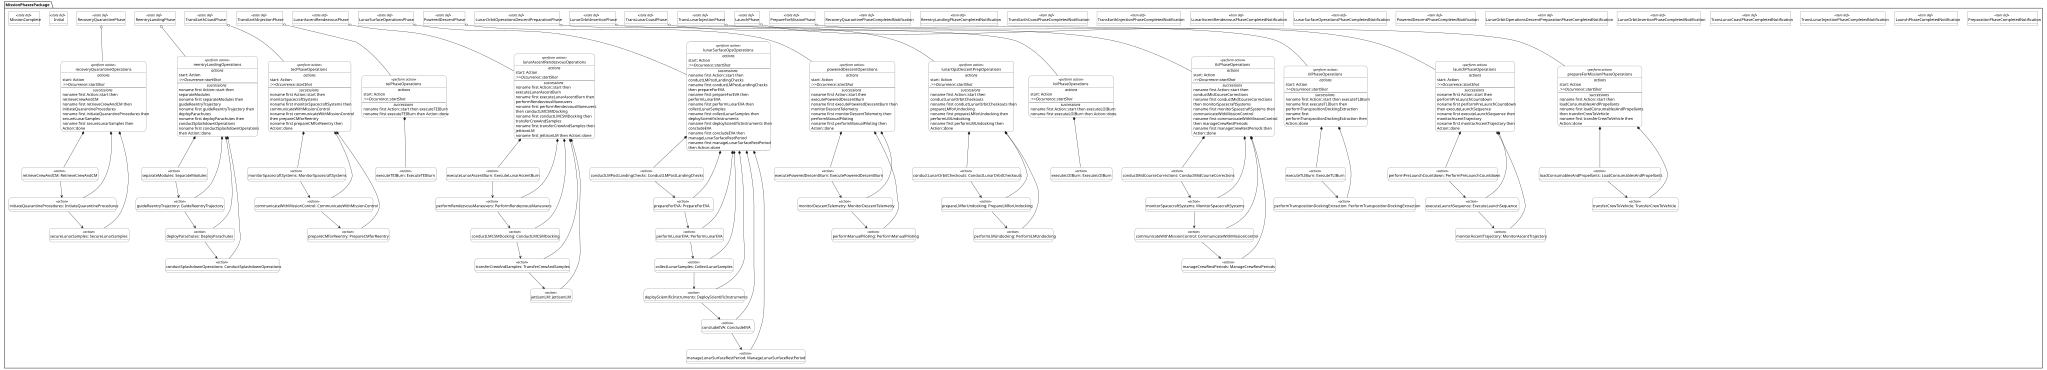

In [ ]:
%viz MissionPhasesPackage --view tree

### ✅ `CapabilitiesPackage` — `Purpose\CapabilitiesPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package CapabilitiesPackage {
	
	private import CoSMAPackage::*;
	private import StakeholderNeedsPackage::*;
	private import ModelingMetadata::*;
	
	part def ProgrammaticAndPublicAffairsManagement :> Capability {
		doc /* The ability to manage budgets, schedules, stakeholder communications, and public relations to maintain political and public support for a large-scale, high-cost program. */
		#refinement dependency ProgrammaticAndPublicAffairsManagement to 'SHN-N003';
		#refinement dependency ProgrammaticAndPublicAffairsManagement to 'SHN-N017';
		#refinement dependency ProgrammaticAndPublicAffairsManagement to 'SHN-N018';
		#refinement dependency ProgrammaticAndPublicAffairsManagement to 'SHN-N020';	
	}
	
	part def HeavyLiftLaunch :> Capability {
		doc /* The capability to propel extremely heavy payloads from Earth's surface into various orbital and interplanetary trajectories. */
		#refinement dependency HeavyLiftLaunch to 'SHN-N001';
		#refinement dependency HeavyLiftLaunch to 'SHN-N019';
		#refinement dependency HeavyLiftLaunch to 'SHN-N022';
	} 

	part def MultiStagePropulsion :> Capability {
		doc /* The ability to efficiently shed mass during ascent through the sequential operation of multiple rocket stages, optimizing for different phases of flight. */
		#refinement dependency MultiStagePropulsion to 'SHN-N001';
	}
	
	part def PrecisionOrbitalMechanics :> Capability {
		doc /* The capability to accurately calculate, execute, and refine trajectories and orbital maneuvers in complex gravitational fields (Earth-Moon system). This includes achieving and maintaining stable orbits, as well as performing precise rendezvous and docking operations in space. */
		#refinement dependency PrecisionOrbitalMechanics to 'SHN-N001';
		#refinement dependency PrecisionOrbitalMechanics to 'SHN-N022';		
	}
	
	part def AtmosphericReentryAndLanding :> Capability {
		doc /* The ability to guide a spacecraft safely through Earth's atmosphere, dissipate extreme heat, control descent, and achieve a soft water landing. */
		#refinement dependency AtmosphericReentryAndLanding to 'SHN-N002';
		#refinement dependency AtmosphericReentryAndLanding to 'SHN-N007';		
	}
	
	part def DeepSpaceHabitationAndLifeSupport :> Capability {
		doc /* Providing sustained environments for humans in the vacuum of space, managing air quality, temperature, humidity, water, and waste for extended durations. */
		#refinement dependency DeepSpaceHabitationAndLifeSupport to 'SHN-N002';
		#refinement dependency DeepSpaceHabitationAndLifeSupport to 'SHN-N007';
		#refinement dependency DeepSpaceHabitationAndLifeSupport to 'SHN-N011';	
	}
	
	part def AutonomousAndAssistedNavigationGuidanceAndControl :> Capability {
		doc /* Systems capable of determining position and velocity, calculating optimal paths, and executing maneuvers, both independently and with ground assistance. */
		#refinement dependency AutonomousAndAssistedNavigationGuidanceAndControl to 'SHN-N022';
	}
	
	part def InSpacePropulsion :> Capability {
		doc /* The ability to provide thrust for major orbital changes and trans-planetary injections using highly reliable and powerful engines. */
		#refinement dependency InSpacePropulsion to 'SHN-N001';
	}
	
	part def PowerGenerationAndDistribution :> Capability {
		doc /* Reliable systems to generate and distribute electrical power to all spacecraft systems throughout the mission. */
		#refinement dependency PowerGenerationAndDistribution to 'SHN-N001';
	}
	
	part def LunarSurfaceLandingAndAscent :> Capability {
		doc /* The specialized capability to de-orbit, perform a powered descent to a planetary surface, and then launch from that surface back into orbit. */
		#refinement dependency LunarSurfaceLandingAndAscent to 'SHN-N004';
		#refinement dependency LunarSurfaceLandingAndAscent to 'SHN-N016';
		#refinement dependency LunarSurfaceLandingAndAscent to 'SHN-N019';
	}
	
	part def GlobalTrackingAndCommunication :> Capability {
		doc /* Maintaining continuous contact and data exchange with spacecraft across vast distances using a worldwide network of ground stations. */
		#refinement dependency GlobalTrackingAndCommunication to 'SHN-N014';
	}
	
	part def RealtimeMissionControl :> Capability {
		doc /* The ability to monitor thousands of operational parameters, analyze data, and make critical, time-sensitive decisions to guide and support the mission. */
		#refinement dependency RealtimeMissionControl to 'SHN-N012';
		#refinement dependency RealtimeMissionControl to 'SHN-N014';
		#refinement dependency RealtimeMissionControl to 'SHN-N015';	
	}
	
	part def ContingencyPlanningAndRapidResponse :> Capability {
		doc /* Developing and implementing procedures to address unforeseen anomalies or failures swiftly and effectively. */
		#refinement dependency ContingencyPlanningAndRapidResponse to 'SHN-N002';
		#refinement dependency ContingencyPlanningAndRapidResponse to 'SHN-N007';	
	}
	
	part def CrewTrainingAndSimulation :> Capability {
		doc /* Rigorous programs to prepare astronauts for all mission aspects, including emergency procedures, through realistic simulations and drills. */
		#refinement dependency CrewTrainingAndSimulation to 'SHN-N008';
		#refinement dependency CrewTrainingAndSimulation to 'SHN-N010';
		#refinement dependency CrewTrainingAndSimulation to 'SHN-N015';	
	}
	
	part def HumanPerformanceUnderExtremeStress :> Capability {
		doc /* The ability of individuals and teams to maintain focus, make sound judgments, and execute complex tasks during high-stakes situations with immense pressure. */
		#refinement dependency HumanPerformanceUnderExtremeStress to 'SHN-N009';
	}

	part def ComplexSoftwareDevelopment :> Capability { 
		doc /* Creating and verifying intricate software for real-time control, navigation, and system management in highly constrained environments. */
		#refinement dependency ComplexSoftwareDevelopment to 'SHN-N001';
	}

	part def ComplexLogisticsAndIntegration :> Capability {
		doc /* The capacity to manage the design, manufacturing, assembly, and testing of highly complex, interdependent systems on an unprecedented scale. */
		#refinement dependency ComplexLogisticsAndIntegration to 'SHN-N001';
	}
	
	part def LaunchOperationsManagement :> Capability {
		doc /* The specialized ability to meticulously prepare, fuel, and execute the launch of large-scale rockets with precision and safety. */
		#refinement dependency LaunchOperationsManagement to 'SHN-N001';
	}
	
	part def AdaptabilityAndProblemSolving :> Capability {
		doc /* The inherent human capacity to adjust to unexpected challenges and devise creative solutions in real-time. */
		#refinement dependency AdaptabilityAndProblemSolving to 'SHN-N012';
	}

	part def ExtravehicularActivitySupport :> Capability {
		doc /* Providing specialized protective suits and equipment that allow humans to operate and perform tasks safely and effectively in the vacuum and harsh environments of space and planetary surfaces. */
		#refinement dependency ExtravehicularActivitySupport to 'SHN-N011';
	}

	part def LunarMobility :> Capability {
		doc /* The ability for astronauts to move and work efficiently in lunar gravity. */
		#refinement dependency LunarMobility to 'SHN-N004';
	}

	part def ScientificDataAcquisitionAndSampleReturn :> Capability {
		doc /* The capability to deploy scientific instruments, collect geological samples from an extraterrestrial body, and return them safely for Earth-based analysis. */
		#refinement dependency ScientificDataAcquisitionAndSampleReturn to 'SHN-N005';
		#refinement dependency ScientificDataAcquisitionAndSampleReturn to 'SHN-N021';
	}

	part def PlanetaryProtection :> Capability {
		doc /* Implementing stringent protocols to prevent the biological contamination of Earth from returned extraterrestrial samples and to minimize contamination of the extraterrestrial body. */
		#refinement dependency PlanetaryProtection to 'SHN-N006';
	}

	part def RobustCommunicationAndTelemetry :> Capability {
		doc /* Establishing and maintaining reliable data and voice links over vast distances, including transmitting live video. */
		#refinement dependency RobustCommunicationAndTelemetry to 'SHN-N013';
	}
	
	part def ToolDevelopment :> Capability {
		doc /* Creating specialized tools for lunar surface tasks (e.g., sample collection, instrument deployment). */
		#refinement dependency ToolDevelopment to 'SHN-N008';
	}

}

✅ CapabilitiesPackage loaded successfully (0.254s)


#### ✅ Visualization: `%viz CapabilitiesPackage --view tree`

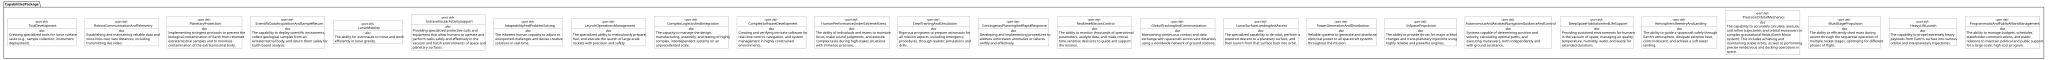

In [ ]:
%viz CapabilitiesPackage --view tree

### ✅ `StakeholderPackage` — `Purpose\StakeholderPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package StakeholderPackage {

	private import CoSMAPackage::*;
	private import AstronautsPackage::*;
	private import StakeholderNeedsPackage::*;

	part def GovernmentAgency :> Stakeholder;
	part def AerospaceCompany :> Stakeholder;
	part def MissionControlPersonnel :> Stakeholder;
	part def ScientificCommunity :> Stakeholder;
	part def Public :> Stakeholder;
	part def Media :> Stakeholder;
	part def ForeignNation :> Stakeholder;

	part NASA : GovernmentAgency {
		:> influenceLevel = StakeholderInfluenceLevel::high;
		:> influenceKind = StakeholderInfluenceKind::direct;
		item concern1 : Concern {
			doc /* Mission Success (technical & operational) */
		} :> concerns;
		item concern2 : Concern {
			doc /* Astronaut Safety */
		} :> concerns;
		item concern3 : Concern {
			doc /* Maintaining Public & Political Funding */
		} :> concerns;
		item concern4 : Concern {
			doc /* International Prestige (Cold War superiority) */
		} :> concerns;
		item concern5 : Concern {
			doc /* Scientific Return from Lunar Samples */
		} :> concerns;
		item concern6 : Concern {
			doc /* Preventing Back Contamination (Quarantine) */
		} :> concerns;
		requirement missionSuccess:MissionSuccess :> needs;
		requirement astronautSafety:AstronautSafety :> needs;
		requirement programmaticFunding:ProgrammaticFunding :> needs;
		requirement internationalPrestige:InternationalPrestige :> needs;
		requirement scientificReturn:ScientificReturn :> needs;
		requirement planetaryProtection:PlanetaryProtection :> needs;
	}

	part Apollo11Crew : Stakeholder {
		:> influenceLevel = StakeholderInfluenceLevel::high;
		:> influenceKind = StakeholderInfluenceKind::direct;
		item concern1 : Concern {
			doc /* Personal Survival */
		} :> concerns;
		item concern2 : Concern {
			doc /* Successful Execution of Mission Procedures */
		} :> concerns;
		item concern3 : Concern {
			doc /* Managing Stress & Performance Pressure */
		} :> concerns;
		item concern4 : Concern {
			doc /* Adeq :> concerns;uate Training & Preparation */
		} :> concerns;
		item concern5 : Concern {
			doc /* Unknowns of Lunar Environment (e.g., dust, regolith stability) */
		} :> concerns;
		requirement crewSurvival:CrewSurvival :> needs;
		requirement proceduralSuccess:ProceduralSuccess :> needs;
		requirement performanceUnderPressure:PerformanceUnderPressure :> needs;
		requirement trainingFidelity:TrainingFidelity :> needs;
		requirement environmentalHazardProtection:EnvironmentalHazardProtection :> needs;
	}

	part MissionControl : MissionControlPersonnel {
		:> influenceLevel = StakeholderInfluenceLevel::high;
		:> influenceKind = StakeholderInfluenceKind::direct;
		item concern1 : Concern {
			doc /* Real-time Problem Solving (e.g., 1202/1201 alarms) */
		} :> concerns;
		item concern2 : Concern {
			doc /* Accurate Data Analysis & Decision Making */
		} :> concerns;
		item concern3 : Concern {
			doc /* Continuous Crew Support & Communication */
		} :> concerns;
		item concern4 : Concern {
			doc /* Operational Flawlessness & Coordination */
		} :> concerns;
		requirement realtimeProblemSolving:RealtimeProblemSolving :> needs;
		requirement dataAccuracy:DataAccuracy :> needs;
		requirement continuousSupport:ContinuousSupport :> needs;
		requirement operationalCoordination:OperationalCoordination :> needs;
	}

	part Grumman : AerospaceCompany {
		:> influenceLevel = StakeholderInfluenceLevel::medium;
		:> influenceKind = StakeholderInfluenceKind::direct;
		item concern1 : Concern {
			doc /* Successful Lunar Module Performance */
		} :> concerns;
		item concern2 : Concern {
			doc /* Meeting Schedule & Budget */
		} :> concerns;
		item concern3 : Concern {
			doc /* Company Reputation */
		} :> concerns;
		requirement lunarModulePerformance:LunarModulePerformance :> needs;
		requirement programmaticAdherence:ProgrammaticAdherence :> needs;
		requirement reputationalSuccess:ReputationalSuccess :> needs;
	}

	part USGovernment : GovernmentAgency {
		:> influenceLevel = StakeholderInfluenceLevel::high;
		:> influenceKind = StakeholderInfluenceKind::direct;
		item concern1 : Concern {
			doc /* National Prestige (Space Race victory) */
		} :> concerns;
		item concern2 : Concern {
			doc /* Public Confidence & Morale */
		} :> concerns;
		item concern3 : Concern {
			doc /* Justifying Financial Investment */
		} :> concerns;
		item concern4 : Concern {
			doc /* National Security */
		} :> concerns;
		requirement nationalPrestige:NationalPrestige :> needs;
		requirement publicConfidence:PublicConfidence :> needs;
		requirement investmentJustification:InvestmentJustification :> needs;
		requirement nationalSecurityDemonstration:NationalSecurityDemonstration :> needs;
	}

	part SovietUnion : ForeignNation {
		:> influenceLevel = StakeholderInfluenceLevel::low;
		:> influenceKind = StakeholderInfluenceKind::indirect;
		item concern1 : Concern {
			doc /* Loss of Prestige (being beaten to the Moon) */
		} :> concerns;
		item concern2 : Concern {
			doc /* Assessing US Technological Capabilities */
		} :> concerns;
	}

	part Geologists : ScientificCommunity {
		:> influenceLevel = StakeholderInfluenceLevel::low;
		:> influenceKind = StakeholderInfluenceKind::indirect;
		item concern1 : Concern {
			doc /* Valuable Lunar Sample Collection */
		} :> concerns;
		item concern2 : Concern {
			doc /* Deployment of Scientific Instruments (e.g., seismometer) */
		} :> concerns;
		item concern3 : Concern {
			doc /* Integrity & Non-contamination of Samples */
		} :> concerns;
		item concern4 : Concern {
			doc /* Access to Data & Samples */
		} :> concerns;
	}

	part AmericanPublic : Public {
		:> influenceLevel = StakeholderInfluenceLevel::medium;
		:> influenceKind = StakeholderInfluenceKind::indirect;
		item concern1 : Concern {
			doc /* National Pride & Inspiration */
		} :> concerns;
		item concern2 : Concern {
			doc /* Astronaut Safety */
		} :> concerns;
		item concern3 : Concern {
			doc /* Cost vs. Other Priorities (minority view) */
		} :> concerns;
	}

	part GlobalPublic : Public {
		:> influenceLevel = StakeholderInfluenceLevel::low;
		:> influenceKind = StakeholderInfluenceKind::indirect;
		item concern1 : Concern {
			doc /* Shared Human Achievement */
		} :> concerns;
		item concern2 : Concern {
			doc /* Peaceful Use of Space */
		} :> concerns;
	}

	part NewsMedia : Media {
		:> influenceLevel = StakeholderInfluenceLevel::medium;
		:> influenceKind = StakeholderInfluenceKind::indirect;
		item concern1 : Concern {
			doc /* Accurate & Timely Reporting */
		} :> concerns;
		item concern2 : Concern {
			doc /* Access to Information & Officials */
		} :> concerns;
		item concern3 : Concern {
			doc /* Compelling Narrative */
		} :> concerns;
	}

	part AstronautFamilies : Stakeholder {
		:> influenceLevel = StakeholderInfluenceLevel::low;
		:> influenceKind = StakeholderInfluenceKind::indirect;
		item concern1 : Concern {
			doc /* Safety of Loved Ones */
		} :> concerns;
		item concern2 : Concern {
			doc /* Privacy from Public Scrutiny */
		} :> concerns;
	}

	part FutureGenerations : Stakeholder {
		:> influenceLevel = StakeholderInfluenceLevel::low;
		:> influenceKind = StakeholderInfluenceKind::indirect;
		item concern1 : Concern {
			doc /* Legacy of Exploration) */
		} :> concerns;
		item concern2 : Concern {
			doc /* Preservation of Knowledge */
		} :> concerns;
	}


}

✅ StakeholderPackage loaded successfully (0.492s)


#### ✅ Visualization: `%viz StakeholderPackage --view tree`

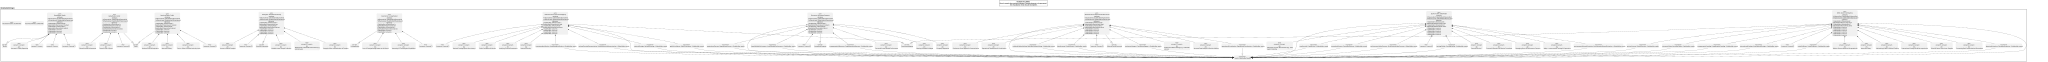

In [ ]:
%viz StakeholderPackage --view tree

### ✅ `MissionRequirementsPackage` — `Requirements\MissionRequirementsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package MissionRequirementsPackage {

	private import SI::*;
	private import ISQ::*;
	private import ScalarValues::*;
	private import CoSMAPackage::*;
	private import CoSMAQuantitiesAndUnitsPackage::*;
	private import USCustomaryUnits::*;
	private import ModelingMetadata::*;


	requirement def <'HLR-R001'> CrewReturnSafetyRequirement {
		doc /* The Apollo 11 Mission shall safely return all three crew members to Earth,
			with no life-threatening injuries or long-term health impacts, by July 24, 1969. */
		@Rationale {
			text = "This requirement is paramount for fulfilling the core mission objective (Go to Moon) and directly addresses the primary concern of all stakeholders (NASA, Astronauts, Families, Public, U.S. Government) regarding human life safety.";
		}
		attribute crewInjuryCount: Integer;
		attribute maxAcceptableInjuries: Integer = 0;

		require constraint { crewInjuryCount <= maxAcceptableInjuries }
		#refinement dependency 'HLR-R001' to CapabilitiesPackage::DeepSpaceHabitationAndLifeSupport;
		#refinement dependency 'HLR-R001' to CapabilitiesPackage::AtmosphericReentryAndLanding;
		#refinement dependency 'HLR-R001' to CapabilitiesPackage::ContingencyPlanningAndRapidResponse;
	}

	requirement def <'HLR-R002'> LunarLanderSoftLandingRequirement {
		doc /* The Apollo 11 Mission shall achieve a soft landing of the crewed lunar lander on the lunar surface
			within the designated landing zone (Tranquility Base), by July 20, 1969. */
		@Rationale {
			text = "A soft and precise lunar landing is fundamental to the 'Go to Moon' goal and ensures the integrity of the lander and safety of the crew for surface operations and subsequent ascent.";
		}

		attribute actualVerticalVelocity :> ISQ::speed;
		attribute maxVerticalVelocity :> ISQ::speed = 2 [m/s];

		attribute actualHorizontalVelocity :> ISQ::speed;
		attribute maxHorizontalVelocity :> ISQ::speed = 0.5 [m/s];

		attribute actualLandingZoneDeviation :> ISQ::length;
		attribute maxLandingZoneDeviation :> ISQ::length = 1000 [m];

		require constraint {
			(actualVerticalVelocity <= maxVerticalVelocity) and
			(actualHorizontalVelocity <= maxHorizontalVelocity) and
			(actualLandingZoneDeviation <= maxLandingZoneDeviation)
		}
		#refinement dependency 'HLR-R002' to CapabilitiesPackage::LunarSurfaceLandingAndAscent;
		#refinement dependency 'HLR-R002' to CapabilitiesPackage::PrecisionOrbitalMechanics;
		#refinement dependency 'HLR-R002' to CapabilitiesPackage::AutonomousAndAssistedNavigationGuidanceAndControl;		
	}

	requirement def <'HLR-R003'> TransLunarInjectionAccuracyRequirement {
		doc /* The Apollo 11 Mission launch system shall successfully place the spacecraft into a Trans-Lunar Injection (TLI) trajectory
			with a delta-V accuracy of +/- 0.5 meters per second and a path leading to lunar orbit insertion within 75 hours from launch,
			on July 16, 1969. */
		@Rationale {
			text = "Accurate Trans-Lunar Injection is essential for reaching the Moon efficiently and correctly, directly supporting the 'Go to Moon' goal and minimizing the need for costly and time-consuming mid-course corrections.";
		}

		attribute actualDeltaVAccuracy :> ISQ::speed;
		attribute maxDeltaVAccuracy :> ISQ::speed = 0.5 [m/s];

		attribute actualTimeToLunarOrbitInsertion :> ISQ::time;
		attribute maxTimeToLunarOrbitInsertion :> ISQ::time = 75 [h];

		require constraint {
			(actualDeltaVAccuracy <= maxDeltaVAccuracy) and
			(actualTimeToLunarOrbitInsertion <= maxTimeToLunarOrbitInsertion)
		}
		#refinement dependency 'HLR-R003' to CapabilitiesPackage::HeavyLiftLaunch;
		#refinement dependency 'HLR-R003' to CapabilitiesPackage::MultiStagePropulsion;
		#refinement dependency 'HLR-R003' to CapabilitiesPackage::PrecisionOrbitalMechanics;		
	}

	requirement def <'HLR-R004'> CommunicationUptimeRequirement {
		doc /* The Apollo 11 Mission's communication system shall maintain continuous voice and telemetry contact with ground control
			for >= 95% of the mission duration, with no single blackout exceeding 10 minutes during lunar farside passes,
			throughout the 8-day mission. */
		@Rationale {
			text = "Reliable communication is vital for real-time mission control, astronaut safety, and public engagement, addressing concerns of Mission Control, NASA, and the public.";
		}

		attribute actualCommunicationUptimePercentage: RatioValue; // Represents a percentage (0-100)
		attribute minCommunicationUptimePercentage: RatioValue = 95['%'];

		attribute maxSingleBlackoutDuration :> ISQ::time;
		attribute allowedSingleBlackoutDuration :> ISQ::time = 10 [min];

		require constraint {
			(actualCommunicationUptimePercentage >= minCommunicationUptimePercentage) and
			(maxSingleBlackoutDuration <= allowedSingleBlackoutDuration)
		}
		#refinement dependency 'HLR-R004' to CapabilitiesPackage::GlobalTrackingAndCommunication;
		#refinement dependency 'HLR-R004' to CapabilitiesPackage::RobustCommunicationAndTelemetry;		
	}

	requirement def <'HLR-R005'> SustainedCabinHabitability {
		doc /* The spacecraft system shall maintain an internal environment that supports crew health and cognitive performance for the mission duration. */
		@Rationale {
			text = "Human life cannot be sustained in the vacuum of space without an artificial environment. Proper habitability is critical for the crew to perform complex tasks.";
		}	
		#refinement dependency SustainedCabinHabitability to CapabilitiesPackage::DeepSpaceHabitationAndLifeSupport;
	}

	requirement def <'HLR-R006'> LunarSampleCollectionQuantityRequirement {
		doc /* The Apollo 11 Mission shall collect a minimum of 20 kilograms of documented lunar surface material,
			including contingency and bulk samples, and return them to Earth within the Mobile Quarantine Facility,
			by July 24, 1969. */
		@Rationale {
			text = "This requirement directly fulfills the 'samples' goal, providing crucial scientific data for understanding the Moon's origin and geology, and supports the scientific community's objectives.";
		}

		attribute actualSampleMass :> ISQ::mass;
		attribute minRequiredSampleMass :> ISQ::mass = 20 [kg];
		attribute contaminationPercentage: RatioValue;
		attribute maxContaminationPercentage: RatioValue = 0.1['%'];

		require constraint {
			(actualSampleMass >= minRequiredSampleMass) and
			(contaminationPercentage <= maxContaminationPercentage)
		}
		#refinement dependency 'HLR-R006' to CapabilitiesPackage::ScientificDataAcquisitionAndSampleReturn;
		#refinement dependency 'HLR-R006' to CapabilitiesPackage::ExtravehicularActivitySupport;		
	}

	requirement def <'HLR-R007'> ScientificInstrumentDeploymentRequirement {
		doc /* The Apollo 11 Mission shall deploy a visual transmission system and at least two scientific experiment packages
			on the lunar surface, and these packages shall transmit data to Earth for a minimum of 1 month post-landing. */
		@Rationale {
			text = "This requirement is essential for achieving the 'deploy' goal, providing long-term scientific data from the lunar surface and enabling public engagement through visual broadcasts.";
		}

		attribute actualDeployedVisualSystems: Integer;
		attribute minRequiredVisualSystems: Integer = 1;

		attribute actualDeployedSciencePackages: Integer;
		attribute minRequiredSciencePackages: Integer = 2;

		attribute actualDataTransmissionDuration :> ISQ::time;
		attribute minDataTransmissionDuration :> ISQ::time = 30 [d];

		require constraint {
			(actualDeployedVisualSystems >= minRequiredVisualSystems) and
			(actualDeployedSciencePackages >= minRequiredSciencePackages) and
			(actualDataTransmissionDuration >= minDataTransmissionDuration)
		}
		#refinement dependency 'HLR-R007' to CapabilitiesPackage::ScientificDataAcquisitionAndSampleReturn;
		#refinement dependency 'HLR-R007' to CapabilitiesPackage::ExtravehicularActivitySupport;		
	}

	requirement def <'HLR-R008'> LunarVisualDocumentationRequirement {
		doc /* The Apollo 11 Mission shall capture and return to Earth at least 1,000 high-resolution still photographs
			and at least 30 minutes of motion picture footage documenting the lunar terrain, deployed equipment,
			and crew activities, by July 24, 1969. */
		@Rationale {
			text = "This requirement directly supports the 'pictures' goal, providing vital visual data for scientific analysis, historical record, and public inspiration and engagement.";
		}

		attribute actualStillPhotosCount: Integer;
		attribute minStillPhotosCount: Integer = 1000;

		attribute actualMotionPictureDuration :> ISQ::time;
		attribute minMotionPictureDuration :> ISQ::time = 30 [min];

		require constraint {
			(actualStillPhotosCount >= minStillPhotosCount) and
			(actualMotionPictureDuration >= minMotionPictureDuration)
		}
		#refinement dependency 'HLR-R008' to CapabilitiesPackage::ScientificDataAcquisitionAndSampleReturn;
	}

	requirement def <'HLR-R009'> NationalSymbolDeploymentRequirement {
		doc /* The Apollo 11 Mission shall successfully plant a national symbol on the lunar surface,
			ensuring it remains upright and visible for subsequent observation (if possible),
			during the initial Extravehicular Activity on July 20, 1969. */
		@Rationale {
			text = "This requirement directly fulfills the 'flag' goal, serving as a powerful symbolic demonstration of national achievement and technological prowess, addressing the U.S. Government's and American Public's interests.";
		}

		attribute symbolSuccessfullyPlanted: Boolean;
		attribute symbolRemainsUpright: Boolean;
		attribute symbolVisibility: Boolean;

		require constraint {
			symbolSuccessfullyPlanted and symbolRemainsUpright and symbolVisibility
		}
		#refinement dependency 'HLR-R009' to CapabilitiesPackage::ExtravehicularActivitySupport;
		#refinement dependency 'HLR-R009' to CapabilitiesPackage::LunarMobility;

	}

	requirement def <'HLR-R010'> PlanetaryProtectionQuarantineRequirement {
		doc /* The Apollo 11 Mission shall implement and adhere to Level V biological quarantine procedures
			for the crew and extraterrestrial samples upon return, ensuring no detectable extraterrestrial
			biological contamination is released into Earth's biosphere, throughout the 21-day quarantine period. */
		@Rationale {
			text = "This requirement is critical for protecting Earth's environment and public health from potential unknown hazards from the Moon, addressing concerns of the U.S. Government and the global public.";
		}

		attribute actualQuarantineLevel: Integer;
		attribute requiredQuarantineLevel: Integer = 5;

		attribute biologicalContaminationDetected: Boolean;
		attribute contaminationThresholdExceeded: Boolean;

		require constraint {
			(actualQuarantineLevel == requiredQuarantineLevel) and
			not biologicalContaminationDetected and
			not contaminationThresholdExceeded
		}
		#refinement dependency 'HLR-R010' to CapabilitiesPackage::PlanetaryProtection;
	}

    requirement def <'HLR-R011'> TrajectoryNavigationPrecision {
        doc /* The mission shall maintain the capability to determine spacecraft position with sufficient 
               accuracy to ensure a safe lunar arrival. */
        @Rationale {
            text = "Precise navigation is required to intercept the Moon and enter the correct lunar orbit. Errors in trajectory determination can lead to mission loss.";
        }
        #refinement dependency TrajectoryNavigationPrecision to CapabilitiesPackage::AutonomousAndAssistedNavigationGuidanceAndControl;
    }

	requirement def <'HLR-R026'> WasteManagementEffectiveness {
		doc /* The Apollo 11 Mission's waste management system shall effectively collect and store all solid and liquid waste
			for the entire mission, preventing contamination of the cabin environment. */
		@Rationale {
			text = "Effective waste management is essential for maintaining a hygienic and safe crew cabin environment, preventing health hazards and equipment contamination.";
		}

		attribute wasteContaminationDetected: Boolean;

		require constraint { not wasteContaminationDetected }
		#refinement dependency 'HLR-R026' to CapabilitiesPackage::DeepSpaceHabitationAndLifeSupport;
	}	

	requirement def <'HLR-R028'> CrewSleepEnvironmentQuality {
		doc /* The Apollo 11 Mission's crew's sleep environment shall allow for at least 6 hours of undisturbed sleep per 24-hour period,
			characterized by noise levels below 60 decibels. */
		@Rationale {
			text = "Adequate and undisturbed sleep is crucial for maintaining crew physical and mental performance, especially during high-stress and long-duration missions.";
		}

		attribute actualUndisturbedSleepDuration :> ISQ::time;
		attribute minUndisturbedSleepDuration :> ISQ::time = 6 [h];

		attribute actualNoiseLevelMax :> ISQ::soundPressureLevel;
		attribute maxNoiseLevelReqd :> ISQ::soundPressureLevel = 60 ['dB'];

		require constraint {
			(actualUndisturbedSleepDuration >= minUndisturbedSleepDuration) and
			(actualNoiseLevelMax <= maxNoiseLevelReqd)
		}
		#refinement dependency 'HLR-R028' to CapabilitiesPackage::DeepSpaceHabitationAndLifeSupport;
	}

	requirement def <'HLR-R030'> CrewAlarmResponseTime {
		doc /* The Apollo 11 Mission's crew interface system shall provide visual and auditory alarms for all critical system failures,
			with an alarm response time of <= 1 second. */
		@Rationale {
			text = "Rapid and clear alarming is essential for the crew to quickly identify and respond to critical system failures, mitigating risks and ensuring safety.";
		}

		attribute actualAlarmResponseTime :> ISQ::time;
		attribute maxAlarmResponseTime :> ISQ::time = 1 [s];

		require constraint { actualAlarmResponseTime <= maxAlarmResponseTime }
		#refinement dependency 'HLR-R030' to CapabilitiesPackage::DeepSpaceHabitationAndLifeSupport;
	}

	requirement def <'HLR-R032'> LunarLanderToOrbiterVoiceComm {
		doc /* The Apollo 11 Mission's lunar lander's communication system shall enable voice communication between the crew on the surface
			and the crew in lunar orbit, with a signal clarity of 90% (subjective scoring). */
		@Rationale {
			text = "Reliable voice communication between the lander and orbiter crews is crucial for coordinating critical operations like rendezvous and docking, ensuring safety and mission success.";
		}

		attribute actualSignalClarity: RatioValue;
		attribute minSignalClarity: RatioValue = 90['%'];

		require constraint { actualSignalClarity >= minSignalClarity }
		#refinement dependency 'HLR-R032' to CapabilitiesPackage::RobustCommunicationAndTelemetry;
	}

	requirement def <'HLR-R033'> ExtravehicularMobilityUnitLifeSupportDuration {
		doc /* The Apollo 11 Mission's Extravehicular Mobility Unit shall provide life support for a minimum of 4 hours
			of continuous Extravehicular Activity in the lunar environment. */
		@Rationale {
			text = "Sufficient life support duration for the Extravehicular Mobility Unit is necessary to enable astronauts to perform required tasks on the lunar surface, supporting scientific and symbolic goals.";
		}

		attribute actualEMULifeSupportDuration :> ISQ::time;
		attribute minEMULifeSupportDuration :> ISQ::time = 4 [h];

		require constraint { actualEMULifeSupportDuration >= minEMULifeSupportDuration }
		#refinement dependency 'HLR-R033' to CapabilitiesPackage::ExtravehicularActivitySupport;
	}

	requirement def <'HLR-R035'> ExtravehicularMobilityUnitDexterityForTasks {
		doc /* The Apollo 11 Mission's Extravehicular Mobility Unit shall allow for manual dexterity sufficient to operate small tools and manipulate samples
			with gloved hands, demonstrating a 90% success rate for task completion during Extravehicular Activity simulations. */
		@Rationale {
			text = "Adequate dexterity in the Extravehicular Mobility Unit is essential for astronauts to effectively perform scientific and operational tasks on the lunar surface, directly impacting mission success.";
		}

		attribute actualTaskCompletionSuccessRate: RatioValue;
		attribute minTaskCompletionSuccessRate: RatioValue = 90['%'];

		require constraint { actualTaskCompletionSuccessRate >= minTaskCompletionSuccessRate }
		#refinement dependency 'HLR-R035' to CapabilitiesPackage::ExtravehicularActivitySupport;
		#refinement dependency 'HLR-R035' to CapabilitiesPackage::ToolDevelopment;		
	}

	requirement def <'HLR-R036'> LunarSurfaceMobilityRange {
		doc /* The Apollo 11 Mission's lunar surface mobility system shall enable astronauts to traverse distances of up to 50 meters
			from the lander during Extravehicular Activity with less than 10% fatigue impact on subsequent tasks. */
		@Rationale {
			text = "Ensuring efficient and manageable astronaut mobility on the lunar surface is important for maximizing the scientific return and operational effectiveness of Extravehicular Activities.";
		}

		attribute actualTraverseDistanceCapability :> ISQ::length;
		attribute minTraverseDistanceCapability :> ISQ::length = 50 [m];

		attribute actualFatigueImpact: RatioValue;
		attribute maxFatigueImpact: RatioValue = 10['%'];

		require constraint {
			(actualTraverseDistanceCapability >= minTraverseDistanceCapability) and
			(actualFatigueImpact <= maxFatigueImpact)
		}
		#refinement dependency 'HLR-R036' to CapabilitiesPackage::LunarMobility;
	}

	requirement def <'HLR-R037'> ExtravehicularActivityToolSecurity {
		doc /* All Extravehicular Activity tools used in the Apollo 11 Mission shall be operable with a minimum of two points of contact (e.g., tethered or hand-held)
			to prevent loss in lunar gravity. */
		@Rationale {
			text = "Securing tools during Extravehicular Activity is vital to prevent loss in the low lunar gravity environment, ensuring tools are available for all planned tasks and do not become debris.";
		}

		attribute toolsMeetContactRequirement: Boolean;
		attribute toolsLostDuringEVA: Integer;
		attribute maxToolsLost: Integer = 0;

		require constraint {
			toolsMeetContactRequirement and
			(toolsLostDuringEVA <= maxToolsLost)
		}
		#refinement dependency 'HLR-R037' to CapabilitiesPackage::ExtravehicularActivitySupport;
	}

	requirement def <'HLR-R038'> SamplePristinePreservation {
		doc /* Apollo 11 Mission's lunar samples shall be collected and stored in a manner that preserves their pristine lunar environment
			and prevents terrestrial contamination, ensuring less than 0.1% terrestrial material contamination by mass. */
		@Rationale {
			text = "Maintaining the pristine state of lunar samples is crucial for their scientific value, as contamination would compromise the integrity of geological analysis and understanding of lunar composition.";
		}

		attribute actualTerrestrialContamination: RatioValue;
		attribute maxTerrestrialContamination: RatioValue = 0.1['%'];

		require constraint { actualTerrestrialContamination <= maxTerrestrialContamination }
		#refinement dependency 'HLR-R038' to CapabilitiesPackage::ScientificDataAcquisitionAndSampleReturn;
		#refinement dependency 'HLR-R038' to CapabilitiesPackage::PlanetaryProtection;		
	}

	requirement def <'HLR-R040'> SampleGeologicalContext {
		doc /* The Apollo 11 Mission shall obtain geological context for all collected samples through photographic documentation
			with clear scale references, ensuring >= 90% of samples are correlated with their collection location. */
		@Rationale {
			text = "Providing accurate geological context for samples is vital for interpreting their scientific significance and understanding the Moon's stratigraphy and formation.";
		}

		attribute actualSampleCorrelationPercentage: RatioValue;
		attribute minSampleCorrelationPercentage: RatioValue = 90['%'];
		attribute photosHaveScaleReferences: Boolean;

		require constraint {
			(actualSampleCorrelationPercentage >= minSampleCorrelationPercentage) and
			photosHaveScaleReferences
		}
		#refinement dependency 'HLR-R040' to CapabilitiesPackage::ScientificDataAcquisitionAndSampleReturn;
	}

	requirement def <'HLR-R045'> CriticalComponentRedundancy {
		doc /* The Apollo 11 Mission shall have redundancy (N+1 or greater) for all critical single-point-of-failure components
			in propulsion, Guidance, Navigation, and Control, and life support systems, ensuring continued operation after a single failure. */
		@Rationale {
			text = "Redundancy for single points of failure is a fundamental safety and reliability measure, allowing the mission to continue even if a critical component fails.";
		}

		attribute singleFailureCausesOperationalLoss: Boolean;

		require constraint { not singleFailureCausesOperationalLoss }
		#refinement dependency 'HLR-R045' to CapabilitiesPackage::ContingencyPlanningAndRapidResponse;
	}

	requirement def <'HLR-R046'> AbortSequenceExecutionTime {
		doc /* Apollo 11 Mission Control shall be capable of initiating and executing an abort sequence
			from any point during ascent or Trans-Lunar/Earth Coast within 5 minutes of an abort decision. */
		@Rationale {
			text = "Rapid abort capability is a critical safety net, allowing the mission to be terminated and the crew safely returned in response to unforeseen catastrophic failures.";
		}

		attribute actualAbortExecutionTime :> ISQ::time;
		attribute maxAbortExecutionTime :> ISQ::time = 5 [min];

		require constraint { actualAbortExecutionTime <= maxAbortExecutionTime }
		#refinement dependency 'HLR-R046' to CapabilitiesPackage::ContingencyPlanningAndRapidResponse;
		#refinement dependency 'HLR-R046' to CapabilitiesPackage::RealtimeMissionControl;		
	}

	requirement def <'HLR-R047'> ManualOverrideResponseTime {
		doc /* The Apollo 11 Mission's crew shall be able to manually override automated flight control systems
			for all major maneuvers (e.g., Trans-Lunar Injection, Lunar Orbit Insertion, Powered Descent Initiation) with a response time of <= 1 second. */
		@Rationale {
			text = "Manual override capability provides a crucial human element of control and contingency in case automated systems fail or encounter unexpected conditions, directly enhancing safety.";
		}

		attribute actualOverrideResponseTime :> ISQ::time;
		attribute maxOverrideResponseTime :> ISQ::time = 1 [s];

		require constraint { actualOverrideResponseTime <= maxOverrideResponseTime }
		#refinement dependency 'HLR-R047' to CapabilitiesPackage::HumanPerformanceUnderExtremeStress;
	}

	requirement def <'HLR-R048'> GroundSegmentDataUpdateFrequency {
		doc /* The Apollo 11 Mission's ground segment shall provide up-to-date trajectory and state vector information
			to the flight crew at least every 10 minutes during dynamic flight phases. */
		@Rationale {
			text = "Frequent and up-to-date information from ground control is essential for the crew's situational awareness, navigation, and ability to execute maneuvers safely and accurately.";
		}

		attribute actualUpdateInterval :> ISQ::time;
		attribute maxUpdateInterval :> ISQ::time = 10 [min];

		require constraint { actualUpdateInterval <= maxUpdateInterval }
		#refinement dependency 'HLR-R048' to CapabilitiesPackage::RealtimeMissionControl;
	}

	requirement def <'HLR-R049'> LunarLanderAscentReadinessTime {
		doc /* The Apollo 11 Mission's lunar lander's ascent stage shall be capable of launching from the lunar surface
			within 24 hours of landing, to align with rendezvous opportunities in lunar orbit. */
		@Rationale {
			text = "A limited readiness time for ascent ensures the crew can depart the lunar surface within favorable orbital mechanics windows for rendezvous, crucial for their return.";
		}

		attribute actualTimeFromLandingToAscentLaunch :> ISQ::time;
		attribute maxTimeToAscentLaunch :> ISQ::time = 24 [h];

		require constraint { actualTimeFromLandingToAscentLaunch <= maxTimeToAscentLaunch }
		#refinement dependency 'HLR-R049' to CapabilitiesPackage::LunarSurfaceLandingAndAscent;
	}

	requirement def <'HLR-R050'> FlightSoftwareUpdateTime {
		doc /* Apollo 11 Mission Control shall be able to reconfigure and uplink flight software updates
			to the spacecraft's primary computers within 1 hour in response to critical in-flight anomalies. */
		@Rationale {
			text = "The ability to rapidly update flight software in-flight provides a vital corrective capability to address unforeseen bugs or adapt to changing mission conditions.";
		}

		attribute actualSoftwareUpdateDuration :> ISQ::time;
		attribute maxSoftwareUpdateDuration :> ISQ::time = 1 [h];

		require constraint { actualSoftwareUpdateDuration <= maxSoftwareUpdateDuration }
		#refinement dependency 'HLR-R050' to CapabilitiesPackage::ComplexSoftwareDevelopment;
	}

	requirement def <'HLR-R052'> CrewEmergencyMedicalProficiency {
		doc /* The Apollo 11 Mission crew shall demonstrate proficiency in emergency medical procedures
			to handle common in-flight illnesses or minor injuries without external assistance for up to 72 hours. */
		@Rationale {
			text = "Crew self-sufficiency in basic medical emergencies is essential given the vast distances and isolation of lunar missions, where immediate external medical aid is impossible.";
		}

		attribute medicalProficiencyScore: Real;
		attribute minMedicalProficiencyScore: Real = 90;

		attribute externalAssistanceRequiredBeforeTime :> ISQ::time;
		attribute minSelfSufficiencyDuration :> ISQ::time = 72 [h];

		require constraint {
			(medicalProficiencyScore >= minMedicalProficiencyScore) and
			(externalAssistanceRequiredBeforeTime >= minSelfSufficiencyDuration)
		}
		#refinement dependency 'HLR-R052' to CapabilitiesPackage::CrewTrainingAndSimulation;
	}

	requirement def <'HLR-R053'> InFlightProcedureErrorRate {
		doc /* The Apollo 11 Mission crew shall be capable of performing all critical in-flight procedures (e.g., docking, re-entry preparation)
			with an error rate of <= 0.5% under nominal conditions. */
		@Rationale {
			text = "A very low error rate for critical procedures is paramount for mission success and crew safety, as failures in these steps could have catastrophic consequences.";
		}

		attribute actualProcedureErrorRate: RatioValue;
		attribute maxProcedureErrorRate: RatioValue = 0.5['%'];

		require constraint { actualProcedureErrorRate <= maxProcedureErrorRate }
		#refinement dependency 'HLR-R053' to CapabilitiesPackage::HumanPerformanceUnderExtremeStress;
	}

	requirement def <'HLR-R054'> CrewNutritionAndHydration {
		doc /* Apollo 11 Mission astronauts shall be able to consume all provided food and water
			throughout the mission without experiencing significant gastrointestinal issues or nutrient deficiencies. */
		@Rationale {
			text = "Adequate nutrition and hydration are fundamental for maintaining astronaut health, energy levels, and cognitive function throughout the demanding mission.";
		}

		attribute significantGIIssuesExperienced: Boolean;
		attribute nutrientDeficienciesObserved: Boolean;

		require constraint {
			not significantGIIssuesExperienced and
			not nutrientDeficienciesObserved
		}
		#refinement dependency 'HLR-R054' to CapabilitiesPackage::DeepSpaceHabitationAndLifeSupport;
	}

	requirement def <'HLR-R055'> CrewPsychologicalState {
		doc /* The Apollo 11 Mission crew shall maintain a positive psychological state as assessed by structured psychological evaluations
			throughout the mission. */
		@Rationale {
			text = "Crew psychological well-being is vital for effective teamwork, decision-making, and overall mission performance, especially during long periods of isolation and stress.";
		}

		attribute actualPsychologicalStateScore: Real; // e.g., on a positive/negative scale (0-100)
		attribute minPsychologicalStateScore: Real = 75;

		require constraint { actualPsychologicalStateScore >= minPsychologicalStateScore }
		#refinement dependency 'HLR-R055' to CapabilitiesPackage::HumanPerformanceUnderExtremeStress;
	}

	requirement def <'HLR-R057'> MicrometeoroidPenetrationRisk {
		doc /* The Apollo 11 Mission spacecraft shall be designed to minimize micro-meteoroid penetration risk
			to critical habitable volumes to less than 1 event in 1,000 missions. */
		@Rationale {
			text = "Minimizing micrometeoroid penetration risk is a key safety requirement to protect the crew and critical systems from space debris impacts that could cause depressurization or damage.";
		}

		attribute actualPenetrationProbabilityPerMission: Real; // Represents a probability (0-1)
		attribute maxAcceptablePenetrationProbability: Real = 0.001; // 1/1000

		require constraint { actualPenetrationProbabilityPerMission <= maxAcceptablePenetrationProbability }
		#refinement dependency 'HLR-R057' to CapabilitiesPackage::DeepSpaceHabitationAndLifeSupport;
	}

	requirement def <'HLR-R059'> LunarElementEnvironmentalResistance {
		doc /* All external mission elements left on the lunar surface by the Apollo 11 Mission shall be designed to withstand lunar thermal cycles
			(approx. +/- 150°C) and lunar dust exposure for a minimum of 3 months while maintaining structural integrity. */
		@Rationale {
			text = "Ensuring the long-term survival of deployed lunar elements in the harsh lunar environment is crucial for extended scientific data collection and mission legacy.";
		}

		attribute structuralIntegrityMaintained: Boolean;
		attribute minResistanceDuration :> ISQ::time;
		require constraint { structuralIntegrityMaintained } // Assuming tested duration meets minResistanceDuration
		#refinement dependency 'HLR-R059' to CapabilitiesPackage::ScientificDataAcquisitionAndSampleReturn;
	}

	requirement def <'HLR-R060'> PostFlightDataArchiving {
		doc /* The Apollo 11 Mission shall ensure post-flight data retention and archiving of all telemetry, voice, video,
			and scientific data, maintaining 99.99% data availability for future analysis for a minimum of 50 years. */
		@Rationale {
			text = "Long-term data archiving ensures that valuable mission data is preserved for future scientific research, engineering analysis, and historical purposes, benefiting future generations.";
		}

		attribute actualDataAvailabilityPercentage: RatioValue;
		attribute minDataAvailabilityPercentage: RatioValue = 99.99['%'];

		attribute actualArchivalDuration :> ISQ::time;
		attribute minArchivalDuration :> ISQ::time = 50 ['yr'];

		require constraint {
			(actualDataAvailabilityPercentage >= minDataAvailabilityPercentage) and
			(actualArchivalDuration >= minArchivalDuration)
		}
		#refinement dependency 'HLR-R060' to CapabilitiesPackage::ComplexLogisticsAndIntegration;
	}

    requirement def <'HLR-R061'> PropulsionSystemMissionReliability {
        doc /* The mission's major maneuvers shall be executed using highly reliable propulsive systems 
               to ensure mission success and return. */
        @Rationale {
            text = "Failure during critical maneuvers like LOI or TEI would leave the crew stranded. Engine systems must be highly predictable.";
        }
        #refinement dependency 'HLR-R061' to CapabilitiesPackage::InSpacePropulsion;
    }

    requirement def <'HLR-R062'> MechanicalLoadResilience {
        doc /* All primary structures shall withstand the flight environment without compromising 
               mission functionality. */
        @Rationale {
            text = "The spacecraft must survive extreme mechanical stresses during launch and reentry to protect internal subsystems.";
        }
        #refinement dependency 'HLR-R062' to CapabilitiesPackage::HeavyLiftLaunch;
    }

    requirement def <'HLR-R063'> LiveVisualBroadcast {
        doc /* The mission shall provide a live visual record of lunar surface operations to satisfy 
               public and scientific return goals. */
        @Rationale {
            text = "Real-time coverage is vital for fulfilling national prestige and providing visual context for Mission Control.";
        }
        #refinement dependency 'HLR-R063' to CapabilitiesPackage::RobustCommunicationAndTelemetry;
    }

    requirement def <'HLR-R064'> ExtendedScientificOperation {
        doc /* Deployed lunar elements shall remain operational post-landing to provide 
               long-term data return. */
        @Rationale {
            text = "Scientific value is maximized by instruments that continue to collect data long after the crew departs.";
        }
        #refinement dependency 'HLR-R064' to CapabilitiesPackage::ScientificDataAcquisitionAndSampleReturn;
    }

    requirement def <'HLR-R065'> CriticalSystemAvailability {
        doc /* All mission-critical systems shall be designed for maximum uptime to prevent 
               catastrophic mission loss. */
        @Rationale {
            text = "High availability is the cornerstone of safety, ensuring that single-point failures do not result in the loss of crew or spacecraft.";
        }
        #refinement dependency 'HLR-R065' to CapabilitiesPackage::ComplexLogisticsAndIntegration;
    }	

	requirement def <'HLR-R066'> PublicSupportAndAffairsManagement {
		doc /* The Apollo 11 program shall maintain a public affairs office to provide real-time updates and 
		       educational materials to the global public, ensuring a favorable public opinion rating of 
		       at least 60% throughout the mission duration. */
		@Rationale {
			text = "Sustained political and public support is necessary to maintain the massive financial commitment required for the program's existence.";
		}
		#refinement dependency 'HLR-R066' to CapabilitiesPackage::ProgrammaticAndPublicAffairsManagement;
	}

	requirement def <'HLR-R067'> ElectricalPowerAvailability {
		doc /* The spacecraft electrical power system shall provide a continuous supply of regulated DC power 
		       to all primary bus systems, maintaining a minimum of 25% energy reserve at all times 
		       during the nominal mission profile. */
		@Rationale {
			text = "Reliable power distribution is fundamental to the operation of all other spacecraft systems and is a prerequisite for mission success.";
		}
		#refinement dependency 'HLR-R067' to CapabilitiesPackage::PowerGenerationAndDistribution;
	}

	requirement def <'HLR-R068'> LaunchWindowPrecision {
		doc /* Launch operations shall execute the final countdown and ignition sequence within a ±2.5-second 
		       launch window to ensure the spacecraft meets the required planetary alignment for the 
		       Trans-Lunar Injection. */
		@Rationale {
			text = "Precise management of ground-based launch activities is required to ensure the launch system places the spacecraft into the correct trajectory efficiently.";
		}
		#refinement dependency 'HLR-R068' to CapabilitiesPackage::LaunchOperationsManagement;
	}

	requirement def <'HLR-R069'> OperationalWorkaroundProtocol {
		doc /* The mission architecture shall provide the crew and ground controllers with 'workaround' 
		       protocols for all non-critical system anomalies, enabling mission continuation despite 
		       minor hardware or software deviations. */
		@Rationale {
			text = "The inherent human capacity to adjust to unexpected challenges is a critical safety function that allows for mission success when automated systems encounter unforeseen conditions.";
		}
		#refinement dependency 'HLR-R069' to CapabilitiesPackage::AdaptabilityAndProblemSolving;
	}

}

✅ MissionRequirementsPackage loaded successfully (1.443s)


#### ✅ Visualization: `%viz MissionRequirementsPackage --view tree`

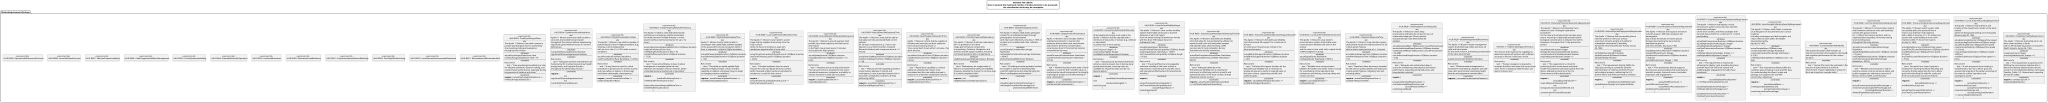

In [ ]:
%viz MissionRequirementsPackage --view tree

### ✅ `CoSMAViewsPackage` — `CoSMA\CoSMAViewsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

library package CoSMAViewsPackage {
	
	view RequirementsTableView {
		//expose Requirements::MissionRequirementsPackage::*;
		//filter hastype SysML::Systems::RequirementDefinition;
	}
}

✅ CoSMAViewsPackage loaded successfully (0.118s)


#### ✅ Visualization: `%viz CoSMAViewsPackage --view tree`

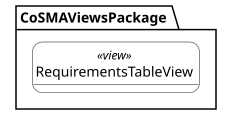

In [ ]:
%viz CoSMAViewsPackage --view tree

### ✅ `FunctionalRequirementsPackage` — `Requirements\FunctionalRequirementsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package FunctionalRequirementsPackage {
    
	private import SI::*;
	private import ISQ::*;
	private import ScalarValues::*;
	private import CoSMAQuantitiesAndUnitsPackage::*;
	private import USCustomaryUnits::*;
	private import ModelingMetadata::*;
    private import CoSMAPackage::*;
    private import MissionRequirementsPackage::*;

	requirement def <'FLR-R001'> PropellantLoadingRequirement {
		doc /* The system shall enable the loading of all required propellants and consumables into the vehicle's storage systems. */
		@Rationale {
			text = "All propulsive stages and life support systems must be fully supplied to perform their functions for the mission's duration.";
		}
		#refinement dependency 'FLR-R001' to MissionRequirementsPackage::'HLR-R001';
	}

	requirement def <'FLR-R002'> ConsumableConditioningRequirement {
		doc /* The system shall maintain all loaded propellants and consumables at their required temperature and pressure prior to launch. */
		@Rationale {
			 text = "Cryogenic propellants and other consumables must be kept in a stable state to ensure vehicle integrity and readiness for engine start.";
		}
		#refinement dependency 'FLR-R002' to MissionRequirementsPackage::'HLR-R005';
	}

	requirement def <'FLR-R003'> CrewIngressRequirement {
		doc /* The system shall provide a safe method for the flight crew to enter and be secured within the crew cabin. */
		@Rationale {
			 text = "The crew must be safely positioned and secured within the vehicle to withstand the forces of launch.";
		}
		#refinement dependency CrewIngressRequirement to MissionRequirementsPackage::'HLR-R001';
	}

	requirement def <'FLR-R004'> CabinPressurizationRequirement {
		doc /* The system shall verify the pressure integrity of the crew cabin after crew ingress. */
		@Rationale {
			 text = "A sealed cabin is fundamental for providing a habitable, life-sustaining environment for the crew.";
		}
		#refinement dependency CabinPressurizationRequirement to MissionRequirementsPackage::'HLR-R005';
	}

	requirement def <'FLR-R005'> CountdownSequencingRequirement {
		doc /* The system shall execute a synchronized sequence of pre-launch checks and configurations. */
		@Rationale {
			 text = "A precisely timed sequence is necessary to ensure thousands of vehicle and ground systems are correctly configured for launch.";
		}
		#refinement dependency 'FLR-R005' to MissionRequirementsPackage::'HLR-R068';
	}

	requirement def <'FLR-R006'> CountdownAbortRequirement {
		doc /* The system shall be capable of holding or aborting the countdown if any critical system parameter violates pre-defined limits. */
		@Rationale {
			 text = "This capability is a critical safety function to prevent launching a vehicle that is not in a nominal state.";
		}
		#refinement dependency CountdownAbortRequirement to MissionRequirementsPackage::'HLR-R046';
	}

	requirement def <'FLR-R007'> Stage1ThrustInitiationRequirement {
		doc /* The system shall initiate first stage main propulsion upon receiving a valid, authenticated launch command. */
		@Rationale {
			 text = "Reliable and timely initiation of ascent thrust is critical for leaving the launch pad and beginning the flight profile as planned.";
		}
		#refinement dependency 'FLR-R007' to MissionRequirementsPackage::'HLR-R062';
	}

	requirement def <'FLR-R008'> Stage1ThrustMagnitudeRequirement {
		doc /* The system shall generate a propulsive force from the first stage that results in a positive vertical acceleration at liftoff. */
		@Rationale {
			 text = "A thrust-to-weight ratio greater than one is the fundamental condition required to overcome gravity and lift the vehicle off the launch pad.";
		}
		#refinement dependency 'FLR-R008' to MissionRequirementsPackage::'HLR-R062';
	}

	requirement def <'FLR-R009'> Stage2ThrustInitiationRequirement {
		doc /* The system shall initiate second stage propulsion following the clean separation of the first stage. */
		@Rationale {
			 text = "Continuous acceleration is required to achieve the velocity needed to reach the upper atmosphere.";
		}
		#refinement dependency 'FLR-R009' to MissionRequirementsPackage::'HLR-R062';
	}

	requirement def <'FLR-R010'> Stage2PropulsionRequirement {
		doc /* The system shall provide continuous thrust from the second stage to propel the vehicle through the upper atmosphere. */
		@Rationale {
			 text = "The second stage is optimized to provide efficient thrust in near-vacuum conditions.";
		}
		#refinement dependency 'FLR-R010' to MissionRequirementsPackage::'HLR-R062';
	}

	requirement def <'FLR-R011'> OrbitInsertionThrustInitiationRequirement {
		doc /* The system shall initiate third stage propulsion to provide the final thrust needed to achieve a stable Earth orbit. */
		@Rationale {
			 text = "A final, precise propulsive burn is required to circularize the orbit and prevent the vehicle from falling back to Earth.";
		}
		#refinement dependency 'FLR-R011' to MissionRequirementsPackage::'HLR-R003';
	}
	
	requirement def <'FLR-R012'> OrbitInsertionThrustTerminationRequirement {
		doc /* The system shall terminate third stage thrust upon receiving a cutoff command. */
		@Rationale {
			 text = "Precise thrust termination is critical for achieving the correct orbital parameters.";
		}
		#refinement dependency OrbitInsertionThrustTerminationRequirement to MissionRequirementsPackage::'HLR-R003';
	}

	requirement def <'FLR-R013'> AscentGuidanceRequirement {
		doc /* The system shall autonomously control the vehicle's trajectory during ascent according to a pre-programmed flight plan. */
		@Rationale {
			 text = "Automated guidance is necessary to manage the complex, high-speed ascent profile with precision.";
		}
		#refinement dependency AscentGuidanceRequirement to MissionRequirementsPackage::'HLR-R003';
	}

	requirement def <'FLR-R014'> AscentStagingCommandRequirement {
		doc /* The system shall issue commands to separate expended stages at pre-determined points in the ascent profile. */
		@Rationale {
			 text = "Jettisoning mass is essential for maximizing the efficiency of the upper stages.";
		}
		#refinement dependency 'FLR-R014' to MissionRequirementsPackage::'HLR-R003';
	}

	requirement def <'FLR-R015'> CrewAscentMonitoringRequirement {
		doc /* The system shall display critical vehicle parameters to the flight crew during ascent. */
		@Rationale {
			 text = "The crew must have situational awareness to monitor vehicle health and make manual control or abort decisions.";
		}
		#refinement dependency CrewAscentMonitoringRequirement to MissionRequirementsPackage::'HLR-R001';
	}

	requirement def <'FLR-R016'> CrewAscentAbortRequirement {
		doc /* The system shall provide an interface for the crew to manually initiate a launch abort sequence. */
		@Rationale {
			 text = "Manual abort is a key safety feature that provides the crew with ultimate control in a contingency.";
		}
		#refinement dependency CrewAscentAbortRequirement to MissionRequirementsPackage::'HLR-R046';
	}

	requirement def <'FLR-R017'> GroundTelemetryAnalysisRequirement {
		doc /* The system shall receive, process, and display real-time telemetry from the launch vehicle to ground personnel. */
		@Rationale {
			 text = "Ground teams must have accurate, real-time data to monitor vehicle health and provide support.";
		}
		#refinement dependency 'FLR-R017' to MissionRequirementsPackage::'HLR-R048';
	}

	requirement def <'FLR-R018'> GroundPerformanceVerificationRequirement {
		doc /* The system shall compare vehicle performance against pre-defined limits and provide go/no-go recommendations. */
		@Rationale {
			 text = "This function provides an independent verification of vehicle performance, enhancing mission safety.";
		}
		#refinement dependency GroundPerformanceVerificationRequirement to MissionRequirementsPackage::'HLR-R048';
	}

	requirement def <'FLR-R019'> TliThrustInitiationRequirement {
		doc /* The system shall provide a propulsive force to cause the vehicle to escape Earth's orbit. */
		@Rationale {
			 text = "A major propulsive maneuver is required to increase velocity from orbital to escape speed.";
		}
		#refinement dependency 'FLR-R019' to MissionRequirementsPackage::'HLR-R003';
	}
	
	requirement def <'FLR-R020'> TliThrustControlRequirement {
		doc /* The system shall guide the translunar injection burn to achieve the required trajectory accuracy. */
		@Rationale {
			 text = "The accuracy of this burn is critical to ensure the spacecraft arrives at the correct position and time near the Moon.";
		}
		#refinement dependency TliThrustControlRequirement to MissionRequirementsPackage::'HLR-R003';
	}
	
	requirement def <'FLR-R021'> ModuleSeparationRequirement {
		doc /* The system shall enable the primary spacecraft to separate from its launch vehicle adapter. */
		@Rationale {
			 text = "Separation is required before the spacecraft can be reconfigured for the journey to the Moon.";
		}
		#refinement dependency 'FLR-R021' to MissionRequirementsPackage::'HLR-R001';
	}

	requirement def <'FLR-R022'> ModuleRepositioningRequirement {
		doc /* The system shall enable the controlled repositioning of the primary spacecraft after separation. */
		@Rationale {
			 text = "The spacecraft must be turned around to face the stowed lunar module for docking.";
		}
		#refinement dependency 'FLR-R022' to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R023'> ModuleConnectionRequirement {
		doc /* The system shall enable the physical connection and sealing of two separate spacecraft modules in space. */
		@Rationale {
			 text = "A rigid, pressurized connection is required to allow for crew transfer and to form the complete translunar vehicle.";
		}
		#refinement dependency 'FLR-R023' to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R024'> InSpacePropulsionRequirement {
		doc /* The system shall provide a propulsive force for major in-space trajectory changes. */
		@Rationale {
			 text = "A restartable, high-thrust engine is required for critical maneuvers like lunar orbit insertion and transearth injection.";
		}
		#refinement dependency 'FLR-R024' to MissionRequirementsPackage::'HLR-R061';
	}
	
	requirement def <'FLR-R025'> AttitudeControlRequirement {
		doc /* The system shall provide low-thrust propulsive forces to control the orientation of the spacecraft. */
		@Rationale {
			 text = "Precise attitude control is required for thermal regulation, communications antenna pointing, and alignment for main engine burns.";
		}
		#refinement dependency 'FLR-R025' to MissionRequirementsPackage::'HLR-R061';
	}

	requirement def <'FLR-R026'> NavigationalDataAcquisitionRequirement {
		doc /* The system shall enable the acquisition of celestial navigation data. */
		@Rationale {
			 text = "Regular position fixes are necessary to maintain an accurate understanding of the vehicle's trajectory.";
		}
		#refinement dependency NavigationalDataAcquisitionRequirement to MissionRequirementsPackage::'HLR-R011';
	}

	requirement def <'FLR-R027'> TrajectoryCalculationRequirement {
		doc /* The system shall calculate the vehicle's current trajectory based on navigational data. */
		@Rationale {
			 text = "The current trajectory must be known in order to calculate necessary course corrections.";
		}
		#refinement dependency TrajectoryCalculationRequirement to MissionRequirementsPackage::'HLR-R011';
	}
	
	requirement def <'FLR-R028'> CourseCorrectionCalculationRequirement {
		doc /* The system shall calculate the required propulsive maneuver to correct any deviations from the planned trajectory. */
		@Rationale {
			 text = "This function is essential for ensuring an accurate arrival at the Moon and minimizing fuel usage.";
		}
		#refinement dependency 'FLR-R028' to MissionRequirementsPackage::'HLR-R011';
	}
	
	requirement def <'FLR-R029'> CourseCorrectionExecutionRequirement {
		doc /* The system shall execute a calculated course correction maneuver. */
		@Rationale {
			 text = "The ability to act on calculated corrections is required to maintain the proper flight path.";
		}
		#refinement dependency 'FLR-R029' to MissionRequirementsPackage::'HLR-R011';
	}
	
	requirement def <'FLR-R030'> CrewSystemMonitoringRequirement {
		doc /* The system shall display the status of all critical subsystems to the crew. */
		@Rationale {
			 text = "Continuous situational awareness of system health is required for the crew to manage the mission and respond to anomalies.";
		}
		#refinement dependency CrewSystemMonitoringRequirement to MissionRequirementsPackage::'HLR-R030';
	}
	
	requirement def <'FLR-R031'> GroundSystemMonitoringRequirement {
		doc /* The system shall transmit the status of all critical subsystems to the ground. */
		@Rationale {
			 text = "Ground controllers provide a vital support and analysis function that depends on receiving continuous, accurate telemetry.";
		}
		#refinement dependency 'FLR-R031' to MissionRequirementsPackage::'HLR-R004';
	}
	
	requirement def <'FLR-R032'> SpacecraftDataTransmissionRequirement {
		doc /* The system shall transmit voice, telemetry, and video data to the ground network. */
		@Rationale {
			 text = "Data transmission is required to support ground control functions and meet public engagement objectives.";
		}
		#refinement dependency SpacecraftDataTransmissionRequirement to MissionRequirementsPackage::'HLR-R004';
	}

	requirement def <'FLR-R033'> SpacecraftDataReceptionRequirement {
		doc /* The system shall receive and process commands and voice data from the ground network. */
		@Rationale {
			 text = "The crew must be able to receive updated plans, information, and commands from Mission Control.";
		}
		#refinement dependency SpacecraftDataReceptionRequirement to MissionRequirementsPackage::'HLR-R004';
	}
	
	requirement def <'FLR-R034'> GroundTrackingRequirement {
		doc /* The system shall track the spacecraft's position and velocity from Earth. */
		@Rationale {
			 text = "Continuous tracking is the primary source of navigational data for Mission Control.";
		}
		#refinement dependency GroundTrackingRequirement to MissionRequirementsPackage::'HLR-R048';
	}
	
	requirement def <'FLR-R035'> GroundCommunicationRelayRequirement {
		doc /* The system shall relay communications between the spacecraft and Mission Control. */
		@Rationale {
			 text = "A global network is required to maintain a continuous communications link as the Earth rotates.";
		}
		#refinement dependency GroundCommunicationRelayRequirement to MissionRequirementsPackage::'HLR-R004';
	}
	
	requirement def <'FLR-R036'> CrewActivitySchedulingRequirement {
		doc /* The system shall provide a structured timeline for all crew activities, including work, meals, and sleep. */
		@Rationale {
			 text = "A managed schedule is essential for ensuring crew members are rested and prepared for critical mission events.";
		}
		#refinement dependency CrewActivitySchedulingRequirement to MissionRequirementsPackage::'HLR-R028';
	}
	
	requirement def <'FLR-R037'> CrewRestProvisionRequirement {
		doc /* The system shall provide an environment that allows for crew sleep. */
		@Rationale {
			 text = "Adequate rest is a fundamental requirement for maintaining crew cognitive performance and health.";
		}
		#refinement dependency CrewRestProvisionRequirement to MissionRequirementsPackage::'HLR-R028';
	}

	requirement def <'FLR-R038'> LoiThrustRequirement {
		doc /* The system shall provide a retrograde propulsive force sufficient to reduce the vehicle's velocity for lunar capture. */
		@Rationale {
			 text = "A major braking maneuver is the only way to transition from a fly-by trajectory to a stable lunar orbit.";
		}
		#refinement dependency 'FLR-R038' to MissionRequirementsPackage::'HLR-R061';
	}

	requirement def <'FLR-R039'> LoiGuidanceRequirement {
		doc /* The system shall guide the lunar orbit insertion burn to achieve the target orbital parameters. */
		@Rationale {
			 text = "The accuracy of the lunar orbit is critical for all subsequent operations, including rendezvous and landing.";
		}
		#refinement dependency 'FLR-R039' to MissionRequirementsPackage::'HLR-R011';
	}

	requirement def <'FLR-R040'> LanderSystemVerificationRequirement {
		doc /* The system shall enable the crew to activate and verify the health of all Lunar Module systems prior to separation. */
		@Rationale {
			 text = "The lander's systems must be confirmed to be fully operational before committing to the landing.";
		}
		#refinement dependency 'FLR-R040' to MissionRequirementsPackage::'HLR-R002';
	}

	requirement def <'FLR-R041'> LanderInterfaceVerificationRequirement {
		doc /* The system shall confirm all interfaces between the lander and the main vehicle are ready for separation. */
		@Rationale {
			 text = "A clean separation requires that all physical and data connections are properly configured.";
		}
		#refinement dependency 'FLR-R041' to MissionRequirementsPackage::'HLR-R002';
	}
	
	requirement def <'FLR-R042'> LanderCrewTransferRequirement {
		doc /* The system shall allow the crew to transfer from the primary vehicle to the landing vehicle. */
		@Rationale {
			 text = "The landing crew must be inside the lander before it can be configured for independent flight.";
		}
		#refinement dependency LanderCrewTransferRequirement to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R043'> LanderConfigurationRequirement {
		doc /* The system shall allow the crew to configure the landing vehicle for independent flight. */
		@Rationale {
			 text = "The lander must be switched from a stowed, dormant state to a fully operational one.";
		}
		#refinement dependency 'FLR-R043' to MissionRequirementsPackage::'HLR-R049';
	}

	requirement def <'FLR-R044'> ModuleDisengagementRequirement {
		doc /* The system shall disengage all docking latches connecting two vehicles. */
		@Rationale {
			 text = "This is the primary physical action required to allow two docked vehicles to separate.";
		}
		#refinement dependency 'FLR-R044' to MissionRequirementsPackage::'HLR-R002';
	}

	requirement def <'FLR-R045'> ModuleSeparationManeuverRequirement {
		doc /* The system shall provide a controlled, low-velocity maneuver to create distance between two separated vehicles. */
		@Rationale {
			 text = "A controlled maneuver is required to ensure the two vehicles separate cleanly without re-contact.";
		}
		#refinement dependency 'FLR-R045' to MissionRequirementsPackage::'HLR-R002';
	}
	
	requirement def <'FLR-R046'> DescentPropulsionRequirement {
		doc /* The system shall provide a continuous, throttleable propulsive force to control the rate of descent to the lunar surface. */
		@Rationale {
			 text = "A variable thrust is essential for precisely managing the landing profile, from braking out of orbit to a soft touchdown.";
		}
		#refinement dependency 'FLR-R046' to MissionRequirementsPackage::'HLR-R002';
	}

	requirement def <'FLR-R047'> DescentDataDisplayRequirement {
		doc /* The system shall provide real-time altitude and velocity data to the crew and ground controllers. */
		@Rationale {
			 text = "Accurate, real-time data is critical for both automated guidance and manual piloting during the hazardous landing phase.";
		}
		#refinement dependency 'FLR-R047' to MissionRequirementsPackage::'HLR-R002';
	}

	requirement def <'FLR-R048'> DescentDataProcessingRequirement {
		doc /* The system shall process sensor data to provide accurate navigation information during landing. */
		@Rationale {
			 text = "Raw sensor data must be processed into actionable information for the guidance system and crew.";
		}
		#refinement dependency 'FLR-R048' to MissionRequirementsPackage::'HLR-R002';
	}
	
	requirement def <'FLR-R049'> ManualAttitudeControlRequirement {
		doc /* The system shall allow the crew to take manual control of the lander's attitude. */
		@Rationale {
			 text = "Manual control is a critical function for making fine adjustments to the landing site.";
		}
		#refinement dependency 'FLR-R049' to MissionRequirementsPackage::'HLR-R047';
	}
	
	requirement def <'FLR-R050'> ManualPositionControlRequirement {
		doc /* The system shall enable horizontal repositioning to avoid hazards. */
		@Rationale {
			 text = "The ability to fly over unexpected hazards like craters or boulder fields is essential for landing safety.";
		}
		#refinement dependency 'FLR-R050' to MissionRequirementsPackage::'HLR-R047';
	}
	
	requirement def <'FLR-R051'> PostLandingSafingRequirement {
		doc /* The system shall allow the crew to place all lander systems into a safe, quiescent state after touchdown. */
		@Rationale {
			 text = "Securing the vehicle's systems, especially propulsion, is the first priority after a successful landing.";
		}
		#refinement dependency PostLandingSafingRequirement to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R052'> PostLandingVerificationRequirement {
		doc /* The system shall allow the crew to verify that the vehicle is in a stable state and ready for surface operations. */
		@Rationale {
			 text = "The health of the vehicle must be confirmed before committing to an extravehicular activity.";
		}
		#refinement dependency PostLandingVerificationRequirement to MissionRequirementsPackage::'HLR-R049';
	}

	requirement def <'FLR-R053'> EgressPreparationRequirement {
		doc /* The system shall allow the crew to don and check out their spacesuits. */
		@Rationale {
			 text = "Spacesuit integrity must be confirmed before the crew is exposed to vacuum.";
		}
		#refinement dependency 'FLR-R053' to MissionRequirementsPackage::'HLR-R033';
	}

	requirement def <'FLR-R054'> CabinDepressurizationRequirement {
		doc /* The system shall be capable of depressurizing the lander cabin to the external vacuum environment. */
		@Rationale {
			 text = "Depressurization is a prerequisite for opening the hatch to the lunar surface.";
		}
		#refinement dependency CabinDepressurizationRequirement to MissionRequirementsPackage::'HLR-R033';
	}
	
	requirement def <'FLR-R055'> SurfaceMobilityRequirement {
		doc /* The system shall enable astronauts to traverse the lunar surface. */
		@Rationale {
			 text = "Mobility is fundamental to exploring the area around the lander and performing scientific tasks.";
		}
		#refinement dependency SurfaceMobilityRequirement to MissionRequirementsPackage::'HLR-R036';
	}

	requirement def <'FLR-R056'> SymbolicDeploymentRequirement {
		doc /* The system shall enable the crew to deploy a national symbol on the lunar surface. */
		@Rationale {
			 text = "Fulfilling this key political and public objective of the mission was a primary requirement.";
		}
		#refinement dependency SymbolicDeploymentRequirement to MissionRequirementsPackage::'HLR-R009';
	}
	
	requirement def <'FLR-R057'> SampleCollectionRequirement {
		doc /* The system shall enable the collection of lunar material. */
		@Rationale {
			 text = "The primary scientific objective of the mission was to return physical samples from the Moon.";
		}
		#refinement dependency SampleCollectionRequirement to MissionRequirementsPackage::'HLR-R006';
	}

	requirement def <'FLR-R058'> SampleStorageRequirement {
		doc /* The system shall provide storage for collected samples that prevents terrestrial contamination. */
		@Rationale {
			 text = "The scientific value of the samples depends on them remaining in a pristine, uncontaminated state.";
		}
		#refinement dependency SampleStorageRequirement to MissionRequirementsPackage::'HLR-R038';
	}
	
	requirement def <'FLR-R059'> InstrumentDeploymentRequirement {
		doc /* The system shall enable the crew to deploy scientific experiment packages on the lunar surface. */
		@Rationale {
			 text = "Leaving behind long-term experiments was a key scientific goal to gather data after the crew departed.";
		}
		#refinement dependency InstrumentDeploymentRequirement to MissionRequirementsPackage::'HLR-R007';
	}

	requirement def <'FLR-R060'> VisualTransmissionRequirement {
		doc /* The system shall enable the deployment of a visual transmission system. */
		@Rationale {
			 text = "Transmitting live images from the Moon was a critical public engagement and historical documentation requirement.";
		}
		#refinement dependency 'FLR-R060' to MissionRequirementsPackage::'HLR-R063';
	}
	
	requirement def <'FLR-R061'> EvaIngressRequirement {
		doc /* The system shall allow the crew to re-enter the lander cabin with all collected samples and equipment. */
		@Rationale {
			 text = "A safe return to the pressurized cabin is required to conclude the surface exploration.";
		}
		#refinement dependency EvaIngressRequirement to MissionRequirementsPackage::'HLR-R001';
	}

	requirement def <'FLR-R062'> CabinRepressurizationRequirement {
		doc /* The system shall allow the crew to re-pressurize the lander cabin. */
		@Rationale {
			 text = "A breathable atmosphere must be restored before the crew can doff their spacesuits.";
		}
		#refinement dependency CabinRepressurizationRequirement to MissionRequirementsPackage::'HLR-R005';
	}
	
	requirement def <'FLR-R063'> SurfaceHabitationRequirement {
		doc /* The system shall provide a habitable environment for the crew to sleep and eat on the lunar surface. */
		@Rationale {
			 text = "Crew rest is essential for performance and safety, especially before the critical ascent phase.";
		}
		#refinement dependency SurfaceHabitationRequirement to MissionRequirementsPackage::'HLR-R028';
	}
	
	requirement def <'FLR-R064'> SurfaceTimelineManagementRequirement {
		doc /* The system shall manage the timeline to ensure readiness for ascent within the required orbital mechanics window. */
		@Rationale {
			 text = "The ascent must be timed precisely to allow for a successful rendezvous with the orbiting primary vehicle.";
		}
		#refinement dependency SurfaceTimelineManagementRequirement to MissionRequirementsPackage::'HLR-R049';
	}
	
	requirement def <'FLR-R065'> AscentThrustInitiationRequirement {
		doc /* The system shall initiate the ascent engine using the descent stage as a launch platform. */
		@Rationale {
			 text = "A successful ignition is the single most critical event for getting the crew off the Moon.";
		}
		#refinement dependency 'FLR-R065' to MissionRequirementsPackage::'HLR-R049';
	}
	
	requirement def <'FLR-R066'> AscentPropulsionRequirement {
		doc /* The system shall provide a continuous, non-throttleable propulsive force to achieve lunar orbit. */
		@Rationale {
			 text = "A fixed, highly reliable thrust profile was designed to place the ascent stage into a predictable orbit.";
		}
		#refinement dependency 'FLR-R066' to MissionRequirementsPackage::'HLR-R049';
	}

	requirement def <'FLR-R067'> RendezvousCalculationRequirement {
		doc /* The system shall process tracking data to compute the required maneuvers for rendezvous. */
		@Rationale {
			 text = "Precise calculations are required to ensure the complex orbital mechanics of the rendezvous are successful.";
		}
		#refinement dependency 'FLR-R067' to MissionRequirementsPackage::'HLR-R011';
	}
	
	requirement def <'FLR-R068'> RendezvousExecutionRequirement {
		doc /* The system shall execute a series of precise burns to match the orbit of and approach the target vehicle. */
		@Rationale {
			 text = "The execution of the rendezvous plan is what brings the two vehicles into close proximity for docking.";
		}
		#refinement dependency 'FLR-R068' to MissionRequirementsPackage::'HLR-R011';
	}

	requirement def <'FLR-R069'> DockingApproachRequirement {
		doc /* The system shall allow the crew to pilot the final approach to the target vehicle. */
		@Rationale {
			 text = "Manual control during the terminal phase of docking provides the fine control necessary for a safe connection.";
		}
		#refinement dependency 'FLR-R069' to MissionRequirementsPackage::'HLR-R011';
	}
	
	requirement def <'FLR-R070'> DockingLatchingRequirement {
		doc /* The system shall achieve a successful capture and rigid latching of the two vehicles. */
		@Rationale {
			 text = "A secure, rigid connection is essential for the safe transfer of crew and materials.";
		}
		#refinement dependency 'FLR-R070' to MissionRequirementsPackage::'HLR-R053';
	}
	
	requirement def <'FLR-R071'> IntervehicularCrewTransferRequirement {
		doc /* The system shall allow the crew to move between two docked vehicles. */
		@Rationale {
			 text = "This is the primary function enabled by docking and is required to get the landing crew back into the return vehicle.";
		}
		#refinement dependency IntervehicularCrewTransferRequirement to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R072'> IntervehicularSampleTransferRequirement {
		doc /* The system shall allow the crew to transfer all collected lunar samples to the return vehicle. */
		@Rationale {
			 text = "The scientific goals of the mission are not met until the samples are safely stowed for the journey home.";
		}
		#refinement dependency IntervehicularSampleTransferRequirement to MissionRequirementsPackage::'HLR-R006';
	}
	
	requirement def <'FLR-R073'> AscentStageSeparationRequirement {
		doc /* The system shall allow the crew to seal the hatches and disengage the docking latches. */
		@Rationale {
			 text = "The ascent stage must be separated from the primary vehicle before the journey back to Earth.";
		}
		#refinement dependency 'FLR-R073' to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R074'> AscentStageDisposalRequirement {
		doc /* The system shall provide a controlled separation from the ascent stage. */
		@Rationale {
			 text = "The no-longer-needed ascent stage must be disposed of in a safe manner that does not interfere with the primary vehicle.";
		}
		#refinement dependency 'FLR-R074' to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R075'> TeiPropulsionRequirement {
		doc /* The system shall provide a propulsive force to cause the vehicle to escape lunar orbit and enter a trans-Earth trajectory. */
		@Rationale {
			 text = "This major propulsive maneuver is the critical event required to start the journey home.";
		}
		#refinement dependency 'FLR-R075' to MissionRequirementsPackage::'HLR-R061';
	}
	
	requirement def <'FLR-R076'> ReentryConfigurationRequirement {
		doc /* The system shall allow the crew to perform final system checks and configure the vehicle for atmospheric entry. */
		@Rationale {
			 text = "The vehicle must be in a specific configuration to survive the stresses of reentry.";
		}
		#refinement dependency ReentryConfigurationRequirement to MissionRequirementsPackage::'HLR-R001';
	}

	requirement def <'FLR-R077'> ServiceModuleJettisonRequirement {
		doc /* The system shall execute a pyrotechnic separation of the primary crew vehicle from its main support module. */
		@Rationale {
			 text = "The main support module is not designed for reentry and must be discarded.";
		}
		#refinement dependency 'FLR-R077' to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R078'> CleanSeparationRequirement {
		doc /* The system shall ensure the two separated modules do not re-contact. */
		@Rationale {
			 text = "Re-contact after separation could damage the primary crew vehicle and jeopardize the safety of reentry.";
		}
		#refinement dependency 'FLR-R078' to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R079'> ReentryGuidanceRequirement {
		doc /* The system shall use the vehicle's shape and orientation to control its trajectory through the atmosphere. */
		@Rationale {
			 text = "Guidance is required to manage extreme heating and to steer the vehicle toward the target landing zone.";
		}
		#refinement dependency 'FLR-R079' to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R080'> HeatDissipationRequirement {
		doc /* The system shall protect the crew and vehicle structure from the extreme heat of atmospheric entry. */
		@Rationale {
			 text = "Without a method to dissipate thermal energy, the vehicle would be destroyed during reentry.";
		}
		#refinement dependency 'FLR-R080' to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R081'> DeceleratorDeploymentRequirement {
		doc /* The system shall deploy a sequence of aerodynamic decelerators at pre-defined altitudes. */
		@Rationale {
			 text = "Parachutes are required to slow the vehicle from supersonic speeds to a safe landing velocity.";
		}
		#refinement dependency 'FLR-R081' to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R082'> FinalVelocityRequirement {
		doc /* The system shall slow the vehicle to a safe landing velocity. */
		@Rationale {
			 text = "The final velocity must be low enough to ensure the integrity of the vehicle and the safety of the crew upon impact.";
		}
		#refinement dependency FinalVelocityRequirement to MissionRequirementsPackage::'HLR-R002';
	}
	
	requirement def <'FLR-R083'> WaterLandingRequirement {
		doc /* The system shall execute the final water landing. */
		@Rationale {
			 text = "The mission was designed for a water landing in a pre-determined location.";
		}
		#refinement dependency WaterLandingRequirement to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R084'> PostLandingSystemsRequirement {
		doc /* The system shall automatically deploy flotation devices and beacons after landing. */
		@Rationale {
			 text = "These systems are required to keep the vehicle upright and to aid recovery forces in locating it.";
		}
		#refinement dependency PostLandingSystemsRequirement to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R085'> CrewRecoveryRequirement {
		doc /* The system shall allow recovery forces to locate, secure, and retrieve the crew and crew vehicle from the ocean. */
		@Rationale {
			 text = "The final phase of ensuring crew safety is their successful recovery from the landing site.";
		}
		#refinement dependency CrewRecoveryRequirement to MissionRequirementsPackage::'HLR-R001';
	}
	
	requirement def <'FLR-R086'> VesselTransferRequirement {
		doc /* The system shall transport the crew and crew vehicle to the primary recovery ship. */
		@Rationale {
			 text = "The crew and vehicle must be brought into a controlled environment for post-mission procedures.";
		}
		#refinement dependency VesselTransferRequirement to MissionRequirementsPackage::'HLR-R010';
	}
	
	requirement def <'FLR-R087'> QuarantineImplementationRequirement {
		doc /* The system shall implement Level V biological quarantine procedures for the crew upon recovery. */
		@Rationale {
			 text = "This was a critical planetary protection requirement to prevent potential contamination of Earth's biosphere.";
		}
		#refinement dependency QuarantineImplementationRequirement to MissionRequirementsPackage::'HLR-R010';
	}
	
	requirement def <'FLR-R088'> QuarantineHabitationRequirement {
		doc /* The system shall place the crew into a specialized quarantine facility for a 21-day period. */
		@Rationale {
			 text = "The duration and facility were specified to ensure any potential extraterrestrial organisms could be detected.";
		}
		#refinement dependency QuarantineHabitationRequirement to MissionRequirementsPackage::'HLR-R010';
	}

	requirement def <'FLR-R089'> SamplePreservationRequirement {
		doc /* The system shall place the returned lunar samples into secure, contamination-free containers. */
		@Rationale {
			 text = "The scientific value of the samples depends on them being handled and stored correctly.";
		}
		#refinement dependency SamplePreservationRequirement to MissionRequirementsPackage::'HLR-R038';
	}

	requirement def <'FLR-R090'> SampleTransportRequirement {
		doc /* The system shall transport the samples to a designated receiving laboratory for analysis. */
		@Rationale {
			 text = "The ultimate goal of sample collection is their analysis by the scientific community.";
		}
		#refinement dependency SampleTransportRequirement to MissionRequirementsPackage::'HLR-R006';
	}

	requirement def <'FLR-R091'> TGNCNavigationAccuracy {
		doc /* The Apollo 11 Mission's navigation system shall determine spacecraft position with an accuracy of +/- 5 kilometers
			during Trans-Lunar Coast, at least once every 6 hours. */
		@Rationale {
			text = "Accurate and frequent navigation updates are essential for maintaining the correct trajectory to the Moon, ensuring efficiency and safety during the long Trans-Lunar Coast phase.";
		}

		#refinement dependency 'HLR-R011' to CapabilitiesPackage::AutonomousAndAssistedNavigationGuidanceAndControl;
	}	

	requirement def <'FLR-R092'> ManualPilotingLogic {
		doc /* The Apollo 11 Mission's control system shall enable manual piloting of the lunar lander to allow for
			horizontal repositioning of +/- 200 meters within the landing ellipse to avoid hazards. */
		@Rationale {
			text = "Manual piloting capability is essential for avoiding unexpected surface hazards (e.g., boulders, craters) at the chosen landing site, directly enhancing mission safety and probability of successful landing.";
		}

		#refinement dependency 'FLR-R092' to CapabilitiesPackage::HumanPerformanceUnderExtremeStress;
		#refinement dependency 'FLR-R092' to CapabilitiesPackage::AdaptabilityAndProblemSolving;		
	}


	requirement def <'FLR-R093'> SystemInterfaceCompatibility {
		doc /* All major system interfaces of the Apollo 11 Mission (e.g., spacecraft stacking, docking mechanisms)
			shall demonstrate 100% compatibility through full-scale integrated fit checks and electrical interface tests
			prior to final assembly. */
		@Rationale {
			text = "Perfect interface compatibility is critical to prevent physical or electrical malfunctions between joined spacecraft components, ensuring safe and functional assembly and operation.";
		}

		#refinement dependency 'FLR-R093' to CapabilitiesPackage::ComplexLogisticsAndIntegration;
	}

	requirement def <'FLR-R094'> TrainingSimulatorHours {
		doc /* All flight crew members for the Apollo 11 Mission shall complete a minimum of 200 hours
			of specialized lunar lander simulator training prior to launch. */
		@Rationale {
			text = "Extensive simulator training is crucial to ensure astronauts are highly proficient and prepared for complex and critical operations like lunar landing, enhancing safety and success.";
		}

		#refinement dependency 'FLR-R094' to CapabilitiesPackage::CrewTrainingAndSimulation;
	}			

    requirement def <'FLR-R095'> CourseCorrectionCapability {
        doc /* The guidance system shall calculate and execute trajectory adjustments 
               to maintain the designated mission corridor. */
        @Rationale {
            text = "The mission needs the ability to correct course deviations; the technical accuracy is delegated to technical requirements.";
        }
        #refinement dependency CourseCorrectionCapability to MissionRequirementsPackage::'HLR-R011';
    }

    requirement def <'FLR-R096'> SpacecraftOrientationControl {
        doc /* The system shall autonomously maintain the commanded orientation 
               for thermal regulation and communications. */
        @Rationale {
            text = "Logical function of attitude control. Specific stability metrics belong in the technical level.";
        }
        #refinement dependency SpacecraftOrientationControl to MissionRequirementsPackage::'HLR-R061';
    }

    requirement def <'FLR-R097'> DescentDataAcquisition {
        doc /* The landing system shall acquire real-time altitude and velocity telemetry 
               during the powered descent phase. */
        @Rationale {
            text = "Functional bridge for sensor logic. Specific radar precision metrics are moved to the technical level.";
        }
        #refinement dependency DescentDataAcquisition to MissionRequirementsPackage::'HLR-R002';
    }

    requirement def <'FLR-R098'> LaunchVehicleAscentThrust {
        doc /* The launch system shall provide sufficient total impulse to overcome 
               Earth's gravity and achieve orbit insertion. */
        @Rationale {
            text = "Functional logic for ascent. The specific force magnitude value belongs in the technical layer.";
        }
        #refinement dependency LaunchVehicleAscentThrust to MissionRequirementsPackage::'HLR-R062';
    }

    requirement def <'FLR-R099'> DescentRateModulation {
        doc /* The lander shall provide the capability to vary engine thrust to control 
               the rate of descent to the lunar surface. */
        @Rationale {
            text = "Functional behavior for landing. Throttling percentages are defined in the technical level.";
        }
        #refinement dependency DescentRateModulation to MissionRequirementsPackage::'HLR-R002';
    }

    requirement def <'FLR-R100'> ThermalProtectionLogic {
        doc /* The entry vehicle shall dissipate aerodynamic heat to protect 
               internal volumes during atmospheric return. */
        @Rationale {
            text = "Functional logic of the heat shield. Internal temperature rise limits belong at the technical level.";
        }
        #refinement dependency ThermalProtectionLogic to MissionRequirementsPackage::'HLR-R062';
    }

    requirement def <'FLR-R101'> TouchdownEnergyDissipation {
        doc /* The landing gear system shall mechanically attenuate landing forces 
               to prevent structural damage to the spacecraft. */
        @Rationale {
            text = "Functional description of energy absorption. Velocity metrics are moved to the technical level.";
        }
        #refinement dependency TouchdownEnergyDissipation to MissionRequirementsPackage::'HLR-R002';
    }

    requirement def <'FLR-R102'> AtmosphericScrubbingFunction {
        doc /* The life support system shall remove metabolic byproducts and 
               particles from the cabin air. */
        @Rationale {
            text = "Functional behavior for the ECS. Specific filter efficiencies and levels belong in technical requirements.";
        }
        #refinement dependency AtmosphericScrubbingFunction to MissionRequirementsPackage::'HLR-R005';
    }

    requirement def <'FLR-R103'> TelemetryStreamIntegrity {
        doc /* The communication system shall ensure the fidelity of transmitted 
               data between the spacecraft and ground segment. */
        @Rationale {
            text = "Functional description of data link quality. Integrity metrics belong in technical specifications.";
        }
        #refinement dependency TelemetryStreamIntegrity to MissionRequirementsPackage::'HLR-R063';
    }

    requirement def <'FLR-R104'> EMUPressureMaintenance {
        doc /* The Extravehicular Mobility Unit shall provide a constant pressurized 
               volume for the astronaut in a vacuum environment. */
        @Rationale {
            text = "Functional requirement for suit logic. The specific pressure setpoint belongs in the technical level.";
        }
        #refinement dependency EMUPressureMaintenance to MissionRequirementsPackage::'HLR-R064';
    }

    requirement def <'FLR-R105'> SoftwareMissionProficiency {
        doc /* The flight software shall be verified to perform all guidance 
               and control functions without mission-critical errors. */
        @Rationale {
            text = "Functional goal for software quality. The verification defect rate belongs in the technical level.";
        }
        #refinement dependency SoftwareMissionProficiency to MissionRequirementsPackage::'HLR-R065';
    }

    requirement def <'FLR-R106'> SpaceEnvironmentResilience {
        doc /* Spacecraft materials shall maintain their structural and functional 
               properties under vacuum and thermal cycling. */
        @Rationale {
            text = "Functional resilience goal. Exposure constraints belong in the technical layer.";
        }
        #refinement dependency SpaceEnvironmentResilience to MissionRequirementsPackage::'HLR-R062';
    }



	requirement def <'FLR-R107'> VisualDataCapture {
        doc /* The system shall capture high-resolution still and motion imagery of 
               lunar operations. */
        @Rationale {
            text = "Required to meet scientific and public documentation goals.";
        }
        #refinement dependency 'FLR-R107' to MissionRequirementsPackage::'HLR-R008';
    }

    requirement def <'FLR-R108'> WasteContainmentFunction {
        doc /* The life support system shall provide localized collection and 
               sealed storage for all metabolic waste. */
        @Rationale {
            text = "Essential for maintaining cabin hygiene and crew health.";
        }
        #refinement dependency 'FLR-R108' to MissionRequirementsPackage::'HLR-R026';
    }

    requirement def <'FLR-R109'> CrossVehicleAudioLink {
        doc /* The communication system shall establish a dedicated VHF audio link 
               between the LM and CSM during lunar operations. */
        @Rationale {
            text = "Required for coordination during critical mission phases.";
        }
        #refinement dependency 'FLR-R109' to MissionRequirementsPackage::'HLR-R032';
    }

    requirement def <'FLR-R110'> ComponentFaultTolerance {
        doc /* Critical systems shall maintain nominal output levels despite 
               the loss of any single primary component. */
        @Rationale {
            text = "Implements the redundancy philosophy required for safety.";
        }
        #refinement dependency 'FLR-R110' to MissionRequirementsPackage::'HLR-R045';
    }

    requirement def <'FLR-R111'> HumanMedicalSelfSufficiency {
        doc /* The system shall provide medical kits and diagnostic guides 
               enabling the crew to treat minor injuries. */
        @Rationale {
            text = "Necessary due to the extreme delay in Earth-based assistance.";
        }
        #refinement dependency 'FLR-R111' to MissionRequirementsPackage::'HLR-R052';
    }

    requirement def <'FLR-R112'> DataRedundancyArchiving {
        doc /* The ground segment shall mirror all incoming telemetry to 
               multiple geographic locations for permanent archival. */
        @Rationale {
            text = "Ensures mission data remains available for future generations.";
        }
        #refinement dependency 'FLR-R112' to MissionRequirementsPackage::'HLR-R060';
    }	
}

✅ FunctionalRequirementsPackage loaded successfully (1.353s)


#### ✅ Visualization: `%viz FunctionalRequirementsPackage --view tree`

In [ ]:
%viz FunctionalRequirementsPackage --view tree

### ✅ `FunctionsPackage` — `Function\FunctionsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package FunctionsPackage {
	
	private import MissionPhasesPackage::*;
	private import MissionRequirementsPackage::*;
	private import ScalarValues::*;
	private import ModelingMetadata::*;
	private import CoSMAPackage::*;

	item def VehicleStatus { doc /* Represents the complete state of a vehicle system, including configuration, resources, and trajectory. */ }
	item def CrewStatus { doc /* Represents the state of the crew, including health and readiness. */ }
	item def MissionPlan { doc /* Contains the overall objectives and parameters for the mission. */ }
	item def LunarSamples { doc /* Represents the collected geological materials from the Moon. */ }
	item def ScientificData { doc /* Represents data gathered from deployed scientific instruments. */ }
	item def MissionReport { doc /* A comprehensive report detailing the outcomes of the mission. */ }

	// ===================================================================
	//  Level 4: Leaf-Level Function Definitions
	//  NOTE: These functions refine the abstract Operations from the MissionPhasesPackage.
	// ===================================================================
	
	action def PerformPropellantLoading :> Function {
		in currentStatus: VehicleStatus;
		out loadedStatus: VehicleStatus;
		doc /* Fills and conditions all necessary propellants and consumables for the mission. */
		#refinement dependency PerformPropellantLoading to OperationsPackage::LoadConsumablesAndPropellants;
	}
	
	action def PerformCrewIngress :> Function {
		out isCrewAboard: Boolean;
		doc /* Transfers the flight crew into the vehicle and secures them for launch. */
		#refinement dependency PerformCrewIngress to OperationsPackage::TransferCrewToVehicle;
	}
	
	action def ExecuteTerminalCountdown :> Function {
		out goForLaunch: Boolean;
		doc /* Executes the final automated and manual checks leading to launch. */
		#refinement dependency ExecuteTerminalCountdown to OperationsPackage::PerformPreLaunchCountdown;
	}
	action def ProvideStage1Thrust :> Function {
		in launchReadyStatus: VehicleStatus;
		out stage1BurnoutStatus: VehicleStatus;
		doc /* Provides primary thrust from liftoff through the first two and a half minutes of flight. */
		#refinement dependency ProvideStage1Thrust to OperationsPackage::ExecuteLaunchSequence;
	}
	action def ProvideStage2Thrust :> Function {
		in stage1BurnoutStatus: VehicleStatus;
		out stage2BurnoutStatus: VehicleStatus;
		doc /* Provides thrust after first stage separation to propel the vehicle to the edge of space. */
		#refinement dependency ProvideStage2Thrust to OperationsPackage::ExecuteLaunchSequence;
	}
	action def ProvideOrbitInsertionThrust :> Function {
		in stage2BurnoutStatus: VehicleStatus;
		out orbitalStatus: VehicleStatus;
		doc /* Provides the final thrust needed to achieve a stable Earth orbit. */
		#refinement dependency ProvideOrbitInsertionThrust to OperationsPackage::ExecuteLaunchSequence;
	}
	action def GuideAscentTrajectory :> Function {
		in ascentStatus: VehicleStatus;
		out guidedStatus: VehicleStatus;
		doc /* Autonomously executes the pre-programmed flight plan, controlling engine gimbaling and staging events. */
		#refinement dependency GuideAscentTrajectory to OperationsPackage::MonitorAscentTrajectory;
	}
	action def ObserveAscentDataFromCockpit :> Function {
		in ascentStatus: VehicleStatus;
		doc /* Allows the crew to monitor spacecraft displays and provides manual inputs or abort commands if necessary. */
		#refinement dependency ObserveAscentDataFromCockpit to OperationsPackage::MonitorAscentTrajectory;
	}
	action def AnalyzeLaunchTelemetryFromGround :> Function {
		in ascentStatus: VehicleStatus;
		doc /* Receives and analyzes telemetry on the ground to provide go/no-go decisions to the crew. */
		#refinement dependency AnalyzeLaunchTelemetryFromGround to OperationsPackage::MonitorAscentTrajectory;
	}
	
	action def ProvideTranslunarInjectionThrust :> Function {
		in currentStatus: VehicleStatus;
		out postBurnStatus: VehicleStatus;
		doc /* Re-ignites the engine to propel the spacecraft out of Earth orbit and toward the Moon. */
		#refinement dependency ProvideTranslunarInjectionThrust to OperationsPackage::ExecuteTLIBurn;
	}
	action def ControlTranslunarInjectionBurn :> Function {
		in currentStatus: VehicleStatus;
		doc /* Guides the TLI burn to ensure accuracy. */
		#refinement dependency ControlTranslunarInjectionBurn to OperationsPackage::ExecuteTLIBurn;
	}
	action def ExecuteTranspositionManeuver :> Function {
		in currentStatus: VehicleStatus;
		out maneuveringStatus: VehicleStatus;
		doc /* Pilots the Command/Service Module after separation from the S-IVB stage. */
		#refinement dependency ExecuteTranspositionManeuver to OperationsPackage::PerformTranspositionDockingExtraction;
	}
	action def ProvideAttitudeControlThrust :> Function {
		in currentStatus: VehicleStatus;
		out newAttitudeStatus: VehicleStatus;
		doc /* Fires Reaction Control System thrusters to orient the spacecraft. */
		#refinement dependency ProvideAttitudeControlThrust to OperationsPackage::PerformTranspositionDockingExtraction;
	}
	action def MechanicallyLatchModules :> Function {
		in currentStatus: VehicleStatus;
		out dockedStatus: VehicleStatus;
		doc /* Engages the docking probe and latches to form a rigid connection between two modules. */
		#refinement dependency MechanicallyLatchModules to OperationsPackage::PerformTranspositionDockingExtraction;
	}
	action def CalculateCourseCorrection :> Function {
		in currentStatus: VehicleStatus;
		out burnPlan: VehicleStatus; // Using VehicleStatus to represent the plan
		doc /* Processes navigational data to determine the required vector for a mid-course correction burn. */
		#refinement dependency CalculateCourseCorrection to OperationsPackage::ConductMidCourseCorrections;
	}
	action def ExecuteCourseCorrectionBurn :> Function {
		in burnPlan: VehicleStatus;
		out correctedStatus: VehicleStatus;
		doc /* Fires the main engine or RCS thrusters to execute the planned trajectory adjustment. */
		#refinement dependency ExecuteCourseCorrectionBurn to OperationsPackage::ConductMidCourseCorrections;
	}
	
	action def MonitorOnboardSystems :> Function {
		in currentStatus: VehicleStatus;
		doc /* Allows the crew to observe and manage spacecraft systems from inside the cabin. */
		#refinement dependency MonitorOnboardSystems to OperationsPackage::MonitorSpacecraftSystems;
	}
	action def MonitorDownlinkedTelemetry :> Function {
		in currentStatus: VehicleStatus;
		doc /* Allows ground controllers to observe spacecraft systems via telemetry. */
		#refinement dependency MonitorDownlinkedTelemetry to OperationsPackage::MonitorSpacecraftSystems;
	}
	action def TransmitAndReceiveSpacecraftSignals :> Function {
		in currentStatus: VehicleStatus;
		doc /* Manages the vehicle's antennas and radios to send and receive data. */
		#refinement dependency TransmitAndReceiveSpacecraftSignals to OperationsPackage::CommunicateWithMissionControl;
	}
	
	action def TrackAndRelayGroundSignals :> Function {
		doc /* Manages the global network of ground stations to maintain a continuous link with the spacecraft. */
		#refinement dependency TrackAndRelayGroundSignals to OperationsPackage::CommunicateWithMissionControl;
	}
	action def ManageCrewSchedules :> Function {
		in currentStatus: CrewStatus;
		out restedStatus: CrewStatus;
		doc /* Manages the schedule for crew work, sleep, and meals. */
		#refinement dependency ManageCrewSchedules to OperationsPackage::ManageCrewRestPeriods;
	}
	action def ProvideLunarOrbitInsertionThrust :> Function {
		in currentStatus: VehicleStatus;
		out postBurnStatus: VehicleStatus;
		doc /* Fires the main engine to slow the spacecraft for lunar capture. */
		#refinement dependency ProvideLunarOrbitInsertionThrust to OperationsPackage::ExecuteLOIBurn;
	}
	
	action def ControlLunarOrbitInsertionBurn :> Function {
		in currentStatus: VehicleStatus;
		out finalStatus: VehicleStatus;
		doc /* Guides the LOI burn to achieve the target orbit. */
		#refinement dependency ControlLunarOrbitInsertionBurn to OperationsPackage::ExecuteLOIBurn;
	}
	
	action def PerformOrbitalSystemCheckouts :> Function {
		in currentStatus: VehicleStatus;
		out checkedVehicle: VehicleStatus;
		doc /* Performs system health checks while in lunar orbit. */
		#refinement dependency PerformOrbitalSystemCheckouts to OperationsPackage::ConductLunarOrbitCheckouts;
	}
	action def PrepareLanderForSeparation :> Function {
		in currentStatus: VehicleStatus;
		out preppedVehicle: VehicleStatus;
		doc /* Activates and configures the Lunar Module for independent flight. */
		#refinement dependency PrepareLanderForSeparation to OperationsPackage::PrepareLMforUndocking;
	}
	action def SeparateLanderFromOrbiter :> Function {
		in currentStatus: VehicleStatus;
		out lander: VehicleStatus;
		out orbiter: VehicleStatus;
		doc /* Physically separates the two spacecraft. */
		#refinement dependency SeparateLanderFromOrbiter to OperationsPackage::PerformLMUndocking;
	}
	action def ExecuteDescentBurn :> Function {
		in currentStatus: VehicleStatus;
		out descentStatus: VehicleStatus;
		doc /* Manages the main engine burn for powered descent. */
		#refinement dependency ExecuteDescentBurn to OperationsPackage::ExecutePoweredDescentBurn;
	}
	action def MonitorDescent :> Function {
		in currentStatus: VehicleStatus;
		out monitoredStatus: VehicleStatus;
		doc /* Tracks altitude and velocity telemetry during landing. */
		#refinement dependency MonitorDescent to OperationsPackage::MonitorDescentTelemetry;
	}
	action def ManuallyPilotLander :> Function {
		in currentStatus: VehicleStatus;
		out pilotedStatus: VehicleStatus;
		doc /* Allows for manual control of the lander to avoid hazards. */
		#refinement dependency ManuallyPilotLander to OperationsPackage::PerformManualPiloting;
	}
	action def PerformPostLandingCheck :> Function {
		in currentStatus: VehicleStatus;
		doc /* Verifies the state of the vehicle after landing on the Moon. */
		#refinement dependency PerformPostLandingCheck to OperationsPackage::ConductLMPostLandingChecks;
	}
	action def PrepareForExtravehicularActivity :> Function {
		in currentStatus: VehicleStatus;
		doc /* Prepares the cabin and suits for surface exploration. */
		#refinement dependency PrepareForExtravehicularActivity to OperationsPackage::PrepareForEVA;
	}
	action def ProvideIndividualLifesupport :> Function {
		doc /* Provide life support for crew member on the lunar surface outside the lander. */
		#refinement dependency ProvideIndividualLifesupport to OperationsPackage::PerformLunarEVA;
	}
	
	action def ConductSurfaceExploration :> Function {
		in currentStatus: VehicleStatus;
		doc /* The act of the crew operating on the lunar surface. */
		#refinement dependency ConductSurfaceExploration to OperationsPackage::PerformLunarEVA;
	}
	action def GatherLunarSamples :> Function {
		out samples: LunarSamples;
		doc /* Collects and stores geological samples. */
		#refinement dependency GatherLunarSamples to OperationsPackage::CollectLunarSamples;
	}
	action def DeploySurfaceExperiments :> Function {
		out scienceData: ScientificData;
		doc /* Sets up scientific instrument packages on the lunar surface. */
		#refinement dependency DeploySurfaceExperiments to OperationsPackage::DeployScientificInstruments;
	}
	
	action def CompleteExtravehicularActivity :> Function {
		in currentStatus: VehicleStatus;
		doc /* Concludes the surface exploration and has the crew re-enter the vehicle. */
		#refinement dependency CompleteExtravehicularActivity to OperationsPackage::ConcludeEVA;
	}
	
	action def ConductSurfaceRestPeriod :> Function {
		doc /* Manages the crew rest period while on the lunar surface. */
		#refinement dependency ConductSurfaceRestPeriod to OperationsPackage::ManageLunarSurfaceRestPeriod;
	}
	
	action def ExecuteAscentBurn :> Function {
		in currentStatus: VehicleStatus;
		out ascentVehicle: VehicleStatus;
		doc /* Fires the ascent engine to lift off from the Moon. */
		#refinement dependency ExecuteAscentBurn to OperationsPackage::ExecuteLunarAscentBurn;
	}
	
	action def CalculateRendezvousManeuvers :> Function {
		in currentStatus: VehicleStatus;
		out rendezvousPlan: VehicleStatus;
		doc /* Processes tracking data to compute the required burns for rendezvous. */
		#refinement dependency CalculateRendezvousManeuvers to OperationsPackage::PerformRendezvousManeuvers;
	}
	action def ExecuteRendezvousBurns :> Function {
		in rendezvousPlan: VehicleStatus;
		out proximalVehicle: VehicleStatus;
		doc /* Fires RCS thrusters to execute the rendezvous plan and approach the target vehicle. */
		#refinement dependency ExecuteRendezvousBurns to OperationsPackage::PerformRendezvousManeuvers;
	}	
	
	action def ConnectSpacecraft :> Function {
		in currentStatus: VehicleStatus;
		out dockedVehicle: VehicleStatus;
		doc /* Performs the physical docking of the two vehicles. */
		#refinement dependency ConnectSpacecraft to OperationsPackage::ConductLMCSMDocking;
	}
	action def TransferCrewAndMaterials :> Function {
		in currentStatus: VehicleStatus;
		in samples: LunarSamples;
		out postTransferVehicle: VehicleStatus;
		doc /* Moves the crew and collected samples from the ascent stage to the main vehicle. */
		#refinement dependency TransferCrewAndMaterials to OperationsPackage::TransferCrewAndSamples;
	}
	action def DiscardAscentStage :> Function {
		in currentStatus: VehicleStatus;
		out finalVehicle: VehicleStatus;
		doc /* Jettisons the Lunar Module ascent stage. */
		#refinement dependency DiscardAscentStage to OperationsPackage::JettisonLM;
	}
	action def ExecuteTransearthBurn :> Function {
		in currentStatus: VehicleStatus;
		out finalStatus: VehicleStatus;
		doc /* Performs the major propulsive maneuver to leave lunar orbit for Earth. */
		#refinement dependency ExecuteTransearthBurn to OperationsPackage::ExecuteTEIBurn;
	}
	action def PrepareVehicleForReentry :> Function {
		in currentStatus: VehicleStatus;
		out finalStatus: VehicleStatus;
		doc /* Configures the main vehicle for atmospheric entry. */
		#refinement dependency PrepareVehicleForReentry to OperationsPackage::PrepareCMforReentry;
	}
	action def SeparateReturnCapsule :> Function {
		in currentStatus: VehicleStatus;
		out capsule: VehicleStatus;
		doc /* Jettisons the service module before entering the atmosphere. */
		#refinement dependency SeparateReturnCapsule to OperationsPackage::SeparateModules;
	}
	action def GuideAtmosphericEntry :> Function {
		in currentStatus: VehicleStatus;
		out reentryStatus: VehicleStatus;
		doc /* Controls the vehicle's trajectory through the atmosphere to manage heat and aim for the landing zone. */
		#refinement dependency GuideAtmosphericEntry to OperationsPackage::GuideReentryTrajectory;
	}
	action def DeployDecelerators :> Function {
		in currentStatus: VehicleStatus;
		out descentStatus: VehicleStatus;
		doc /* Deploys the parachute system to slow the vehicle for landing. */
		#refinement dependency DeployDecelerators to OperationsPackage::DeployParachutes;
	}
	action def PerformSplashdown :> Function {
		in currentStatus: VehicleStatus;
		out finalStatus: VehicleStatus;
		doc /* Manages the final water landing. */
		#refinement dependency PerformSplashdown to OperationsPackage::ConductSplashdownOperations;
	}
	action def RetrieveVehicleAndCrew :> Function {
		in currentStatus: VehicleStatus;
		out recoveredCrew: CrewStatus;
		out recoveredVehicle: VehicleStatus;
		doc /* Locates and recovers the crew and capsule from the ocean. */
		#refinement dependency RetrieveVehicleAndCrew to OperationsPackage::RetrieveCrewAndCM;
	}
	action def ExecuteQuarantine :> Function {
		in crew: CrewStatus;
		doc /* Implements biological isolation protocols for the crew. */
		#refinement dependency ExecuteQuarantine to OperationsPackage::InitiateQuarantineProcedures;
	}
	action def SecureReturnedSamples :> Function {
		in samples: LunarSamples;
		out finalSamples: LunarSamples;
		doc /* Secures the collected lunar materials for scientific study. */
		#refinement dependency SecureReturnedSamples to OperationsPackage::SecureLunarSamples;
	}

	// ===================================================================
	//  Level 1-3 Functions (Orchestrating Leaf-Level Functions)
	// ===================================================================

	action def PerformLunarMission :> Function {
		in plan: MissionPlan;
		in vehicleSystem: VehicleStatus;
		in flightCrew: CrewStatus;
		out finalReport: MissionReport;
		doc /* The top-level function to transport a human crew to the lunar surface, enable exploration, and return them safely to Earth. */
		action outbound: ExecuteOutboundJourney;
		action lunarOps: ConductLunarOperations;
		action returnJourney: ExecuteReturnJourney;
	}

	action def ExecuteOutboundJourney :> Function {
		in launchReadySystem: VehicleStatus;
		in crew: CrewStatus;
		out vehicleInLunarOrbit: VehicleStatus;
		doc /* To execute all operations required to travel from a pre-launch state on Earth to achieving a stable orbit around the Moon. */
		action prep: PrepareForLaunch;
		action launch: LaunchToOrbit;
		action tli: SetTranslunarCourse;
		action coast: TraverseToMoon;
		action loi: AchieveLunarOrbit;
	}

	action def ConductLunarOperations :> Function {
		in vehicleInLunarOrbit: VehicleStatus;
		out returnReadyVehicle: VehicleStatus;
		out samples: LunarSamples;
		out science: ScientificData;
		doc /* To perform all operations in the lunar environment, including landing, exploration, and returning to the main vehicle in lunar orbit. */
		action prepLanding: PrepareForLanding;
		action land: LandOnSurface;
		action explore: ExploreLunarSurface;
		action ascendAndDock: ReturnToOrbitAndDock;
	}

	action def ExecuteReturnJourney :> Function {
		in returnReadyVehicle: VehicleStatus;
		in samples: LunarSamples;
		out recoveredCrew: CrewStatus;
		out recoveredSamples: LunarSamples;
		doc /* To execute all operations required to leave lunar orbit, travel back to Earth, and safely recover the crew and mission assets. */
		action tei: SetTransearthCourse;
		action coast: TraverseToEarth;
		action land: ReenterAndLand;
        action recover: RecoverCrewAndAssets;
	}

	action def PrepareForLaunch :> Function {
		in assembledVehicle: VehicleStatus;
		in crew: CrewStatus;
		out launchReadyVehicle: VehicleStatus;
		out readyCrew: CrewStatus;
		doc /* Covers final ground preparations. Corresponds to the PrepareForMissionPhase. */
		action load: PerformPropellantLoading;
		action board: PerformCrewIngress;
	}

	action def LaunchToOrbit :> Function {
		in launchReadyVehicle: VehicleStatus;
		out vehicleInEarthOrbit: VehicleStatus;
		doc /* Applies motive force to overcome gravity and achieve a stable Earth orbit. Corresponds to the LaunchPhase. */
		action countdown: ExecuteTerminalCountdown;
		action provideThrust1: ProvideStage1Thrust;
		action provideThrust2: ProvideStage2Thrust;
		action provideThrust3: ProvideOrbitInsertionThrust;
		action guide: GuideAscentTrajectory;
		action observe: ObserveAscentDataFromCockpit;
		action analyze: AnalyzeLaunchTelemetryFromGround;
	}

	action def SetTranslunarCourse :> Function {
		in vehicleInEarthOrbit: VehicleStatus;
		out vehicleOnTranslunarTrajectory: VehicleStatus;
		doc /* Executes a propulsive maneuver to leave Earth orbit and reconfigure the vehicle. Corresponds to the TransLunarInjectionPhase. */
		action executeTransposition: ExecuteTranspositionManeuver;
		action provideAttitudeControlAndThrust: ProvideAttitudeControlThrust;
		action reconfigure: MechanicallyLatchModules;
		action burn: ProvideTranslunarInjectionThrust;
		action control: ControlTranslunarInjectionBurn;
	}
	
	action def TraverseToMoon :> Function {
		in vehicleOnTranslunarTrajectory: VehicleStatus;
		out vehicleInLunarSphere: VehicleStatus;
		doc /* Navigates the vehicle across cislunar space. Corresponds to the TransLunarCoastPhase. */
		action calculate: CalculateCourseCorrection;
		action correct: ExecuteCourseCorrectionBurn;
		action monitorOnboard: MonitorOnboardSystems;
		action monitorGround: MonitorDownlinkedTelemetry;
		action comms: TransmitAndReceiveSpacecraftSignals;
		action trackAndRelay: TrackAndRelayGroundSignals;
		action rest: ManageCrewSchedules;
	}

	action def AchieveLunarOrbit :> Function {
		in vehicleInLunarSphere: VehicleStatus;
		out vehicleInStableLunarOrbit: VehicleStatus;
		doc /* Executes a propulsive maneuver for gravitational capture by the Moon. Corresponds to the LunarOrbitInsertionPhase. */
		action burn: ProvideLunarOrbitInsertionThrust;
		action control : ControlLunarOrbitInsertionBurn;
	}

	action def PrepareForLanding :> Function {
		in combinedVehicle: VehicleStatus;
		out separatedLander: VehicleStatus;
		out separatedOrbiter: VehicleStatus;
		doc /* Prepares and separates the landing vehicle from the main vehicle. Corresponds to the LunarOrbitOperationsDescentPreparationPhase. */
		action checkout: PerformOrbitalSystemCheckouts;
		action prep: PrepareLanderForSeparation;
		action undock: SeparateLanderFromOrbiter;
	}

	action def LandOnSurface :> Function {
		in landingVehicle: VehicleStatus;
		out vehicleOnSurface: VehicleStatus;
		doc /* Executes a controlled, powered descent from lunar orbit to the surface. Corresponds to the PoweredDescentPhase. */
		action burn: ExecuteDescentBurn;
		action monitor: MonitorDescent;
		action pilot: ManuallyPilotLander;
	}

	action def ExploreLunarSurface :> Function {
		in vehicleOnSurface: VehicleStatus;
		out collectedSamples: LunarSamples;
		out deployedScience: ScientificData;
		doc /* Conducts all planned extravehicular activities on the Moon. Corresponds to the LunarSurfaceOperationsPhase. */
		action postLand: PerformPostLandingCheck;
		action prepEva: PrepareForExtravehicularActivity;
		action provideIndividualLifesupport: ProvideIndividualLifesupport;
		action eva: ConductSurfaceExploration;
		action collect: GatherLunarSamples;
		action deploy: DeploySurfaceExperiments;
		action conclude: CompleteExtravehicularActivity;
		action rest: ConductSurfaceRestPeriod;
	}

	action def ReturnToOrbitAndDock :> Function {
		in ascentVehicleOnSurface: VehicleStatus;
		in mainVehicleInOrbit: VehicleStatus;
		in samplesToTransfer: LunarSamples;
		out mainVehicleWithCrew: VehicleStatus;
		doc /* Leaves the lunar surface, achieves orbit, and physically connects with the primary vehicle. Corresponds to the LunarAscentRendezvousPhase. */
		action ascend: ExecuteAscentBurn;
		action calculate : CalculateRendezvousManeuvers;
		action rendezvous: ExecuteRendezvousBurns;
		action dock: ConnectSpacecraft;
		action transfer: TransferCrewAndMaterials;
		action jettison: DiscardAscentStage;
	}

	action def SetTransearthCourse :> Function {
		in mainVehicleInLunarOrbit: VehicleStatus;
		out vehicleOnTransearthTrajectory: VehicleStatus;
		doc /* Executes a propulsive maneuver to leave lunar orbit and begin the journey to Earth. Corresponds to the TransEarthInjectionPhase. */
		action burn: ExecuteTransearthBurn;
	}

	action def TraverseToEarth :> Function {
		in vehicleOnTransearthTrajectory: VehicleStatus;
		out reentryReadyVehicle: VehicleStatus;
		doc /* Navigates the vehicle to Earth and prepares for reentry. Corresponds to the TransEarthCoastPhase. */
		action monitorSystems: MonitorOnboardSystems;
		action monitorTelemetry : MonitorDownlinkedTelemetry;
		action transmitAndReceive: TransmitAndReceiveSpacecraftSignals;
		action trackAndRelay: TrackAndRelayGroundSignals;
		action prep: PrepareVehicleForReentry;
	}

	action def ReenterAndLand :> Function {
		in reentryReadyVehicle: VehicleStatus;
		out landedVehicle: VehicleStatus;
		doc /* Manages atmospheric entry and executes a safe landing. Corresponds to the ReentryLandingPhase. */
		action separate: SeparateReturnCapsule;
		action guide: GuideAtmosphericEntry;
		action deploy: DeployDecelerators;
		action splashdown: PerformSplashdown;
	}

	action def RecoverCrewAndAssets :> Function {
		in landedVehicle: VehicleStatus;
		in samplesOnboard: LunarSamples;
		out securedCrew: CrewStatus;
		out securedSamples: LunarSamples;
		doc /* Retrieves the crew and vehicle and initiates post-mission protocols. Corresponds to the RecoveryQuarantinePhase. */
		action retrieve: RetrieveVehicleAndCrew;
		action quarantine: ExecuteQuarantine;
		action secure: SecureReturnedSamples;
	}
}

✅ FunctionsPackage loaded successfully (0.43s)


#### ✅ Visualization: `%viz FunctionsPackage --view tree`

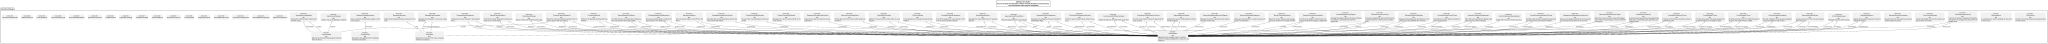

In [ ]:
%viz FunctionsPackage --view tree

### ✅ `TechnicalRequirementsPackage` — `Requirements\TechnicalRequirementsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package TechnicalRequirementsPackage {
	
	private import SI::*;
	private import ISQ::*;
	private import ScalarValues::*;
	private import CoSMAQuantitiesAndUnitsPackage::*;
	private import USCustomaryUnits::*;
	private import ModelingMetadata::*;
    private import CoSMAPackage::*;
    private import FunctionalRequirementsPackage::*;

	requirement def <'CLR-R001'> SICEngineConfiguration {
		doc /* The S-IC stage shall incorporate five F-1 engines. */
		@Rationale {
			text = "This configuration is required to generate the necessary thrust to lift the massive Saturn V vehicle off the launch pad.";
		}
		#refinement dependency SICEngineConfiguration to FunctionalRequirementsPackage::'FLR-R008';
	}

	requirement def <'CLR-R002'> SICPropellantCompatibility {
		doc /* The S-IC stage shall be designed to store and deliver RP-1 (Kerosene) and Liquid Oxygen (LOX) to its engines. */
		@Rationale {
			text = "The choice of the F-1 engine dictates the required propellant types for the first stage.";
		}
		#refinement dependency SICPropellantCompatibility to FunctionalRequirementsPackage::'FLR-R001';
	}
	
	requirement def <'CLR-R003'> SICGimbalCapability {
		doc /* The S-IC stage shall provide a gimbaling mechanism for its engines to enable thrust vector control. */
		@Rationale {
			text = "Gimbaling is the primary means of steering the vehicle during the first stage of ascent, as aerodynamic surfaces are ineffective at low speeds.";
		}
		#refinement dependency SICGimbalCapability to FunctionalRequirementsPackage::'FLR-R013';
	}

	requirement def <'CLR-R026'> SICSeparationSystem {
		doc /* The S-IC stage shall incorporate a pyrotechnic separation system to cleanly detach from the S-II stage. */
		@Rationale {
			text = "A reliable separation system is critical to jettison the massive first stage and allow the second stage to ignite without obstruction.";
		}
		#refinement dependency SICSeparationSystem to FunctionalRequirementsPackage::'FLR-R014';
	}


	requirement def <'CLR-R004'> SIIEngineConfiguration {
		doc /* The S-II stage shall incorporate five J-2 engines. */
		@Rationale {
			text = "This configuration provides the required thrust for second-stage flight in the upper atmosphere and vacuum where efficiency is paramount.";
		}
		#refinement dependency SIIEngineConfiguration to FunctionalRequirementsPackage::'FLR-R010';
	}

	requirement def <'CLR-R005'> SIIPropellantType {
		doc /* The S-II stage shall use Liquid Hydrogen (LH2) and Liquid Oxygen (LOX) propellants. */
		@Rationale {
			text = "The high specific impulse of hydrolox propellant is critical for the efficiency of the upper stages to minimize vehicle mass.";
		}
		#refinement dependency SIIPropellantType to FunctionalRequirementsPackage::'FLR-R001';
	}

	requirement def <'CLR-R027'> SIIStructuralIntegrity {
		doc /* The S-II stage shall maintain structural integrity under the loads of its own thrust and the mass of the upper stages. */
		@Rationale {
			text = "The S-II stage structure must not fail under the combined stresses of acceleration and the weight of the fully fueled third stage and spacecraft.";
		}
		#refinement dependency SIIStructuralIntegrity to FunctionalRequirementsPackage::'FLR-R010';
	}
	


	requirement def <'CLR-R006'> SIVBEngineConfiguration {
		doc /* The S-IVB stage shall incorporate a single J-2 engine. */
		@Rationale {
			text = "A single, highly reliable engine provides the required thrust for both Earth orbit insertion and the subsequent Translunar Injection maneuver.";
		}
		#refinement dependency SIVBEngineConfiguration to FunctionalRequirementsPackage::'FLR-R011';
	}

	requirement def <'CLR-R007'> SIVBRestartCapability {
		doc /* The S-IVB's J-2 engine shall be capable of restarting in a zero-gravity environment. */
		@Rationale {
			text = "Engine restart is a critical capability, as the stage must fire once for orbit insertion and again for the TLI burn hours later.";
		}
		#refinement dependency SIVBRestartCapability to FunctionalRequirementsPackage::'FLR-R019';
	}

	requirement def <'CLR-R028'> SIVBAttitudeControlSystem {
		doc /* The S-IVB stage shall incorporate an attitude control system to maintain stable orientation during coast phases. */
		@Rationale {
			text = "The stage must maintain a correct and stable attitude in orbit to ensure proper thermal conditions and alignment for the TLI burn.";
		}
		#refinement dependency SIVBAttitudeControlSystem to FunctionalRequirementsPackage::'FLR-R020';
	}


	requirement def <'CLR-R008'> IUGuidanceComputer {
		doc /* The SaturnVInstrumentUnit shall house the primary guidance and navigation computer for the launch vehicle. */
		@Rationale {
			text = "A dedicated computer is required to process trajectory data and execute the complex ascent flight plan autonomously.";
		}
		#refinement dependency IUGuidanceComputer to FunctionalRequirementsPackage::'FLR-R013';
	}

	requirement def <'CLR-R009'> IUCommandAuthority {
		doc /* The SaturnVInstrumentUnit shall issue all primary commands for engine ignition, cutoff, and stage separation during ascent. */
		@Rationale {
			text = "A single, authoritative control unit is necessary to ensure precise and synchronized execution of mission-critical events.";
		}
		#refinement dependency IUCommandAuthority to FunctionalRequirementsPackage::'FLR-R014';
	}

	requirement def <'CLR-R029'> IUTelemetrySystem {
		doc /* The SaturnVInstrumentUnit shall gather and transmit vehicle health and status data to ground telemetry systems. */
		@Rationale {
			text = "Real-time data on the launch vehicle's performance is critical for ground controllers to monitor the ascent.";
		}
		#refinement dependency IUTelemetrySystem to FunctionalRequirementsPackage::'FLR-R017';
	}

	
	requirement def <'CLR-R010'> LESPropulsionType {
		doc /* The ApolloLaunchEscapeSystem shall utilize a high-thrust solid rocket motor. */
		@Rationale {
			text = "Solid rockets provide the rapid, high-impulse thrust needed to pull the crew capsule away from a failing launch vehicle with minimal delay.";
		}
		#refinement dependency LESPropulsionType to FunctionalRequirementsPackage::'FLR-R016';
	}

	requirement def <'CLR-R011'> LESJettisonCapability {
		doc /* The ApolloLaunchEscapeSystem shall be capable of being safely jettisoned from the spacecraft after the period of maximum atmospheric stress. */
		@Rationale {
			text = "The LES is dead weight after the initial ascent phase and must be discarded to ensure mission efficiency.";
		}
		#refinement dependency LESJettisonCapability to FunctionalRequirementsPackage::'FLR-R016';
	}


	requirement def <'CLR-R012'> CMHabitableVolume {
		doc /* The ApolloCommandModule shall provide a pressurized, habitable volume for a crew of three. */
		@Rationale {
			text = "The Command Module serves as the primary living and working quarters for the crew for the majority of the mission.";
		}
		#refinement dependency CMHabitableVolume to FunctionalRequirementsPackage::'FLR-R004';
	}
	
	requirement def <'CLR-R013'> CMHeatShield {
		doc /* The ApolloCommandModule shall incorporate a heat shield capable of protecting the crew and structure from the heat of atmospheric reentry. */
		@Rationale {
			text = "Protection from the extreme temperatures of reentry is a fundamental requirement for crew survival.";
		}
		#refinement dependency CMHeatShield to FunctionalRequirementsPackage::'FLR-R080';
	}

	requirement def <'CLR-R014'> CMParachuteSystem {
		doc /* The ApolloCommandModule shall house a system of parachutes to decelerate the vehicle for a safe water landing. */
		@Rationale {
			text = "Aerodynamic decelerators are required to reduce the capsule's velocity to survivable limits for splashdown.";
		}
		#refinement dependency CMParachuteSystem to FunctionalRequirementsPackage::'FLR-R081';
	}
	
	requirement def <'CLR-R030'> CMDockingMechanism {
		doc /* The ApolloCommandModule shall incorporate a probe and drogue docking mechanism. */
		@Rationale {
			text = "A reliable and proven docking mechanism is required to physically connect with the Lunar Module in Earth and Lunar orbit.";
		}
		#refinement dependency CMDockingMechanism to FunctionalRequirementsPackage::'FLR-R023';
	}

	requirement def <'CLR-R052'> GNCGuidancePrecision {
		doc /* The Apollo 11 Mission's guidance system shall calculate mid-course correction burns with a delta-V accuracy of +/- 0.1 meters per second,
			ensuring the trajectory remains within mission-defined corridors. */
		@Rationale {
			text = "Precise calc of trajectory adjustments is vital for minimizing fuel consumption and ensuring the spacecraft stays on the optimal path, supporting mission efficiency and success.";
		}

		attribute actualDeltaVcalcAccuracy :> ISQ::speed;
		attribute maxDeltaVcalcAccuracy :> ISQ::speed = 0.1 [m/s];
		attribute trajectoryWithinCorridor: Boolean;

		require constraint {
			(actualDeltaVcalcAccuracy <= maxDeltaVcalcAccuracy) and
			trajectoryWithinCorridor
		}
		#refinement dependency 'CLR-R052' to FunctionalRequirementsPackage::'FLR-R028';
	}		

	requirement def <'CLR-R053'> RCSControlStability {
		doc /* The Apollo 11 Mission's control system shall maintain spacecraft attitude within +/- 0.5 degrees of commanded orientation
			during orbital and coast phases. */
		@Rationale {
			text = "Stable spacecraft attitude is necessary for accurate navigation, efficient engine burns, proper thermal control, and reliable communication, impacting multiple critical mission functions.";
		}

		attribute actualAttitudeDeviation :> ISQ::angularMeasure;
		attribute maxAttitudeDeviation :> ISQ::angularMeasure = 0.5 ['°'];

		require constraint { actualAttitudeDeviation <= maxAttitudeDeviation }
		#refinement dependency 'CLR-R053' to FunctionalRequirementsPackage::'FLR-R096';
	}
	
	requirement def <'CLR-R054'> LMDSRadarPrecision {
		doc /* The Apollo 11 Mission's lunar lander's navigation system shall provide real-time altitude and velocity data
			with an accuracy of +/- 1 meter for altitude and +/- 0.1 meters per second for velocity during the final 50 meters of powered descent. */
		@Rationale {
			text = "High-fidelity real-time navigation data is critical for the lunar lander's autonomous and manual control during the final, most hazardous, phase of descent, ensuring a safe touchdown.";
		}

		attribute actualAltitudeAccuracy :> ISQ::length;
		attribute maxAltitudeAccuracy :> ISQ::length = 1 [m];

		attribute actualVelocityAccuracy :> ISQ::speed;
		attribute maxVelocityAccuracy :> ISQ::speed = 0.1 [m/s];

		require constraint {
			(actualAltitudeAccuracy <= maxAltitudeAccuracy) and
			(actualVelocityAccuracy <= maxVelocityAccuracy)
		}
		#refinement dependency 'CLR-R054' to FunctionalRequirementsPackage::'FLR-R097';
	}		

	requirement def <'CLR-R015'> SMMainPropulsion {
		doc /* The ApolloServiceModule shall provide a restartable main engine for major in-space maneuvers. */
		@Rationale {
			text = "A high-thrust, reliable main engine is required for critical mission events like Lunar Orbit Insertion and Trans-Earth Injection.";
		}
		#refinement dependency SMMainPropulsion to FunctionalRequirementsPackage::'FLR-R024';
	}
	
	requirement def <'CLR-R016'> SMAttitudeControl {
		doc /* The ApolloServiceModule shall provide a reaction control system for attitude control and minor velocity changes. */
		@Rationale {
			text = "The RCS is essential for orienting the spacecraft for thermal control, communications, and main engine burns.";
		}
		#refinement dependency SMAttitudeControl to FunctionalRequirementsPackage::'FLR-R025';
	}
	
	requirement def <'CLR-R017'> SMPowerGeneration {
		doc /* The ApolloServiceModule shall house fuel cells to generate the primary electrical power for the Command/Service Module. */
		@Rationale {
			text = "A continuous and reliable source of electrical power is required to operate all onboard systems, including life support.";
		}
		#refinement dependency SMPowerGeneration to FunctionalRequirementsPackage::'FLR-R030';
	}

	requirement def <'CLR-R031'> SMThermalControlSystem {
		doc /* The ApolloServiceModule shall incorporate radiators to reject waste heat from the spacecraft into space. */
		@Rationale {
			text = "An active thermal control system is necessary to prevent onboard systems and the crew cabin from overheating.";
		}
		#refinement dependency SMThermalControlSystem to FunctionalRequirementsPackage::'FLR-R031';
	}

	requirement def <'CLR-R051'> CabinEnvironmentalControlRequirement {
		doc /* The Apollo 11 Mission's spacecraft environmental control system shall maintain cabin temperature between 20°C and 25°C
			and oxygen partial pressure between 2.5 pounds per square inch and 4.0 pounds per square inch for all 8 days of the mission, for a crew of three. */
		@Rationale {
			text = "Maintaining a stable and safe cabin environment is crucial for astronaut health, comfort, and performance throughout the mission duration, directly supporting the 'Go to Moon' goal and human safety.";
		}

		attribute actualCabinTemperatureMin :> ISQ::thermodynamicTemperature;
		attribute actualCabinTemperatureMax :> ISQ::thermodynamicTemperature;
		attribute minCabinTemperatureReqd :> ISQ::thermodynamicTemperature = 20 ['°C'];
		attribute maxCabinTemperatureReqd :> ISQ::thermodynamicTemperature = 25 ['°C'];

		attribute actualOxygenPressureMin :> ISQ::pressure;
		attribute actualOxygenPressureMax :> ISQ::pressure;
		attribute minOxygenPressureReqd :> ISQ::pressure = 2.5 ['pound-force per square inch (psi)'];
		attribute maxOxygenPressureReqd :> ISQ::pressure = 4.0 ['pound-force per square inch (psi)'];

		attribute missionDuration :> ISQ::time;

		require constraint {
			(actualCabinTemperatureMin >= minCabinTemperatureReqd) and
			(actualCabinTemperatureMax <= maxCabinTemperatureReqd) and
			(actualOxygenPressureMin >= minOxygenPressureReqd) and
			(actualOxygenPressureMax <= maxOxygenPressureReqd)
		}
		#refinement dependency 'CLR-R051' to FunctionalRequirementsPackage::'FLR-R102';
	}			


	requirement def <'CLR-R018'> LMDSThrottleableEngine {
		doc /* The LunarModuleDescentStage shall provide a main engine with a throttleable thrust range. */
		@Rationale {
			text = "A variable thrust is essential for the powered descent, allowing the crew to precisely control the rate of descent for a soft landing.";
		}
		#refinement dependency LMDSThrottleableEngine to FunctionalRequirementsPackage::'FLR-R046';
	}
	
	requirement def <'CLR-R019'> LMDSLandingGear {
		doc /* The LunarModuleDescentStage shall incorporate a landing gear system capable of absorbing the energy of a lunar touchdown. */
		@Rationale {
			text = "The landing gear must prevent structural damage to the lander and protect the crew from the forces of the final landing impact.";
		}
		#refinement dependency LMDSLandingGear to FunctionalRequirementsPackage::'FLR-R002';
	}

	requirement def <'CLR-R032'> LMDSLaunchPlatform {
		doc /* The LunarModuleDescentStage shall provide a stable, structurally sound platform for the ascent stage to launch from. */
		@Rationale {
			text = "The descent stage must serve as a one-time launch pad on the Moon, withstanding the forces of the ascent engine ignition.";
		}
		#refinement dependency LMDSLaunchPlatform to FunctionalRequirementsPackage::'FLR-R065';
	}
	
	requirement def <'CLR-R050'> LMDSVelocityLimits {
		doc /* The LunarModuleDescentStage shall command thrust to ensure that at the moment of footpad touchdown, the vehicle's velocities do not exceed the following limits:
			* Vertical Velocity: <= 3.05 meters per second (10 feet per second)
			* Horizontal Velocity: <= 1.22 meters per second (4 feet per second)
			*/
		@Rationale {
			text = "These limits prevent structural damage to the ascent stage interface or a post-impact tip-over of the LM.";
		}
		#refinement dependency LMDSVelocityLimits to FunctionalRequirementsPackage::'FLR-R082';
	}		

	requirement def <'CLR-R020'> LMASAscentEngine {
		doc /* The LunarModuleAscentStage shall provide a fixed-thrust engine capable of lifting the stage from the lunar surface into orbit. */
		@Rationale {
			text = "A highly reliable, non-throttleable engine provides the simplest and most robust means of achieving lunar orbit for rendezvous.";
		}
		#refinement dependency LMASAscentEngine to FunctionalRequirementsPackage::'FLR-R066';
	}
	
	requirement def <'CLR-R021'> LMASCrewCabin {
		doc /* The LunarModuleAscentStage shall provide a pressurized cabin for a crew of two. */
		@Rationale {
			text = "The ascent stage serves as the flight deck and habitat for the crew during lunar orbit and surface operations.";
		}
		#refinement dependency LMASCrewCabin to FunctionalRequirementsPackage::'FLR-R062';
	}

	requirement def <'CLR-R033'> LMASRendezvousRadar {
		doc /* The LunarModuleAscentStage shall incorporate a radar system to track the Command Module during rendezvous. */
		@Rationale {
			text = "An independent tracking capability is required for the LM to compute its trajectory relative to the CSM for a successful rendezvous.";
		}
		#refinement dependency LMASRendezvousRadar to FunctionalRequirementsPackage::'FLR-R067';
	}

	requirement def <'CLR-R022'> PSAPressureContainment {
		doc /* The PressureSuiteAssembly shall maintain a positive internal pressure environment for the astronaut. */
		@Rationale {
			text = "Maintaining pressure is the most fundamental requirement for keeping an astronaut alive in the vacuum of space.";
		}
		#refinement dependency PSAPressureContainment to FunctionalRequirementsPackage::'FLR-R053';
	}
	
	requirement def <'CLR-R023'> PSAMobility {
		doc /* The PressureSuiteAssembly shall allow sufficient mobility for the crew to perform required EVA tasks. */
		@Rationale {
			text = "The suit must not be so rigid that it prevents the crew from walking, bending, and using tools effectively.";
		}
		#refinement dependency PSAMobility to FunctionalRequirementsPackage::'FLR-R055';
	}

	requirement def <'CLR-R034'> PSAHelmetVisibility {
		doc /* The PressureSuiteAssembly shall provide a helmet with a wide, unobstructed field of view and protective visors. */
		@Rationale {
			text = "Clear and wide visibility is essential for navigation, task performance, and hazard identification on the lunar surface.";
		}
		#refinement dependency PSAHelmetVisibility to FunctionalRequirementsPackage::'FLR-R055';
	}

	requirement def <'CLR-R024'> PLSSOxygenSupply {
		doc /* The PortableLifeSupportSystem shall contain and supply breathable oxygen to the crew member. */
		@Rationale {
			text = "A finite supply of oxygen is required for the duration of the extravehicular activity.";
		}
		#refinement dependency PLSSOxygenSupply to FunctionalRequirementsPackage::'FLR-R054';
	}
	
	requirement def <'CLR-R025'> PLSSContaminantRemoval {
		doc /* The PortableLifeSupportSystem shall remove carbon dioxide and other contaminants from the suit's atmosphere. */
		@Rationale {
			text = "Recirculating the suit's atmosphere requires the continuous removal of harmful metabolic byproducts like CO2.";
		}
		#refinement dependency PLSSContaminantRemoval to FunctionalRequirementsPackage::'FLR-R053';
	}

	requirement def <'CLR-R035'> PLSSCoolingSystem {
		doc /* The PortableLifeSupportSystem shall circulate cooling fluid to regulate astronaut body temperature. */
		@Rationale {
			text = "An active cooling system is required to remove excess body heat and prevent overheating during strenuous activity in the suit.";
		}
		#refinement dependency PLSSCoolingSystem to FunctionalRequirementsPackage::'FLR-R053';
	}

	requirement def <'CLR-R036'> StagingInterfaceLoadTransfer {
		doc /* The StagingInterface shall be capable of transferring all structural loads from the upper stage to the lower stage during powered ascent. */
		@Rationale {
			text = "Failure to transfer loads would result in catastrophic structural failure of the launch vehicle.";
		}
		#refinement dependency StagingInterfaceLoadTransfer to FunctionalRequirementsPackage::'FLR-R008';
	}

	requirement def <'CLR-R037'> StagingInterfaceCleanSeparation {
		doc /* The StagingInterface shall ensure a clean separation with no re-contact between stages upon receiving a valid separation command. */
		@Rationale {
			text = "Re-contact or debris could damage the upper stage engine, preventing ignition and causing mission failure.";
		}
		#refinement dependency StagingInterfaceCleanSeparation to FunctionalRequirementsPackage::'FLR-R014';
	}

	requirement def <'CLR-R038'> GuidanceInterfaceCommandIntegrity {
		doc /* The GuidanceInterface shall transmit control commands with a data integrity of 99.999% or greater. */
		@Rationale {
			text = "Corrupted guidance commands could lead to loss of vehicle control.";
		}
		#refinement dependency GuidanceInterfaceCommandIntegrity to FunctionalRequirementsPackage::'FLR-R013';
	}

	requirement def <'CLR-R039'> GuidanceInterfaceTelemetryLatency {
		doc /* The GuidanceInterface shall provide real-time telemetry from the stage to the controller with a latency of less than 10 milliseconds. */
		@Rationale {
			text = "Low latency is critical for the guidance computer to make timely adjustments to the vehicle's trajectory.";
		}
		#refinement dependency GuidanceInterfaceTelemetryLatency to FunctionalRequirementsPackage::'FLR-R017';
	}

	requirement def <'CLR-R040'> CSMInterfacePowerTransfer {
		doc /* The CSMInterface shall transfer electrical power from the supplier to the consumer with a voltage drop of less than 2%. */
		@Rationale {
			text = "Efficient power transfer is necessary to ensure all Command Module systems are adequately powered.";
		}
		#refinement dependency CSMInterfacePowerTransfer to FunctionalRequirementsPackage::'FLR-R030';
	}

	requirement def <'CLR-R041'> CSMInterfaceLifeSupportIntegrity {
		doc /* The CSMInterface shall transport life support consumables with zero leakage. */
		@Rationale {
			text = "Any leakage of oxygen or water would be a critical, life-threatening failure.";
		}
		#refinement dependency CSMInterfaceLifeSupportIntegrity to FunctionalRequirementsPackage::'FLR-R025';
	}
	
	requirement def <'CLR-R042'> DockingInterfaceStructuralRigidity {
		doc /* The DockingInterface shall form a rigid structural connection capable of withstanding attitude control maneuvers. */
		@Rationale {
			text = "The two docked spacecraft must behave as a single, rigid body to ensure stable flight control.";
		}
		#refinement dependency DockingInterfaceStructuralRigidity to FunctionalRequirementsPackage::'FLR-R023';
	}

	requirement def <'CLR-R043'> DockingInterfacePressurizedSeal {
		doc /* The DockingInterface shall create a pressurized seal between the two vehicle cabins. */
		@Rationale {
			text = "A secure, pressurized tunnel is required to allow for the safe transfer of crew members between vehicles without spacesuits.";
		}
		#refinement dependency DockingInterfacePressurizedSeal to FunctionalRequirementsPackage::'FLR-R071';
	}

	requirement def <'CLR-R044'> LMStagingInterfaceSeparation {
		doc /* The LMStagingInterface shall execute a clean pyrotechnic separation of the Ascent Stage from the Descent Stage. */
		@Rationale {
			text = "A reliable separation is critical for the Ascent Stage to lift off from the lunar surface unimpeded.";
		}
		#refinement dependency LMStagingInterfaceSeparation to FunctionalRequirementsPackage::'FLR-R065';
	}

	requirement def <'CLR-R045'> EVAInterfaceSecureConnection {
		doc /* The EVAInterface shall provide secure, quick-disconnect fittings for all fluid and data connections. */
		@Rationale {
			text = "Connections must be reliable and easy for a gloved astronaut to operate, while preventing accidental disconnection during an EVA.";
		}
		#refinement dependency EVAInterfaceSecureConnection to FunctionalRequirementsPackage::'FLR-R053';
	}
	
	requirement def <'CLR-R046'> LVPayloadInterfaceStructural {
		doc /* The interface between the SaturnVInstrumentUnit and the ApolloSpacecraftLMAdapter shall withstand all structural loads during launch and ascent. */
		@Rationale {
			text = "This interface bears the entire mechanical load of the 45-ton Apollo spacecraft stack during its most violent flight phase.";
		}
		#refinement dependency LVPayloadInterfaceStructural to FunctionalRequirementsPackage::'FLR-R008';
	}
	
	requirement def <'CLR-R047'> SLALMDeployment {
		doc /* The ApolloSpacecraftLMAdapter shall deploy the Lunar Module upon command with sufficient force to prevent re-contact. */
		@Rationale {
			text = "A successful and clean deployment of the LM after transposition and docking is critical to beginning the lunar phase of the mission.";
		}
		#refinement dependency SLALMDeployment to FunctionalRequirementsPackage::'FLR-R022';
	}
	
	requirement def <'CLR-R048'> LESInterfaceStructuralIntegrity {
		doc /* The interface between the ApolloCommandModule and the ApolloLaunchEscapeSystem shall maintain structural integrity under all launch and ascent aerodynamic loads. */
		@Rationale {
			text = "A structural failure of this interface could cause the LES to detach prematurely, endangering the crew and the mission.";
		}
		#refinement dependency LESInterfaceStructuralIntegrity to FunctionalRequirementsPackage::'FLR-R016';
	}
	
	requirement def <'CLR-R049'> LESInterfaceCommandReliability {
		doc /* The interface between the ApolloCommandModule and the ApolloLaunchEscapeSystem shall reliably transmit abort and jettison commands to the LES motors. */
		@Rationale {
			text = "The failure to transmit an abort command in an emergency would be catastrophic. The failure to jettison the LES would prevent mission continuation.";
		}
		#refinement dependency LESInterfaceCommandReliability to FunctionalRequirementsPackage::'FLR-R016';
	}	

	requirement def <'CLR-R055'> SICThrustMagnitude {
		doc /* The Apollo 11 Mission's launch vehicle's first stage propulsion shall provide a minimum thrust of 34.5 Meganewtons at liftoff. */
		@Rationale {
			text = "Sufficient thrust from the first stage is fundamental to overcome Earth's gravity and initiate the launch sequence, enabling the entire mission.";
		}

		attribute actualLiftoffThrust :> ISQ::force;
		attribute minLiftoffThrust :> ISQ::force = 34.5 [MN];

		require constraint { actualLiftoffThrust >= minLiftoffThrust }
	
	}

	requirement def <'CLR-R056'> SPSIgnitionReliability {
		doc /* The Apollo 11 Mission's in-space propulsion system shall be capable of performing at least 3 full-duration major burns
			(e.g., Lunar Orbit Insertion, Trans-Earth Injection) with a 99.8% ignition success rate for each burn. */
		@Rationale {
			text = "The reliability of in-space propulsion is paramount for achieving and departing lunar orbit, directly impacting mission success and crew safety; failure means being stranded.";
		}

		attribute actualMajorBurnCount: Integer;
		attribute minMajorBurnCount: Integer = 3;

		attribute actualIgnitionSuccessRate: RatioValue;
		attribute minIgnitionSuccessRate: RatioValue = 99.8['%'];

		require constraint {
			(actualMajorBurnCount >= minMajorBurnCount) and
			(actualIgnitionSuccessRate >= minIgnitionSuccessRate)
		}
		#refinement dependency 'CLR-R056' to FunctionalRequirementsPackage::'FLR-R024';
	}

	requirement def <'CLR-R057'> DPSThrottlingRange {
		doc /* The Apollo 11 Mission's lunar lander's descent propulsion system shall provide throttleable thrust
			from 10% to 100% of maximum thrust to enable precise lunar landing control. */
		@Rationale {
			text = "Throttling capability provides the fine control necessary to manage descent rate and fuel consumption during the lunar landing, crucial for achieving a soft and controlled touchdown.";
		}

		attribute actualMinThrottlePercentage: RatioValue;
		attribute minRequiredThrottlePercentage: RatioValue = 10['%'];

		attribute actualMaxThrottlePercentage: RatioValue;
		attribute maxRequiredThrottlePercentage: RatioValue = 100['%'];

		require constraint {
			(actualMinThrottlePercentage <= minRequiredThrottlePercentage) and
			(actualMaxThrottlePercentage >= maxRequiredThrottlePercentage)
		}
		#refinement dependency 'CLR-R057' to FunctionalRequirementsPackage::'FLR-R099';
	}

	requirement def <'CLR-R058'> LMASBurnDuration {
		doc /* The Apollo 11 Mission's lunar lander's ascent propulsion system shall achieve a burn duration of <= 400 seconds
			to insert the ascent stage into lunar orbit. */
		@Rationale {
			text = "A specific burn duration is required to ensure the ascent stage achieves the correct lunar orbit for rendezvous, directly enabling the crew's return to the Command Module.";
		}

		attribute actualAscentBurnDuration :> ISQ::time;
		attribute maxAscentBurnDuration :> ISQ::time = 400 [s];

		require constraint { actualAscentBurnDuration <= maxAscentBurnDuration }
		#refinement dependency 'CLR-R058' to FunctionalRequirementsPackage::'FLR-R066';
	}

	requirement def <'CLR-R059'> PrimaryStructureLoadLimit {
		doc /* All primary structural elements of the Apollo 11 Mission launch system shall withstand launch loads of up to 4 gees
			without permanent deformation or failure. */
		@Rationale {
			text = "Structural integrity during the high-stress launch phase is absolutely essential to prevent catastrophic failure and ensure the vehicle and crew reach orbit safely.";
		}

		attribute actualMaxLaunchLoadWithstood :> ISQ::acceleration;
		attribute requiredMaxLaunchLoadWithstood :> ISQ::acceleration = 4 [gn];

		attribute permanentDeformationObserved: Boolean;
		attribute structuralFailureObserved: Boolean;

		require constraint {
			(actualMaxLaunchLoadWithstood >= requiredMaxLaunchLoadWithstood) and
			not permanentDeformationObserved and
			not structuralFailureObserved
		}
	}

	requirement def <'CLR-R060'> CMHeatShieldThermalPerf {
		doc /* The Apollo 11 Mission's crew vehicle heat shield shall ablate as designed and limit internal crew compartment
			temperature rise to less than 5°C during atmospheric re-entry. */
		@Rationale {
			text = "The heat shield is critical for crew survival during re-entry by protecting against extreme temperatures, directly addressing human safety.";
		}

		attribute actualInternalTemperatureRise :> ISQ::thermodynamicTemperature;
		attribute maxInternalTemperatureRise :> ISQ::thermodynamicTemperature = 5 ['°C'];

		attribute heatShieldAblationAsDesigned: Boolean;

		require constraint {
			(actualInternalTemperatureRise < maxInternalTemperatureRise) and
			heatShieldAblationAsDesigned
		}
		#refinement dependency 'CLR-R060' to FunctionalRequirementsPackage::'FLR-R100';
	}

	requirement def <'CLR-R061'> PyrotechnicInitiationReliability {
		doc /* All pyrotechnic devices (e.g., stage separation, parachute deployment) used in the Apollo 11 Mission
			shall have a 99.99% initiation reliability. */
		@Rationale {
			text = "Highly reliable pyrotechnic devices are crucial for sequential mission events like stage separations and parachute deployment, as failures in these systems could lead to catastrophic mission loss or crew fatalities.";
		}

		attribute actualInitiationReliability: RatioValue;
		attribute minInitiationReliability: RatioValue = 99.99['%'];

		require constraint { actualInitiationReliability >= minInitiationReliability }
	}

	requirement def <'CLR-R062'> DockingMechanismReliability {
		doc /* The Apollo 11 Mission's spacecraft docking system shall enable two spacecraft to mate and form a rigid connection
			in lunar orbit, capable of withstanding dynamic loads during rendezvous maneuvers,
			with a 99.5% success rate for capture and latching. */
		@Rationale {
			text = "Reliable docking is essential for transferring crew and samples, making it a critical path to crew return and scientific goals. Failure would mean being stranded in lunar orbit.";
		}

		attribute actualCaptureLatchingSuccessRate: RatioValue;
		attribute minCaptureLatchingSuccessRate: RatioValue = 99.5['%'];

		attribute connectionRigidityMaintained: Boolean;
		attribute withstandsDynamicLoads: Boolean;

		require constraint {
			(actualCaptureLatchingSuccessRate >= minCaptureLatchingSuccessRate) and
			connectionRigidityMaintained and
			withstandsDynamicLoads
		}
	}

	requirement def <'CLR-R063'> LMDSLandingGearEnergy {
		doc /* The Apollo 11 Mission's lunar lander's landing gear shall absorb impact energy equivalent to a 3 meters per second vertical velocity
			and 1 meter per second horizontal velocity at touchdown without structural failure. */
		@Rationale {
			text = "The landing gear must reliably absorb the forces of lunar touchdown to protect the lander structure, its internal systems, and the crew.";
		}

		attribute maxImpactVerticalVelocityAbsorbed :> ISQ::speed;
		attribute minImpactVerticalVelocityRequired :> ISQ::speed = 3 [m/s];

		attribute maxImpactHorizontalVelocityAbsorbed :> ISQ::speed;
		attribute minImpactHorizontalVelocityRequired :> ISQ::speed = 1 [m/s];

		attribute structuralFailureOccurred: Boolean;

		require constraint {
			(maxImpactVerticalVelocityAbsorbed >= minImpactVerticalVelocityRequired) and
			(maxImpactHorizontalVelocityAbsorbed >= minImpactHorizontalVelocityRequired) and
			not structuralFailureOccurred
		}
	}

	requirement def <'CLR-R064'> ECSWaterSupplyRate {
		doc /* The Apollo 11 Mission's crew's potable water system shall provide a minimum of 2 kilograms of potable water per crew member per day. */
		@Rationale {
			text = "Adequate potable water is a fundamental requirement for sustaining crew health and life throughout the mission.";
		}

		attribute actualWaterProvidedPerCrewPerDay :> ISQ::mass;
		attribute minWaterRequiredPerCrewPerDay :> ISQ::mass = 2 [kg];

		require constraint { actualWaterProvidedPerCrewPerDay >= minWaterRequiredPerCrewPerDay }
	}

	requirement def <'CLR-R065'> ECSFilterEfficiency {
		doc /* The Apollo 11 Mission's cabin atmosphere purification system shall maintain carbon dioxide levels below 0.5% by volume
			and remove particulate matter >= 0.5 microns with 99% efficiency. */
		@Rationale {
			text = "Maintaining breathable air free of harmful contaminants is a continuous and critical life support function, directly impacting crew health and safety.";
		}

		attribute actualCO2LevelMax: RatioValue;
		attribute maxCO2LevelReqd: RatioValue = 0.5['%'];

		attribute actualParticulateRemovalEfficiency: RatioValue;
		attribute minParticulateRemovalEfficiency: RatioValue = 99['%'];

		require constraint {
			(actualCO2LevelMax <= maxCO2LevelReqd) and
			(actualParticulateRemovalEfficiency >= minParticulateRemovalEfficiency)
		}
	}

		requirement def <'CLR-R066'> DataHandlingIntegrity {
		doc /* The Apollo 11 Mission's data acquisition system shall record and store all critical telemetry data for the entire mission duration,
			with no less than 99.9% data integrity. */
		@Rationale {
			text = "High data integrity ensures that ground control has accurate information for real-time decision-making, post-flight analysis, and mission lessons learned.";
		}

		attribute actualDataIntegrityPercentage: RatioValue;
		attribute minDataIntegrityPercentage: RatioValue = 99.9['%'];

		require constraint { actualDataIntegrityPercentage >= minDataIntegrityPercentage }
	}

	requirement def <'CLR-R067'> CommVideoBandwidth {
		doc /* The Apollo 11 Mission spacecraft shall be capable of transmitting live video from the lunar surface to Earth
			with a resolution of at least 320x240 pixels and a frame rate of >= 10 frames per second. */
		@Rationale {
			text = "Live video transmission from the lunar surface significantly enhances public engagement and inspiration, and provides valuable real-time visual context for mission operations.";
		}

		attribute actualVideoWidth: Integer;
		attribute minVideoWidth: Integer = 320;

		attribute actualVideoHeight: Integer;
		attribute minVideoHeight: Integer = 240;

		attribute actualFrameRate :> ISQ::frequency;
		attribute minFrameRate :> ISQ::frequency = 10 ['fps'];

		require constraint {
			(actualVideoWidth >= minVideoWidth) and
			(actualVideoHeight >= minVideoHeight) and
			(actualFrameRate >= minFrameRate)
		}
		#refinement dependency 'CLR-R067' to FunctionalRequirementsPackage::'FLR-R103';
	}

	requirement def <'CLR-R068'> EMUPressureContainment {
		doc /* The Apollo 11 Mission's Extravehicular Mobility Unit shall maintain internal pressure at 25.5 kilopascals with no more than 5% pressure loss per hour during Extravehicular Activity. */
		@Rationale {
			text = "Maintaining internal pressure in the Extravehicular Mobility Unit is critical for astronaut safety and performance during Extravehicular Activity in the vacuum of space.";
		}

		attribute actualEMUInternalPressure :> ISQ::pressure;
		attribute nominalEMUInternalPressure :> ISQ::pressure = 25.5 ['kPa'];

		attribute actualPressureLossRate: RatioValue;
		attribute maxPressureLossRate: RatioValue = 5['%'];

		require constraint {
			(actualPressureLossRate <= maxPressureLossRate)
		}
		#refinement dependency 'CLR-R068' to FunctionalRequirementsPackage::'FLR-R104';
	}

	requirement def <'CLR-R069'> EASEPOperationalDuration {
		doc /* The Apollo 11 Mission's deployed scientific instruments shall be operational for a minimum of 30 days post-deployment
			and transmit at least 100 Kilobytes of scientific data per day for this period. */
		@Rationale {
			text = "Ensuring long-term operation and sufficient data transmission from deployed instruments maximizes the scientific return and provides continuous monitoring of the lunar environment.";
		}

		attribute actualOperationalDuration :> ISQ::time;
		attribute minOperationalDuration :> ISQ::time = 30['d'];

		attribute actualDailyDataTransmission :> ISQ::storageCapacity;
		attribute minDailyDataTransmission :> ISQ::storageCapacity = 100 ['kB'];

		require constraint {
			(actualOperationalDuration >= minOperationalDuration) and
			(actualDailyDataTransmission >= minDailyDataTransmission)
		}
		#refinement dependency 'CLR-R069' to FunctionalRequirementsPackage::'FLR-R059';
	}

	requirement def <'CLR-R070'> MissionSystemReliability {
		doc /* All mission-critical flight systems of the Apollo 11 Mission (e.g., primary propulsion, life support, main computer)
			shall demonstrate a statistical reliability of >= 0.999 (three nines) for their operational lifetimes. */
		@Rationale {
			text = "Extremely high reliability for critical systems is foundational to ensuring mission success and astronaut safety, given the inherent risks and remote operating environment.";
		}

		attribute actualSystemReliability: Real;
		attribute minRequiredReliability: Real = 0.999;

		require constraint { actualSystemReliability >= minRequiredReliability }
	}

	requirement def <'CLR-R071'> FlightSoftwareDefectRate {
		doc /* The Apollo 11 Mission's flight software for primary guidance and control shall have zero critical defects (Severity 1 or 2)
			identified during a minimum of 2,000 hours of integrated hardware-in-the-loop simulation prior to flight. */
		@Rationale {
			text = "Zero critical software defects are essential for autonomous and commanded operations, as software failures could directly jeopardize mission success and crew safety.";
		}

		attribute actualCriticalDefectsCount: Integer;
		attribute maxCriticalDefectsAllowed: Integer = 0;

		attribute actualSimulationHours :> ISQ::time;
		attribute minSimulationHoursRequired :> ISQ::time = 2000 [h];

		require constraint {
			(actualCriticalDefectsCount <= maxCriticalDefectsAllowed) and
			(actualSimulationHours >= minSimulationHoursRequired)
		}
		#refinement dependency 'CLR-R071' to FunctionalRequirementsPackage::'FLR-R105';
	}

	requirement def <'CLR-R072'> ComponentAcceptanceRate {
		doc /* All flight components of the Apollo 11 Mission shall undergo acceptance testing to verify conformance to specifications
			before integration, with <= 0.1% non-conformance rate. */
		@Rationale {
			text = "Rigorous acceptance testing ensures that only compliant and reliable components are integrated into the flight system, minimizing risks from faulty parts.";
		}

		attribute actualNonConformanceRate: RatioValue;
		attribute maxNonConformanceRate: RatioValue = 0.1['%'];

		require constraint { actualNonConformanceRate <= maxNonConformanceRate }
	}			
	
	requirement def <'CLR-R073'> MaterialVacuumResistance {
		doc /* All spacecraft materials of the Apollo 11 Mission shall withstand long-term exposure to the space environment
			(vacuum, radiation, thermal cycling) for up to 14 days without critical degradation of structural integrity
			or functional performance. */
		@Rationale {
			text = "Material robustness in the extreme space environment is fundamental to ensuring the long-term integrity and functionality of the spacecraft, directly impacting mission safety and success.";
		}

		attribute actualDegradationLevel: RatioValue; // e.g., % loss of strength/performance (0-100)
		attribute maxDegradationLevel: RatioValue = 0['%']; // 'without critical degradation'

		attribute actualExposureDuration :> ISQ::time;
		attribute minExposureDurationReqd :> ISQ::time = 14 [d];

		require constraint {
			(actualDegradationLevel <= maxDegradationLevel) and
			(actualExposureDuration >= minExposureDurationReqd)
		}
		#refinement dependency 'CLR-R073' to FunctionalRequirementsPackage::'FLR-R106';
	}

	requirement def <'CLR-R074'> ElectronicEMIImmunity {
		doc /* The entire Apollo 11 Mission system shall be designed to withstand the electromagnetic interference (EMI) environment
			of launch and space operations without functional degradation. */
		@Rationale {
			text = "Immunity to electromagnetic interference ensures that all electronic systems operate reliably without disruption from internal or external electromagnetic noise, vital for mission control and safety.";
		}

		attribute functionalDegradationFromEMI: Boolean;

		require constraint { not functionalDegradationFromEMI }
	}	

	requirement def <'CLR-R075'> ImageResolutionStandard {
		doc /* The visual data capture system shall provide a minimum resolution of 2k for still images 
			and 16mm equivalent for motion film. */
		@Rationale {
			text = "High-resolution imagery is necessary to meet scientific documentation and public prestige goals.";
		}
		#refinement dependency 'CLR-R075' to FunctionalRequirementsPackage::'FLR-R107';
	}

	requirement def <'CLR-R076'> WasteStorageVolume {
		doc /* The waste containment system shall provide a minimum of 0.5 cubic feet of sealed storage 
			per crew member for an 8-day mission. */
		@Rationale {
			text = "Prevents cabin contamination and maintains crew hygiene during flight.";
		}
		#refinement dependency 'CLR-R076' to FunctionalRequirementsPackage::'FLR-R108';
	}

	requirement def <'CLR-R077'> VHFAudioBandwidth {
		doc /* The cross-vehicle audio link shall operate within the 250-300 MHz range with a signal-to-noise 
			ratio of at least 20dB. */
		@Rationale {
			text = "Ensures clear voice coordination between the LM and CSM during critical lunar operations.";
		}
		#refinement dependency 'CLR-R077' to FunctionalRequirementsPackage::'FLR-R109';
	}

	requirement def <'CLR-R078'> SystemRedundancyMapping {
		doc /* All Level-1 critical electronic components shall be duplicated in an 'A' and 'B' bus 
			configuration with automatic failover. */
		@Rationale {
			text = "Implements the fault tolerance required to prevent mission loss from a single component failure.";
		}
		#refinement dependency 'CLR-R078' to FunctionalRequirementsPackage::'FLR-R110';
	}

	requirement def <'CLR-R079'> MedicalKitSpecification {
		doc /* The onboard medical kit shall contain antibiotics, analgesics, and minor surgical tools 
			certified for use in zero-gravity. */
		@Rationale {
			text = "Enables the crew to manage health incidents without immediate Earth-based assistance.";
		}
		#refinement dependency 'CLR-R079' to FunctionalRequirementsPackage::'FLR-R111';
	}

	requirement def <'CLR-R080'> GroundArchivalProtocol {
		doc /* Mission telemetry shall be recorded on magnetic tape at three geographically distinct 
			sites with 99.9% data parity. */
		@Rationale {
			text = "Ensures long-term preservation of mission data for future scientific analysis.";
		}
		#refinement dependency 'CLR-R080' to FunctionalRequirementsPackage::'FLR-R112';
	}	

	requirement def <'CLR-R081'> CrewSeatLoadFactor {
            doc /* The crew seating system shall attenuate peak launch acceleration to ensure loads 
                   experienced by the crew do not exceed 6g. */
            @Rationale {
                text = "Ensures crew safety during the high-stress launch phase.";
            }
            #refinement dependency 'CLR-R081' to FunctionalRequirementsPackage::'FLR-R003';
        }

	requirement def <'CLR-R082'> LaunchAbortThresholds {
		doc /* The Instrument Unit shall trigger an automatic abort if the vehicle attitude deviation 
				exceeds 5 degrees or if tank pressure drops below 90% of nominal. */
		@Rationale {
			text = "Ensures a safe abort sequence if critical limits are violated.";
		}
		#refinement dependency 'CLR-R082' to FunctionalRequirementsPackage::'FLR-R006';
	}

	requirement def <'CLR-R083'> SeparationTimerPrecision {
		doc /* Pyrotechnic separation events shall be triggered within 50 milliseconds of the 
				command issue to prevent re-contact. */
		@Rationale {
			text = "Ensures clean separation of stages and modules.";
		}
		#refinement dependency 'CLR-R083' to FunctionalRequirementsPackage::'FLR-R014';
	}	

	requirement def <'CLR-R084'> CabinPressureHold {
		doc /* The crew cabin shall maintain a pressure leak rate of less than 0.1 psi per hour at a nominal pressure of 5.0 psi. */
		@Rationale {
			text = "Defines the boundary for cabin integrity for crew survival in vacuum.";
		}
		#refinement dependency 'CLR-R084' to FunctionalRequirementsPackage::'FLR-R004';
	}

	requirement def <'CLR-R085'> TimingSynchError {
		doc /* The master mission clock system shall maintain synchronization across all segments with a drift of less than 1ms per 24 hours. */
		@Rationale {
			text = "Precise timing is required to synchronize thousands of events across ground and flight segments.";
		}
		#refinement dependency 'CLR-R085' to FunctionalRequirementsPackage::'FLR-R005';
	}

	requirement def <'CLR-R086'> EngineStartLatency {
		doc /* The S-IC engine ignition sequence shall complete within 150ms of the authenticated launch command. */
		@Rationale {
			text = "Timely ignition is critical to meet the planetary launch window and intended trajectory.";
		}
		#refinement dependency 'CLR-R086' to FunctionalRequirementsPackage::'FLR-R007';
	}

	requirement def <'CLR-R087'> StagingShockLimit {
		doc /* Separation pyrotechnics shall not exceed a peak shock load of 50g on adjacent structural interfaces. */
		@Rationale {
			text = "Limits mechanical stress on the second stage to prevent damage during first-stage jettison.";
		}
		#refinement dependency 'CLR-R087' to FunctionalRequirementsPackage::'FLR-R009';
	}

	requirement def <'CLR-R088'> CutoffDeltaVError {
		doc /* Residual thrust from the S-IVB engine post-cutoff shall not exceed 0.05 m/s. */
		@Rationale {
			text = "Precise termination of thrust is necessary to achieve stable Earth orbit insertion.";
		}
		#refinement dependency 'CLR-R088' to FunctionalRequirementsPackage::'FLR-R012';
	}

	requirement def <'CLR-R089'> CockpitDisplayRefresh {
		doc /* Mission-critical flight displays in the CM cockpit shall have a minimum data refresh rate of 2 Hz. */
		@Rationale {
			text = "Provides the crew with real-time situational awareness for manual intervention or aborts.";
		}
		#refinement dependency 'CLR-R089' to FunctionalRequirementsPackage::'FLR-R015';
	}

	requirement def <'CLR-R090'> TelemetrySamplingRate {
		doc /* High-rate telemetry channels for engine health shall be sampled at a minimum of 100 samples per second. */
		@Rationale {
			text = "High-fidelity data is needed for ground-based automated verification of propulsion health.";
		}
		#refinement dependency 'CLR-R090' to FunctionalRequirementsPackage::'FLR-R018';
	}

	requirement def <'CLR-R091'> PostTliSeparationVelocity {
		doc /* The S-IVB auxiliary propulsion system shall provide a minimum delta-V of 1.0 m/s for post-TLI separation. */
		@Rationale {
			text = "Ensures the spent third stage moves away from the spacecraft to prevent re-contact.";
		}
		#refinement dependency 'CLR-R091' to FunctionalRequirementsPackage::'FLR-R019';
	}

	requirement def <'CLR-R092'> SlaSeparationVelocity {
		doc /* The SLA separation springs shall provide a minimum separation velocity of 0.3 meters per second. */
		@Rationale {
			text = "Mechanical force is required to move the spacecraft away from the adapter for transposition.";
		}
		#refinement dependency 'CLR-R092' to FunctionalRequirementsPackage::'FLR-R021';
	}

	requirement def <'CLR-R093'> TranspositionManeuverRate {
		doc /* The RCS shall provide a minimum angular acceleration of 2.0 deg/sec² for transposition maneuvers. */
		@Rationale {
			text = "Defines the control authority needed to rotate the CM 180 degrees for docking.";
		}
		#refinement dependency 'CLR-R093' to FunctionalRequirementsPackage::'FLR-R022';
	}

	requirement def <'CLR-R094'> SextantAngularAccuracy {
		doc /* The onboard sextant shall provide an angular measurement accuracy of +/- 10 arcseconds. */
		@Rationale {
			text = "Required for precise celestial navigation fixes to update the state vector.";
		}
		#refinement dependency 'CLR-R094' to FunctionalRequirementsPackage::'FLR-R026';
	}

	requirement def <'CLR-R095'> StateVectorIntegrationLatency {
		doc /* The navigation computer shall integrate new tracking data into the state vector within 500ms of receipt. */
		@Rationale {
			text = "Minimizes latency in trajectory models for accurate course correction calculations.";
		}
		#refinement dependency 'CLR-R095' to FunctionalRequirementsPackage::'FLR-R027';
	}

	requirement def <'CLR-R096'> CommandTurnaroundLatency {
		doc /* The MSFN ground stations shall maintain an uplink command turnaround latency of less than 2.0 seconds. */
		@Rationale {
			text = "Fast turnaround is essential for ground controllers to react to time-sensitive anomalies.";
		}
		#refinement dependency 'CLR-R096' to FunctionalRequirementsPackage::'FLR-R033';
	}

	requirement def <'CLR-R097'> GroundStationSensitivity {
		doc /* The Unified S-Band system shall have a minimum receiver sensitivity of -120 dBm. */
		@Rationale {
			text = "Ensures weak signals from lunar distances are accurately tracked.";
		}
		#refinement dependency 'CLR-R097' to FunctionalRequirementsPackage::'FLR-R034';
	}

	requirement def <'CLR-R098'> RelayNetworkBitErrorRate {
		doc /* The ground communication network shall maintain a Bit Error Rate (BER) of less than 10⁻⁶ across all relay sites. */
		@Rationale {
			text = "High signal fidelity ensures voice and telemetry remain intelligible.";
		}
		#refinement dependency 'CLR-R098' to FunctionalRequirementsPackage::'FLR-R035';
	}

	requirement def <'CLR-R099'> TimelineDriftAlert {
		doc /* The mission timeline management software shall trigger an alert if execution drifts more than 5 minutes from plan. */
		@Rationale {
			text = "Maintains operational discipline for synchronized orbital events.";
		}
		#refinement dependency 'CLR-R099' to FunctionalRequirementsPackage::'FLR-R036';
	}

	requirement def <'CLR-R100'> SleepAcousticLimit {
		doc /* Ambient noise levels in the crew sleep area shall be limited to 55 dBA. */
		@Rationale {
			text = "Technical requirement for ensuring restorative crew sleep.";
		}
		#refinement dependency 'CLR-R100' to FunctionalRequirementsPackage::'FLR-R037';
	}

	requirement def <'CLR-R101'> TargetOrbitPerigee {
		doc /* The LOI burn shall target a lunar orbit perigee of 60 +/- 5 nautical miles. */
		@Rationale {
			text = "Achieving specific orbit parameters is critical for landing and rendezvous.";
		}
		#refinement dependency 'CLR-R101' to FunctionalRequirementsPackage::'FLR-R039';
	}

	requirement def <'CLR-R102'> HatchClearanceDimensions {
		doc /* The LM crew transfer hatch shall provide a minimum clear opening of 32 x 32 inches. */
		@Rationale {
			text = "Ensures astronauts in bulky suits can safely move between modules.";
		}
		#refinement dependency 'CLR-R102' to FunctionalRequirementsPackage::'FLR-R042';
	}

	requirement def <'CLR-R103'> LmComputerAlignmentTime {
		doc /* The LM primary guidance computer shall be initialized and aligned within 60 minutes of activation. */
		@Rationale {
			text = "Verifies configuration readiness before undocking.";
		}
		#refinement dependency 'CLR-R103' to FunctionalRequirementsPackage::'FLR-R043';
	}

	requirement def <'CLR-R104'> DockingLatchTorqueThreshold {
		doc /* The LM docking latches shall require a minimum of 300 inch-pounds of torque to achieve a rigid seal. */
		@Rationale {
			text = "Defines the mechanical requirement for securing the interface between vehicles.";
		}
		#refinement dependency 'CLR-R104' to FunctionalRequirementsPackage::'FLR-R044';
	}

	requirement def <'CLR-R105'> UndockingSeparationVelocity {
		doc /* The undocking maneuver shall target a relative separation velocity of 0.1 +/- 0.05 meters per second. */
		@Rationale {
			text = "Prevents re-contact between CSM and LM after separation.";
		}
		#refinement dependency 'CLR-R105' to FunctionalRequirementsPackage::'FLR-R045';
	}

	requirement def <'CLR-R106'> DskyDisplayBrightness {
		doc /* The LM DSKY displays shall be readable under direct sunlight (minimum 500 nits brightness). */
		@Rationale {
			text = "Necessary for reading landing data during the bright lunar day.";
		}
		#refinement dependency 'CLR-R106' to FunctionalRequirementsPackage::'FLR-R047';
	}

	requirement def <'CLR-R107'> LandingRadarLockTime {
		doc /* The landing radar shall achieve frequency lock within 5 seconds of the Radar Enable command. */
		@Rationale {
			text = "Rapid data acquisition is required to update altitude before final descent.";
		}
		#refinement dependency 'CLR-R107' to FunctionalRequirementsPackage::'FLR-R048';
	}

	requirement def <'CLR-R108'> PostLandingSafeTime {
		doc /* The LM post-landing safe sequence shall complete within 60 seconds of touchdown. */
		@Rationale {
			text = "Securing propulsion prevents hazardous pressure build-up on the surface.";
		}
		#refinement dependency 'CLR-R108' to FunctionalRequirementsPackage::'FLR-R051';
	}

	requirement def <'CLR-R109'> LmCabinIntegrityLeakRate {
		doc /* The LM cabin integrity test shall confirm a leak rate of <= 0.05 psi/hour before EVA egress. */
		@Rationale {
			text = "Ensures cabin can be re-pressurized before crew departs.";
		}
		#refinement dependency 'CLR-R109' to FunctionalRequirementsPackage::'FLR-R052';
	}

	requirement def <'CLR-R110'> SymbolicMountRigidity {
		doc /* The flag assembly shall withstand a 10-Newton lateral deployment force without collapsing. */
		@Rationale {
			text = "Quantitative requirement to ensure national symbol remains upright.";
		}
		#refinement dependency 'CLR-R110' to FunctionalRequirementsPackage::'FLR-R056';
	}

	requirement def <'CLR-R111'> SampleToolMechanicalAdvantage {
		doc /* Lunar sample tongs shall provide a minimum 5:1 mechanical leverage for rock collection. */
		@Rationale {
			text = "Compensates for reduced manual dexterity of EVA gloves.";
		}
		#refinement dependency 'CLR-R111' to FunctionalRequirementsPackage::'FLR-R057';
	}

	requirement def <'CLR-R112'> EasepThermalInsulation {
		doc /* EASEP experiment packages shall utilize 20-layer aluminized Mylar for thermal insulation. */
		@Rationale {
			text = "Protects instruments from extreme lunar thermal cycles.";
		}
		#refinement dependency 'CLR-R112' to FunctionalRequirementsPackage::'FLR-R059';
	}

	requirement def <'CLR-R113'> EvaCommunicationRange {
		doc /* Astronaut radio systems shall maintain voice link at a maximum range of 500 meters from the LM. */
		@Rationale {
			text = "Defines the technical boundary for safe astronaut travel on the surface.";
		}
		#refinement dependency 'CLR-R113' to FunctionalRequirementsPackage::'FLR-R061';
	}

	requirement def <'CLR-R114'> SurfaceTimelineSync {
		doc /* Surface operations shall synchronize to UTC time with an accuracy of +/- 0.5 seconds. */
		@Rationale {
			text = "Synchronization is vital for managing the timeline relative to the CSM orbit.";
		}
		#refinement dependency 'CLR-R114' to FunctionalRequirementsPackage::'FLR-R064';
	}

	requirement def <'CLR-R115'> LmAscentDeltaVMinimum {
		doc /* The LM ascent stage shall provide a minimum delta-V of 1,850 m/s to achieve lunar orbit. */
		@Rationale {
			text = "Specifies required propulsive performance to escape Moon gravity.";
		}
		#refinement dependency 'CLR-R115' to FunctionalRequirementsPackage::'FLR-R066';
	}

	requirement def <'CLR-R116'> RendezvousOrbitTarget {
		doc /* The rendezvous radar shall target an orbital node within 5 km of the CSM. */
		@Rationale {
			text = "Approach accuracy ensures vehicles are within terminal docking range.";
		}
		#refinement dependency 'CLR-R116' to FunctionalRequirementsPackage::'FLR-R068';
	}

	requirement def <'CLR-R117'> ReentryFlightPathAngle {
		doc /* The CM reentry flight path angle shall be targeted at -6.5 degrees +/- 0.2 degrees. */
		@Rationale {
			text = "Precise angle manages heating and prevents atmospheric skipping.";
		}
		#refinement dependency 'CLR-R117' to FunctionalRequirementsPackage::'FLR-R079';
	}	
}

✅ TechnicalRequirementsPackage loaded successfully (1.98s)


#### ✅ Visualization: `%viz TechnicalRequirementsPackage --view tree`

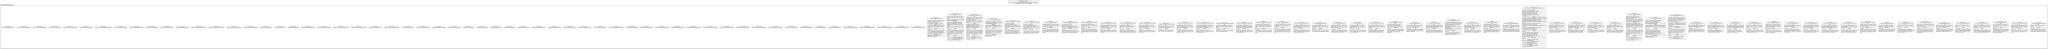

In [ ]:
%viz TechnicalRequirementsPackage --view tree

### ✅ `FunctionSpecificationPackage` — `Function\FunctionSpecificationPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package FunctionSpecificationPackage {
	
	private import FunctionalRequirementsPackage::*;
	private import FunctionsPackage::*;
	
	requirement performLunarMissionSpecification {
		doc /* Apollo 11 Function requirements group */
		subject performLunarMission : PerformLunarMission;

		requirement 'flr-R001' : PropellantLoadingRequirement;
		requirement 'flr-R002' : ConsumableConditioningRequirement;
		requirement 'flr-R003' : CrewIngressRequirement;
		requirement 'flr-R004' : CabinPressurizationRequirement;
		requirement 'flr-R005' : CountdownSequencingRequirement;
		requirement 'flr-R006' : CountdownAbortRequirement;
		requirement 'flr-R007' : Stage1ThrustInitiationRequirement;
		requirement 'flr-R008' : Stage1ThrustMagnitudeRequirement;
		requirement 'flr-R009' : Stage2ThrustInitiationRequirement;
		requirement 'flr-R010' : Stage2PropulsionRequirement;
		requirement 'flr-R011' : OrbitInsertionThrustInitiationRequirement;
		requirement 'flr-R012' : OrbitInsertionThrustTerminationRequirement;
		requirement 'flr-R013' : AscentGuidanceRequirement;
		requirement 'flr-R014' : AscentStagingCommandRequirement;
		requirement 'flr-R015' : CrewAscentMonitoringRequirement;
		requirement 'flr-R016' : CrewAscentAbortRequirement;
		requirement 'flr-R017' : GroundTelemetryAnalysisRequirement;
		requirement 'flr-R018' : GroundPerformanceVerificationRequirement;
		requirement 'flr-R019' : TliThrustInitiationRequirement;
		requirement 'flr-R020' : TliThrustControlRequirement;
		requirement 'flr-R021' : ModuleSeparationRequirement;
		requirement 'flr-R022' : ModuleRepositioningRequirement;
		requirement 'flr-R023' : ModuleConnectionRequirement;
		requirement 'flr-R024' : InSpacePropulsionRequirement;
		requirement 'flr-R025' : AttitudeControlRequirement;
		requirement 'flr-R026' : NavigationalDataAcquisitionRequirement;
		requirement 'flr-R027' : TrajectoryCalculationRequirement;
		requirement 'flr-R028' : CourseCorrectionCalculationRequirement;
		requirement 'flr-R029' : CourseCorrectionExecutionRequirement;
		requirement 'flr-R030' : CrewSystemMonitoringRequirement;
		requirement 'flr-R031' : GroundSystemMonitoringRequirement;
		requirement 'flr-R032' : SpacecraftDataTransmissionRequirement;
		requirement 'flr-R033' : SpacecraftDataReceptionRequirement;
		requirement 'flr-R034' : GroundTrackingRequirement;
		requirement 'flr-R035' : GroundCommunicationRelayRequirement;
		requirement 'flr-R036' : CrewActivitySchedulingRequirement;
		requirement 'flr-R037' : CrewRestProvisionRequirement;
		requirement 'flr-R038' : LoiThrustRequirement;
		requirement 'flr-R039' : LoiGuidanceRequirement;
		requirement 'flr-R040' : LanderSystemVerificationRequirement;
		requirement 'flr-R041' : LanderInterfaceVerificationRequirement;
		requirement 'flr-R042' : LanderCrewTransferRequirement;
		requirement 'flr-R043' : LanderConfigurationRequirement;
		requirement 'flr-R044' : ModuleDisengagementRequirement;
		requirement 'flr-R045' : ModuleSeparationManeuverRequirement;
		requirement 'flr-R046' : DescentPropulsionRequirement;
		requirement 'flr-R047' : DescentDataDisplayRequirement;
		requirement 'flr-R048' : DescentDataProcessingRequirement;
		requirement 'flr-R049' : ManualAttitudeControlRequirement;
		requirement 'flr-R050' : ManualPositionControlRequirement;
		requirement 'flr-R051' : PostLandingSafingRequirement;
		requirement 'flr-R052' : PostLandingVerificationRequirement;
		requirement 'flr-R053' : EgressPreparationRequirement;
		requirement 'flr-R054' : CabinDepressurizationRequirement;
		requirement 'flr-R055' : SurfaceMobilityRequirement;
		requirement 'flr-R056' : SymbolicDeploymentRequirement;
		requirement 'flr-R057' : SampleCollectionRequirement;
		requirement 'flr-R058' : SampleStorageRequirement;
		requirement 'flr-R059' : InstrumentDeploymentRequirement;
		requirement 'flr-R060' : VisualTransmissionRequirement;
		requirement 'flr-R061' : EvaIngressRequirement;
		requirement 'flr-R062' : CabinRepressurizationRequirement;
		requirement 'flr-R063' : SurfaceHabitationRequirement;
		requirement 'flr-R064' : SurfaceTimelineManagementRequirement;
		requirement 'flr-R065' : AscentThrustInitiationRequirement;
		requirement 'flr-R066' : AscentPropulsionRequirement;
		requirement 'flr-R067' : RendezvousCalculationRequirement;
		requirement 'flr-R068' : RendezvousExecutionRequirement;
		requirement 'flr-R069' : DockingApproachRequirement;
		requirement 'flr-R070' : DockingLatchingRequirement;
		requirement 'flr-R071' : IntervehicularCrewTransferRequirement;
		requirement 'flr-R072' : IntervehicularSampleTransferRequirement;
		requirement 'flr-R073' : AscentStageSeparationRequirement;
		requirement 'flr-R074' : AscentStageDisposalRequirement;
		requirement 'flr-R075' : TeiPropulsionRequirement;
		requirement 'flr-R076' : ReentryConfigurationRequirement;
		requirement 'flr-R077' : ServiceModuleJettisonRequirement;
		requirement 'flr-R078' : CleanSeparationRequirement;
		requirement 'flr-R079' : ReentryGuidanceRequirement;
		requirement 'flr-R080' : HeatDissipationRequirement;
		requirement 'flr-R081' : DeceleratorDeploymentRequirement;
		requirement 'flr-R082' : FinalVelocityRequirement;
		requirement 'flr-R083' : WaterLandingRequirement;
		requirement 'flr-R084' : PostLandingSystemsRequirement;
		requirement 'flr-R085' : CrewRecoveryRequirement;
		requirement 'flr-R086' : VesselTransferRequirement;
		requirement 'flr-R087' : QuarantineImplementationRequirement;
		requirement 'flr-R088' : QuarantineHabitationRequirement;
		requirement 'flr-R089' : SamplePreservationRequirement;
		requirement 'flr-R090' : SampleTransportRequirement;
		requirement 'flr-R091' : TGNCNavigationAccuracy;
		requirement 'flr-R092' : ManualPilotingLogic;
		requirement 'flr-R093' : SystemInterfaceCompatibility;
		requirement 'flr-R094' : TrainingSimulatorHours;
		requirement 'flr-R095' : CourseCorrectionCapability;
		requirement 'flr-R096' : SpacecraftOrientationControl;
		requirement 'flr-R097' : DescentDataAcquisition;
		requirement 'flr-R098' : LaunchVehicleAscentThrust;
		requirement 'flr-R099' : DescentRateModulation;
		requirement 'flr-R100' : ThermalProtectionLogic;
		requirement 'flr-R101' : TouchdownEnergyDissipation;
		requirement 'flr-R102' : AtmosphericScrubbingFunction;
		requirement 'flr-R103' : TelemetryStreamIntegrity;
		requirement 'flr-R104' : EMUPressureMaintenance;
		requirement 'flr-R105' : SoftwareMissionProficiency;
		requirement 'flr-R106' : SpaceEnvironmentResilience;
		requirement 'flr-R107' : VisualDataCapture;
		requirement 'flr-R108' : WasteContainmentFunction;
		requirement 'flr-R109' : CrossVehicleAudioLink;
		requirement 'flr-R110' : ComponentFaultTolerance;
		requirement 'flr-R111' : HumanMedicalSelfSufficiency;
		requirement 'flr-R112' : DataRedundancyArchiving;
		
		satisfy 'flr-R001' by performLunarMission.outbound.prep.load;
		satisfy 'flr-R002' by performLunarMission.outbound.prep.load;
		satisfy 'flr-R003' by performLunarMission.outbound.prep.board;
		satisfy 'flr-R004' by performLunarMission.outbound.prep.board;
		satisfy 'flr-R005' by performLunarMission.outbound.launch.countdown;
		satisfy 'flr-R006' by performLunarMission.outbound.launch.countdown;
		satisfy 'flr-R007' by performLunarMission.outbound.launch.provideThrust1;
		satisfy 'flr-R008' by performLunarMission.outbound.launch.provideThrust1;
		satisfy 'flr-R009' by performLunarMission.outbound.launch.provideThrust2;
		satisfy 'flr-R010' by performLunarMission.outbound.launch.provideThrust2;
		satisfy 'flr-R011' by performLunarMission.outbound.launch.provideThrust3;
		satisfy 'flr-R012' by performLunarMission.outbound.launch.provideThrust3;
		satisfy 'flr-R013' by performLunarMission.outbound.launch.guide;
		satisfy 'flr-R014' by performLunarMission.outbound.launch.guide;
		satisfy 'flr-R015' by performLunarMission.outbound.launch.observe;
		satisfy 'flr-R016' by performLunarMission.outbound.launch.observe;
		satisfy 'flr-R017' by performLunarMission.outbound.launch.analyze;
		satisfy 'flr-R018' by performLunarMission.outbound.launch.analyze;
		satisfy 'flr-R019' by performLunarMission.outbound.tli.burn;
		satisfy 'flr-R020' by performLunarMission.outbound.tli.control;
		satisfy 'flr-R021' by performLunarMission.outbound.tli.executeTransposition;
		satisfy 'flr-R022' by performLunarMission.outbound.tli.executeTransposition;
		satisfy 'flr-R023' by performLunarMission.outbound.tli.reconfigure;
		satisfy 'flr-R024' by performLunarMission.outbound.loi.burn;
		satisfy 'flr-R025' by performLunarMission.outbound.tli.provideAttitudeControlAndThrust;
		satisfy 'flr-R026' by performLunarMission.outbound.coast.trackAndRelay;
		satisfy 'flr-R027' by performLunarMission.outbound.coast.calculate;
		satisfy 'flr-R028' by performLunarMission.outbound.coast.calculate;
		satisfy 'flr-R029' by performLunarMission.outbound.coast.correct;
		satisfy 'flr-R030' by performLunarMission.outbound.coast.monitorOnboard;
		satisfy 'flr-R031' by performLunarMission.outbound.coast.monitorGround;
		satisfy 'flr-R032' by performLunarMission.outbound.coast.comms;
		satisfy 'flr-R033' by performLunarMission.outbound.coast.comms;
		satisfy 'flr-R034' by performLunarMission.outbound.coast.trackAndRelay;
		satisfy 'flr-R035' by performLunarMission.outbound.coast.trackAndRelay;
		satisfy 'flr-R036' by performLunarMission.outbound.coast.rest;
		satisfy 'flr-R037' by performLunarMission.outbound.coast.rest;
		satisfy 'flr-R038' by performLunarMission.outbound.loi.burn;
		satisfy 'flr-R039' by performLunarMission.outbound.loi.control;
		satisfy 'flr-R040' by performLunarMission.lunarOps.prepLanding.checkout;
		satisfy 'flr-R041' by performLunarMission.lunarOps.prepLanding.checkout;
		satisfy 'flr-R042' by performLunarMission.lunarOps.prepLanding.prep;
		satisfy 'flr-R043' by performLunarMission.lunarOps.prepLanding.prep;
		satisfy 'flr-R044' by performLunarMission.lunarOps.prepLanding.undock;
		satisfy 'flr-R045' by performLunarMission.lunarOps.prepLanding.undock;
		satisfy 'flr-R046' by performLunarMission.lunarOps.land.burn;
		satisfy 'flr-R047' by performLunarMission.lunarOps.land.monitor;
		satisfy 'flr-R048' by performLunarMission.lunarOps.land.monitor;
		satisfy 'flr-R049' by performLunarMission.lunarOps.land.pilot;
		satisfy 'flr-R050' by performLunarMission.lunarOps.land.pilot;
		satisfy 'flr-R051' by performLunarMission.lunarOps.explore.postLand;
		satisfy 'flr-R052' by performLunarMission.lunarOps.explore.postLand;
		satisfy 'flr-R053' by performLunarMission.lunarOps.explore.prepEva;
		satisfy 'flr-R054' by performLunarMission.lunarOps.explore.prepEva;
		satisfy 'flr-R055' by performLunarMission.lunarOps.explore.eva;
		satisfy 'flr-R056' by performLunarMission.lunarOps.explore.eva;
		satisfy 'flr-R057' by performLunarMission.lunarOps.explore.collect;
		satisfy 'flr-R058' by performLunarMission.lunarOps.explore.collect;
		satisfy 'flr-R059' by performLunarMission.lunarOps.explore.deploy;
		satisfy 'flr-R060' by performLunarMission.lunarOps.explore.deploy;
		satisfy 'flr-R061' by performLunarMission.lunarOps.explore.conclude;
		satisfy 'flr-R062' by performLunarMission.lunarOps.explore.conclude;
		satisfy 'flr-R063' by performLunarMission.lunarOps.explore.rest;
		satisfy 'flr-R064' by performLunarMission.lunarOps.explore.rest;
		satisfy 'flr-R065' by performLunarMission.lunarOps.ascendAndDock.ascend;
		satisfy 'flr-R066' by performLunarMission.lunarOps.ascendAndDock.ascend;
		satisfy 'flr-R067' by performLunarMission.lunarOps.ascendAndDock.calculate;
		satisfy 'flr-R068' by performLunarMission.lunarOps.ascendAndDock.rendezvous;
		satisfy 'flr-R069' by performLunarMission.lunarOps.ascendAndDock.dock;
		satisfy 'flr-R070' by performLunarMission.lunarOps.ascendAndDock.dock;
		satisfy 'flr-R071' by performLunarMission.lunarOps.ascendAndDock.transfer;
		satisfy 'flr-R072' by performLunarMission.lunarOps.ascendAndDock.transfer;
		satisfy 'flr-R073' by performLunarMission.lunarOps.ascendAndDock.jettison;
		satisfy 'flr-R074' by performLunarMission.lunarOps.ascendAndDock.jettison;
		satisfy 'flr-R075' by performLunarMission.returnJourney.tei.burn;
		satisfy 'flr-R076' by performLunarMission.returnJourney.coast.prep;
		satisfy 'flr-R077' by performLunarMission.returnJourney.land.separate;
		satisfy 'flr-R078' by performLunarMission.returnJourney.land.separate;
		satisfy 'flr-R079' by performLunarMission.returnJourney.land.guide;
		satisfy 'flr-R080' by performLunarMission.returnJourney.land.guide;
		satisfy 'flr-R081' by performLunarMission.returnJourney.land.deploy;
		satisfy 'flr-R082' by performLunarMission.returnJourney.land.deploy;
		satisfy 'flr-R083' by performLunarMission.returnJourney.land.splashdown;
		satisfy 'flr-R084' by performLunarMission.returnJourney.land.splashdown;
		satisfy 'flr-R085' by performLunarMission.returnJourney.recover.retrieve;
		satisfy 'flr-R086' by performLunarMission.returnJourney.recover.retrieve;
		satisfy 'flr-R087' by performLunarMission.returnJourney.recover.quarantine;
		satisfy 'flr-R088' by performLunarMission.returnJourney.recover.quarantine;
		satisfy 'flr-R089' by performLunarMission.returnJourney.recover.secure;
		satisfy 'flr-R090' by performLunarMission.returnJourney.recover.secure;
		satisfy 'flr-R091' by performLunarMission.outbound.coast.trackAndRelay;
		satisfy 'flr-R092' by performLunarMission.lunarOps.land.pilot;
		satisfy 'flr-R093' by performLunarMission.outbound.prep.load;
		satisfy 'flr-R094' by performLunarMission.outbound.prep.board;
		satisfy 'flr-R095' by performLunarMission.outbound.coast.correct;
		satisfy 'flr-R096' by performLunarMission.outbound.tli.provideAttitudeControlAndThrust;
		satisfy 'flr-R097' by performLunarMission.lunarOps.land.monitor;
		satisfy 'flr-R098' by performLunarMission.outbound.launch.provideThrust1;
		satisfy 'flr-R099' by performLunarMission.lunarOps.land.burn;
		satisfy 'flr-R100' by performLunarMission.returnJourney.land.guide;
		satisfy 'flr-R101' by performLunarMission.lunarOps.land.burn;
		satisfy 'flr-R102' by performLunarMission.outbound.coast.monitorOnboard;
		satisfy 'flr-R103' by performLunarMission.outbound.coast.comms;
		satisfy 'flr-R104' by performLunarMission.lunarOps.explore.eva;
		satisfy 'flr-R105' by performLunarMission.outbound.launch.guide;
		satisfy 'flr-R106' by performLunarMission.outbound.coast.monitorOnboard;
		satisfy 'flr-R107' by performLunarMission.lunarOps.explore.deploy;
		satisfy 'flr-R108' by performLunarMission.outbound.coast.monitorOnboard;
		satisfy 'flr-R109' by performLunarMission.lunarOps.explore.eva;
		satisfy 'flr-R110' by performLunarMission.outbound.loi.burn;
		satisfy 'flr-R111' by performLunarMission.outbound.coast.rest;
		satisfy 'flr-R112' by performLunarMission.returnJourney.recover.retrieve;		
	}
}

✅ FunctionSpecificationPackage loaded successfully (2.415s)


#### ✅ Visualization: `%viz FunctionSpecificationPackage --view tree`

In [ ]:
%viz FunctionSpecificationPackage --view tree

### ✅ `LogicalComponentsPackage` — `Logical\LogicalComponentsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package LogicalComponentsPackage {

	private import CoSMAPackage::*;
	private import FunctionsPackage::*;

	part def LaunchSystem :> LogicalComponent {
		doc /* This system's sole purpose is to propel the payload from Earth's surface onto a precise path to the Moon. It is responsible for all functions related to ascent and injection into a translunar trajectory. */
		perform action provideStage1Thrust : ProvideStage1Thrust;
		perform action provideStage2Thrust : ProvideStage2Thrust;
		perform action provideOrbitInsertionThrust : ProvideOrbitInsertionThrust;
		perform action guideAscentTrajectory : GuideAscentTrajectory;
		perform action provideTranslunarInjectionThrust : ProvideTranslunarInjectionThrust;
		perform action controlTranslunarInjectionBurn : ControlTranslunarInjectionBurn;
	}

	part def Spacecraft :> LogicalComponent {
		/* This system comprises the vehicles that travel to, operate at, and return from the Moon. It handles all functions related to in-space travel, life support, landing, and returning through Earth's atmosphere. */
		perform action provideAttitudeControlThrust : ProvideAttitudeControlThrust;
		perform action mechanicallyLatchModules : MechanicallyLatchModules;
		perform action calculateCourseCorrection : CalculateCourseCorrection;
		perform action executeCourseCorrectionBurn : ExecuteCourseCorrectionBurn;
		perform action transmitAndReceiveSpacecraftSignals : TransmitAndReceiveSpacecraftSignals;
		perform action provideLunarOrbitInsertionThrust : ProvideLunarOrbitInsertionThrust;
		perform action controlLunarOrbitInsertionBurn : ControlLunarOrbitInsertionBurn;
		perform action separateLanderFromOrbiter : SeparateLanderFromOrbiter;
		perform action executeDescentBurn : ExecuteDescentBurn;
		perform action executeAscentBurn : ExecuteAscentBurn;
		perform action calculateRendezvousManeuvers : CalculateRendezvousManeuvers;
		perform action executeRendezvousBurns : ExecuteRendezvousBurns;
		perform action discardAscentStage : DiscardAscentStage;
		perform action executeTransearthBurn : ExecuteTransearthBurn;
		perform action separateReturnCapsule : SeparateReturnCapsule;
		perform action guideAtmosphericEntry : GuideAtmosphericEntry;
		perform action deployDecelerators : DeployDecelerators;
		perform action performSplashdown : PerformSplashdown;
	}

	part def GroundSupportSystem :> LogicalComponent {
		doc /* This system is the Earth-based infrastructure and personnel that manage, control, and support the mission from start to finish. */
		perform action performPropellantLoading : PerformPropellantLoading;
		perform action performCrewIngress : PerformCrewIngress;
		perform action retrieveVehicleAndCrew : RetrieveVehicleAndCrew;
		perform action executeQuarantine : ExecuteQuarantine;
		perform action secureReturnedSamples : SecureReturnedSamples;
		
		perform action executeTerminalCountdown : ExecuteTerminalCountdown;
		perform action analyzeLaunchTelemetryFromGround : AnalyzeLaunchTelemetryFromGround;
		perform action monitorDownlinkedTelemetry : MonitorDownlinkedTelemetry;		
		perform action monitorDescent : MonitorDescent;
	}

	part def DataTransmissionNetwork {
		doc /* The system to relay and transmit data between the SoS elements. */
		perform action trackAndRelayGroundSignals : TrackAndRelayGroundSignals;
	}

	part def EVASystem :> LogicalComponent {
		doc /* This system consists of the personal equipment required for an astronaut to live and work in the vacuum of space on the lunar surface. */
		perform action provideIndividualLifesupport: ProvideIndividualLifesupport;
	}

	part def Crew :> LogicalComponent {
		doc /* This system represents the human operators who pilot the spacecraft, conduct experiments, and make real-time decisions. */
		perform action observeAscentDataFromCockpit : ObserveAscentDataFromCockpit;
		perform action executeTranspositionManeuver : ExecuteTranspositionManeuver;
		perform action monitorOnboardSystems : MonitorOnboardSystems;
		perform action manageCrewSchedules : ManageCrewSchedules;
		perform action performOrbitalSystemCheckouts : PerformOrbitalSystemCheckouts;
		perform action prepareLanderForSeparation : PrepareLanderForSeparation;
		perform action manuallyPilotLander : ManuallyPilotLander;
		perform action performPostLandingCheck : PerformPostLandingCheck;
		perform action prepareForExtravehicularActivity : PrepareForExtravehicularActivity;
		perform action conductSurfaceExploration : ConductSurfaceExploration;
		perform action gatherLunarSamples : GatherLunarSamples;
		perform action deploySurfaceExperiments : DeploySurfaceExperiments;
		perform action completeExtravehicularActivity : CompleteExtravehicularActivity;
		perform action conductSurfaceRestPeriod : ConductSurfaceRestPeriod;
		perform action connectSpacecraft : ConnectSpacecraft;
		perform action transferCrewAndMaterials : TransferCrewAndMaterials;
		perform action prepareVehicleForReentry : PrepareVehicleForReentry;
	}
}

✅ LogicalComponentsPackage loaded successfully (0.193s)


#### ✅ Visualization: `%viz LogicalComponentsPackage --view tree`

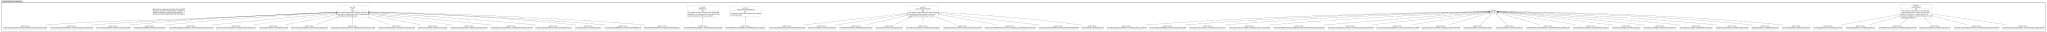

In [ ]:
%viz LogicalComponentsPackage --view tree

### ✅ `ContextPackage` — `Purpose\ContextPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package ContextPackage {

	private import SI::*;
	private import ISQ::*;
	private import ScalarValues::*;
	private import CoSMAPackage::*;
	private import CoSMAQuantitiesAndUnitsPackage::*;
	private import USCustomaryUnits::*;
	private import LogicalComponentsPackage::*;

	part def EarthEnvironment {
		doc /* The starting and ending physical environment for the mission. */
		attribute surfaceGravity :> ISQ::acceleration = 1 [gn];
		attribute standardAtmosphericPressure :> ISQ::pressure = 101325 [pascal];
		attribute rotationalVelocity :> ISQ::speed = 465 [m/s]; // At the equator
		attribute reentryInterfaceAltitude :> ISQ::length = 122 ['km'];
	}

	part def CislunarSpaceEnvironment {
		doc /* The physical environment between Earth and the Moon. */
		attribute ambientPressure :> ISQ::pressure = 3.2E-14 [pascal]; // Approximate pressure of interplanetary space
		attribute solarIrradiance :> ISQ::irradiance = 1361 [W/m^2];
		attribute backgroundTemperature :> ISQ::thermodynamicTemperature = 2.7 [K];
	}

	part def LunarEnvironment {
		doc /* The destination physical environment. */
		attribute surfaceGravity :> ISQ::acceleration = 1.62 ['m⋅s⁻²'];
		attribute surfacePressure :> ISQ::pressure = 3E-10 [pascal]; // Near-perfect vacuum
		attribute maxDayTemperature :> ISQ::thermodynamicTemperature = 400 [K];  // Approx. 127 °C
		attribute minNightTemperature :> ISQ::thermodynamicTemperature = 100 [K];  // Approx. -173 °C
	}	

	part def LaunchSite :> System, GroundSupportSystem {
		doc /* The specific ground facility from which the mission originates. */
		attribute name: String = "John F. Kennedy Space Center";
		attribute location: String = "Merritt Island, Florida, USA";
		attribute geographicCoordinates: String = "28.57° N, 80.65° W";
		
		part vehicleAssemblyBuilding : VehicleAssemblyBuilding;
		part launchControlCenter : LaunchControlCenter;
		part crawlerTransporter : CrawlerTransporter;
	}

	part def VehicleAssemblyBuilding :> System, GroundSupportSystem {
		doc /* The massive facility used to stack the space vehicle. */
	}

	part def LaunchControlCenter :> System, GroundSupportSystem {
		doc /* The facility for controlling the pre-launch and launch sequences. */
	}

	part def CrawlerTransporter :> System, GroundSupportSystem {
		doc /* The mobile platform used to move the rocket from the VAB to the launch pad. */
	}

	part def MissionControl :> System, GroundSupportSystem {
		doc /* The Earth-based command, control, and analysis center for post-launch operations. */
		attribute location: String = "Houston, Texas";
	}

	part def RecoveryForces :> System, GroundSupportSystem {
		doc /* The assets tasked with retrieving the crew and capsule after splashdown. */  
	}

	part def MannedSpaceFlightNetwork :> System, DataTransmissionNetwork {
		doc /* The Manned Space Flight Network (abbreviated MSFN, pronounced "misfin") was a set of tracking stations built to support the American Mercury, Gemini, Apollo, and Skylab space programs. */    	
	}

	part def Apollo11MissionContext :> Context {
		part vehicleAssemblyBuilding : VehicleAssemblyBuilding :> externalSystems;
		part launchControlCenter : LaunchControlCenter :> externalSystems;
		part crawlerTransporter : CrawlerTransporter :> externalSystems;
		part missionControl : MissionControl :> externalSystems;
		part recoveryForces : RecoveryForces :> externalSystems;
		part mannedSpaceFlightNetwork : MannedSpaceFlightNetwork :> externalSystems;
	}
}

✅ ContextPackage loaded successfully (0.215s)


#### ✅ Visualization: `%viz ContextPackage --view tree`

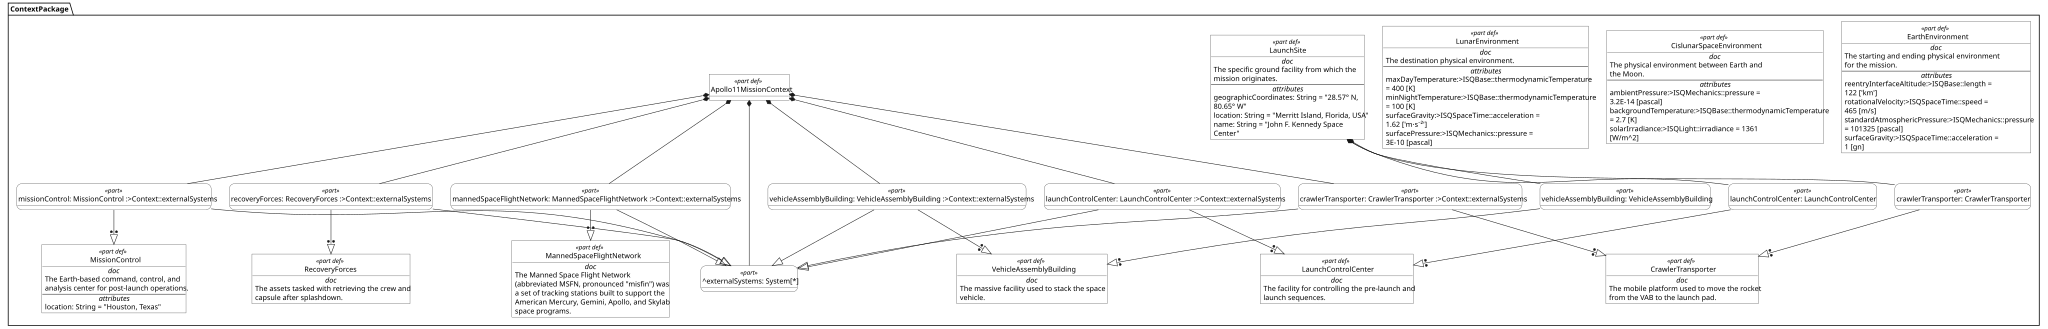

In [ ]:
%viz ContextPackage --view tree

### ✅ `TechnicalComponentsPackage` — `Technical\TechnicalComponentsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package TechnicalComponentsPackage {

	private import CoSMAPackage::*;
	private import CoSMAQuantitiesAndUnitsPackage::*;
	private import ShapeItems::*;
	private import SI::*;
	private import LogicalComponentsPackage::*;
	private import TechnicalPortsPackage::*;

	abstract part def PropelledSpacecraft :> FuelledComponent {
		attribute maxThrust :> ISQ::force;
		attribute specificImpulse :> CoSMAQuantitiesAndUnitsPackage::specificImpulse;
	}

	abstract part def FuelledComponent :> HardwareComponent {
		attribute propellantMass :> ISQ::mass;
		attribute dryMass :> ISQ::mass;
		attribute :>> mass = dryMass + propellantMass;
	}

	abstract part def RocketEngine :> HardwareComponent {
		doc /* An abstract representation of a rocket engine, defining its core performance attributes. */
		attribute thrustVacuum :> ISQ::force;
		attribute specificImpulseVacuum :> CoSMAQuantitiesAndUnitsPackage::specificImpulse;
	}

	abstract part def RocketStage :> FuelledComponent {
		doc /* An abstract representation of a single stage of a rocket, containing engines and propellant. */
		part engines[1..*] ordered : RocketEngine;
	}

	abstract part def MultistageRocket :> System {
		doc /* An abstract representation of a rocket composed of multiple stages. */
		part stages[1..*] ordered : RocketStage;
	}

	part def SaturnVInstrumentUnit :> HardwareComponent, PowerConsumer {
		doc /* The 'brain' of the Saturn V, providing guidance and control during ascent. */
		attribute dryMass :> ISQ::mass = 1950 [kg];
		attribute :>> failureRate = 5E-6 [1/h];
		attribute :>> powerLoad = 450 [W];
		
		port stageControlPort : ControlPort;
		port payloadInterfacePort : PayloadInterfacePort;
	}

	part def ApolloLaunchEscapeSystem :> HardwareComponent, PowerConsumer  {
		doc /* A solid-fueled rocket tower mounted atop the Command Module to pull it away from the launch vehicle in an emergency. */
		attribute :>> mass = 4170 [kg];
		attribute :>> powerLoad = 50 [W];
		attribute :>> failureRate = 1E-7 [1/h];
		
		port cmInterfacePort : ~LaunchEscapeSystemPort;
	}

	part def ApolloCommandModule :> HardwareComponent, PowerConsumer {
		doc /* The conical crew cabin, control center, and reentry vehicle. */
		attribute :>> mass = 5840 [kg];
		attribute :>> powerLoad = 2000 [W];
		attribute :>> failureRate = 1.5E-6 [1/h];
		
		port umbilicalPort : ~UmbilicalPort;
		port dockingPort : DockingPort;	
		port lesInterfacePort : LaunchEscapeSystemPort;
	}

	part def ApolloServiceModule :> PropelledSpacecraft, PowerConsumer, PowerProvider {
		doc /* The primary support module for the Command Module, containing the main engine, power systems, and consumables. */
		attribute :>> dryMass = 6160 [kg];
		attribute :>> propellantMass = 18440 [kg];
		attribute :>> maxThrust = 91 ['kN'];
		attribute :>> specificImpulse = 314 ['s'];
		attribute :>> powerGenerated = 3000 [W];
		attribute :>> powerLoad = 500 [W];
		attribute :>> failureRate = 2.0E-6 [1/h];		
		
		port umbilicalPort : UmbilicalPort;
		port launchVehicleInterfacePort : ~StagingPort;
	}

	part def ApolloCommandServiceModule :> HardwareComponent, PowerConsumer, PowerProvider {
		doc /* The combined Command and Service Module (CSM), which functions as the primary spacecraft for lunar transit and Earth return. */
		part commandModule : ApolloCommandModule;
		part serviceModule : ApolloServiceModule;
		
		attribute :>> powerGenerated = serviceModule.powerGenerated;
		attribute :>> powerLoad = commandModule.powerLoad + serviceModule.powerLoad;
		
		interface cmSMUmbilical : CSMInterface connect serviceModule.umbilicalPort to commandModule.umbilicalPort;
	}

	part def ApolloLunarModule :> HardwareComponent, PowerConsumer, PowerProvider {
		doc /* The two-stage vehicle that performed the lunar landing and ascent. */
		
		part lunarModuleDescentStage : LunarModuleDescentStage;
		part lunarModuleAscentStage : LunarModuleAscentStage;
		
		attribute :>> powerGenerated = lunarModuleDescentStage.powerGenerated + lunarModuleAscentStage.powerGenerated;
		attribute :>> powerLoad = lunarModuleDescentStage.powerLoad + lunarModuleAscentStage.powerLoad;
		
		interface lmInterstage : LMStagingInterface connect lunarModuleDescentStage.upperStagePort to lunarModuleAscentStage.lowerStagePort;
	}

	part def LunarModuleDescentStage :> PropelledSpacecraft, PowerConsumer, PowerProvider {
		doc /* The lower portion of the Lunar Module, used for the powered landing and as a launch platform for the ascent stage. */
		attribute :>> dryMass = 2100 [kg];
		attribute :>> propellantMass = 8250 [kg];
		attribute :>> maxThrust = 45 ['kN'];
		attribute :>> specificImpulse = 305 ['s'];
		attribute :>> powerGenerated = 1500 [W];
		attribute :>> powerLoad = 1000 [W];
		attribute :>> failureRate = 3.0E-6 [1/h];		
		
		port upperStagePort : LMStagingPort;
	}

	part def LunarModuleAscentStage :> PropelledSpacecraft, PowerConsumer, PowerProvider {
		doc /* The upper portion of the Lunar Module, which served as the crew cabin and ascent vehicle to leave the lunar surface. */
		attribute :>> dryMass = 2220 [kg];
		attribute :>> propellantMass = 2370 [kg];
		attribute :>> maxThrust = 16 ['kN'];
		attribute :>> specificImpulse = 311 ['s'];
		attribute :>> powerGenerated = 1500 [W];
		attribute :>> powerLoad = 1200 [W];
		attribute :>> failureRate = 2.5E-6 [1/h];		
		
		port lowerStagePort : ~LMStagingPort;
		port dockingPort : DockingPort;
	}

	part def ApolloSpacecraftLMAdapter :> HardwareComponent {
		doc /* A conical structure that housed the Lunar Module during launch and connected the Apollo spacecraft to the Saturn V. */
		attribute :>> mass = 1840 [kg];
		
		port launchVehicleInterfacePort : ~PayloadInterfacePort;
		port csmInterfacePort : StagingPort;
	}

	part def ApolloSpacecraft :> System, Spacecraft {
		doc /* The complete payload stack for the Apollo mission, including the CSM, LM, SLA, and Launch Escape System. */
		part launchEscapeSystem : ApolloLaunchEscapeSystem;
		part commandServiceModule : ApolloCommandServiceModule;
		part lunarModule : ApolloLunarModule;
		part spacecraftLMAdapter : ApolloSpacecraftLMAdapter;

		interface cmLMDocking : DockingInterface connect commandServiceModule.commandModule.dockingPort to  lunarModule.lunarModuleAscentStage.dockingPort;
		
		interface : StagingInterface connect spacecraftLMAdapter.csmInterfacePort to commandServiceModule.serviceModule.launchVehicleInterfacePort;
		interface lesConnection : LESInterface connect commandServiceModule.commandModule.lesInterfacePort to launchEscapeSystem.cmInterfacePort;
	}

	part def SaturnV :> MultistageRocket, LaunchSystem {
		doc /* The three-stage, super heavy-lift launch vehicle used to send the Apollo spacecraft to the Moon. */
		attribute height :> ISQ::length = 110.6 [m];
		attribute launchMass :> ISQ::mass = 2970000 [kg];
		attribute payloadToLunarTransferOrbit :> ISQ::mass = 43500 [kg];
	   
		part stage1 : 'S-IC';
		part stage2 : 'S-II';
		part stage3 : 'S-IVB';
		part instrumentUnit : SaturnVInstrumentUnit;
		part :>> stages[3] = (stage1, stage2, stage3);

		interface stage1ToStage2 : StagingInterface connect stage1.upperStagePort to stage2.lowerStagePort;
		interface stage2ToStage3 : StagingInterface connect stage2.upperStagePort to  stage3.lowerStagePort;
		interface iuToStage3 : GuidanceInterface connect instrumentUnit.stageControlPort to stage3.controlPort;
	}

	part def 'F-1' :> RocketEngine {
		doc /* A single-chamber liquid-propellant rocket engine, the most powerful ever built, used in the S-IC first stage. */
		attribute thrustSeaLevel :> ISQ::force = 6770 ['kN'];
		attribute :>> thrustVacuum = 7770 ['kN'];
		attribute :>> specificImpulseVacuum = 304 ['s'];
	}

	part def 'J-2' :> RocketEngine {
		doc /* A liquid-fuel cryogenic rocket engine used in the S-II and S-IVB stages, notable for its restart capability. */
		attribute :>> thrustVacuum = 1033 ['kN'];
		attribute :>> specificImpulseVacuum = 421 ['s'];
	}

	part def 'S-IVB' :> RocketStage {
		doc /* The third stage of the Saturn V, responsible for the final push into Earth orbit and the critical Translunar Injection burn. */
		attribute :>> propellantMass = 109500 [kg];
		attribute :>> dryMass = 13500 [kg];
		
		port lowerStagePort : ~StagingPort;
		port controlPort : ~ControlPort;        
		
		part engine : 'J-2';
		part :>> engines[1] = (engine);
	}

	part def 'S-II' :> RocketStage {
		doc /* The second stage of the Saturn V, providing massive thrust in the upper atmosphere and vacuum of space. */
		attribute :>> propellantMass = 443000 [SI::kg];
		attribute :>> dryMass = 36200 [kg];
		
		port lowerStagePort : ~StagingPort;
		port upperStagePort : StagingPort;
		
		part engine1 : 'J-2';
		part engine2 : 'J-2';
		part engine3 : 'J-2';
		part engine4 : 'J-2';
		part engine5 : 'J-2';
		part :>> engines[5] = (engine1, engine2, engine3, engine4, engine5);
	}

	part def 'S-IC' :> RocketStage {
		doc /* The first stage of the Saturn V, providing the initial ~7.7 million pounds of thrust for liftoff. */
		attribute :>> propellantMass = 2077000 [kg];
		attribute :>> dryMass = 137000 [kg];
	   
		port upperStagePort : StagingPort;
		
		part engine1 : 'F-1';
		part engine2 : 'F-1';
		part engine3 : 'F-1';
		part engine4 : 'F-1';
		part engine5 : 'F-1';
		part :>> engines[5] = (engine1, engine2, engine3, engine4, engine5);
	}

	part def ExtravehicularMobilityUnit :> System, EVASystem {
		doc /* The 'A7L' spacesuit, a self-contained personal spacecraft providing life support for lunar EVAs. */
		attribute massOnEarth :> ISQ::mass = 83 [kg];
		attribute nominalOperatingPressure :> ISQ::pressure = 25.5 ['kPa'];
		attribute lifeSupportDuration :> ISQ::time = 7 ['h'];
		
		part psa: PressureSuiteAssembly;
		part plss: PortableLifeSupportSystem;
		
		interface suitToPLSSUmbilical : EVAInterface connect plss.umbilicalPort to psa.umbilicalPort;
	}

	part def PressureSuiteAssembly :> HardwareComponent {
		doc /* The main suit portion, providing pressure and mobility. */
		port umbilicalPort : ~EVAUmbilicalPort;
	}

	part def PortableLifeSupportSystem :> HardwareComponent {
		doc /* The 'backpack' containing oxygen, CO2 scrubbers, cooling water, and communications equipment. */
		port umbilicalPort : EVAUmbilicalPort;
	}	
}

✅ TechnicalComponentsPackage loaded successfully (0.647s)


#### ✅ Visualization: `%viz TechnicalComponentsPackage --view tree`

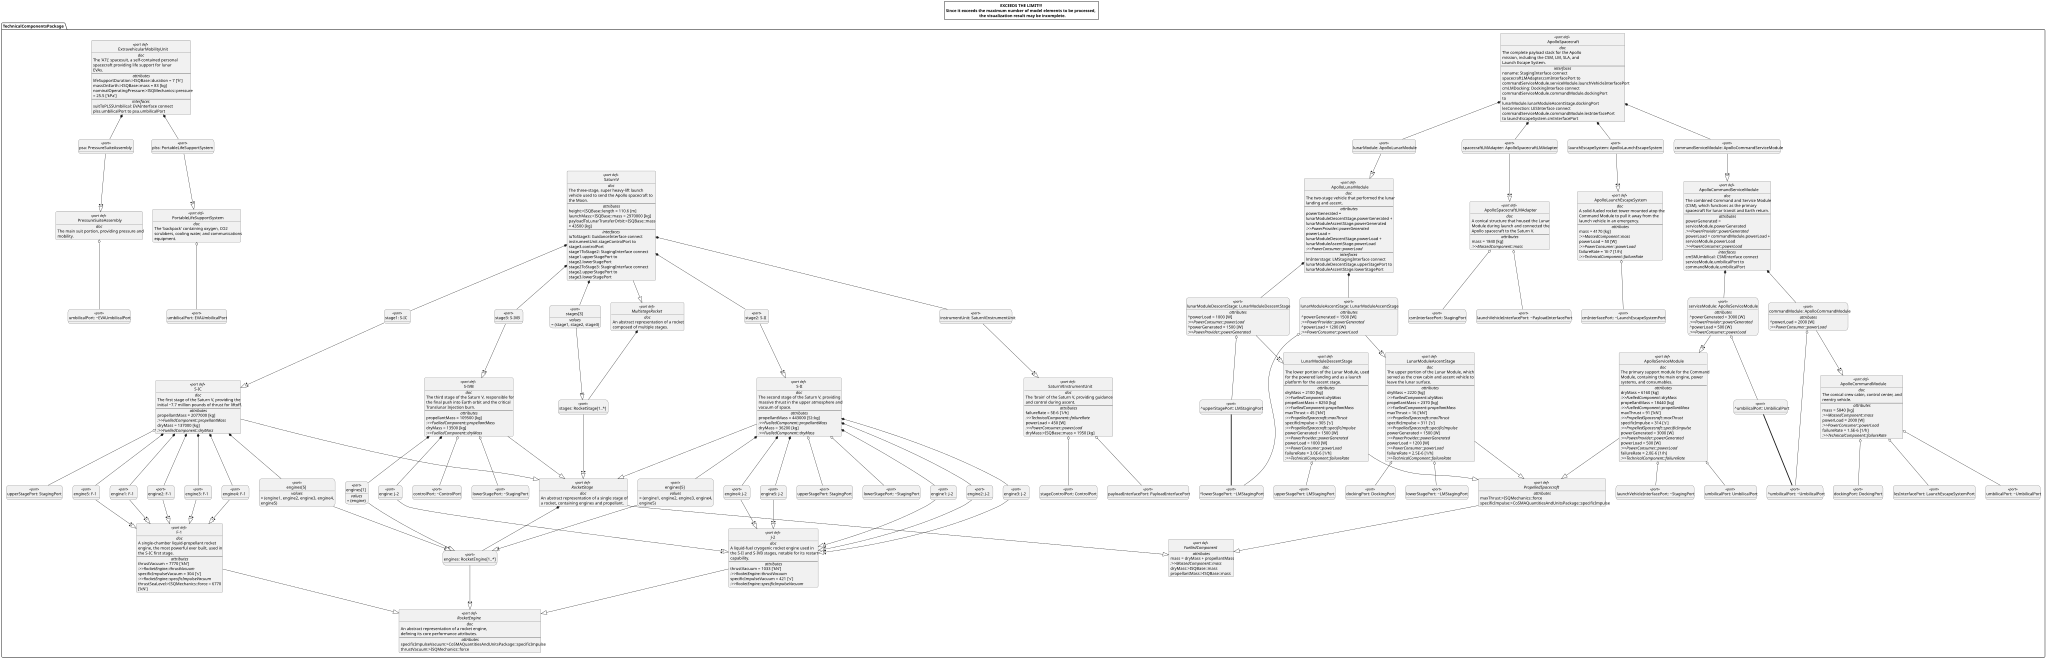

In [ ]:
%viz TechnicalComponentsPackage --view tree

### ✅ `CalculationsPackage` — `Analysis\CalculationsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package CalculationsPackage {
	
	private import ISQ::*;
	private import ScalarValues::*;
	private import CoSMAPackage::*;
	private import ScalarFunctions::*;
	private import CoSMAQuantitiesAndUnitsPackage::*;
	private import TechnicalComponentsPackage::*;
	private import NumericalFunctions::*;
	private import CollectionFunctions::*;
	private import ControlFunctions::*;
	private import NumericalFunctions::*;
	private import Parts::*;	
	
	calc def rollupPowerGeneration  {
		in system: System;
		return :> ISQ::power = system.subparts->select {
			in sys : Part;
			sys istype PowerProvider 
		}
		->collect {
			in sys : PowerProvider;
			sys.powerGenerated
		}
		->sum();
	}
	
	calc def rollupPowerConsumption  {
		in system: System;
		return :> ISQ::power = system.subparts->select {
			in sys : Part;
			sys istype PowerConsumer 
		}
		->collect {
			in sys : PowerConsumer;
			sys.powerLoad
		}
		->sum();
	}	
	
	
	calc def calculateTliDeltaV {
		doc /* Calculates the required Delta-V for a Hohmann-like Translunar Injection. */
		in mu_Earth :> ISQ::force;
		in r_leo :> ISQ::length;
		in r_apoapsis :> ISQ::length;
		return deltaV :> ISQ::speed = (mu_Earth * (2/r_leo - 2/(r_leo + r_apoapsis)))^(1/2) - (mu_Earth / r_leo)^(1/2);
	}

	calc def calculateLoiDeltaV {
		doc /* Calculates the required braking Delta-V for Lunar Orbit Insertion from a hyperbolic approach. */
		in v_inf :> ISQ::speed;
		in mu_Moon :> ISQ::force;
		in r_periapsis :> ISQ::length;
		return deltaV :> ISQ::speed = (v_inf^2 + 2*mu_Moon/r_periapsis)^(1/2) - (mu_Moon/r_periapsis)^(1/2);
	}

	calc def sumCosts {
		doc /* Sums the major cost categories to find the total program cost. */
		in r_d :> currency;
		in mfg :> currency;
		in ops :> currency;
		in personnel :> currency;
		return total :> currency = r_d + mfg + ops + personnel;
	}

	calc def calculateReliability {
		doc /* Calculates the reliability of a component over time using the exponential failure distribution. */
		in failureRate :> ISQ::frequency;
		in missionTime :> ISQ::duration;
		return reliability : RatioValue = eulerNumber^(-(failureRate * missionTime));
	}
	
	calc def evaluateMissionSuccess {
		doc /* Evaluates the overall mission success based on the achievement of primary objectives. */
		in crewSafe : Boolean;
		in landed : Boolean;
		in samplesReturned : Boolean;
		in instrumentsDeployed : Boolean;
		return isSuccess : Boolean = crewSafe and landed and samplesReturned and instrumentsDeployed;
	}

	calc def calculateMassBudgetStep {
		doc /* Calculates the remaining mass of a vehicle after a mission event. */
		in initialMass :> ISQ::mass;
		in propellantUsed :> ISQ::mass;
		in jettisonedMass :> ISQ::mass;
		return finalMass :> ISQ::mass = initialMass - propellantUsed - jettisonedMass;
	}
	
	calc def calculatePowerMargin {
		doc /* Calculates the difference between available power and the sum of all electrical loads. */
		in sourcePower :> ISQ::power;
		in totalLoadPower :> ISQ::power;
		return powerMargin :> ISQ::power = sourcePower - totalLoadPower;
	}

	calc def calculateDeltaV {
		doc /* Calculates the maximum change in velocity a stage can provide using the Tsiolkovsky Rocket Equation. */
		in isp :> specificImpulse;
		in g0 :> ISQ::acceleration;
		in m0 :> ISQ::mass;
		in mf :> ISQ::mass;
		return deltaV :> ISQ::speed = isp * g0 * ln(m0 / mf);
	}
	
	calc def calculateLaunchStageDeltaV {
		doc /* Calculates the delta-v provided by a launch stage (like S-IC or S-II) carrying an upper stack. */
		in stage: RocketStage;
		in payloadStack: HardwareComponent[*];
		
		payloadMass = sumGrossMass(payloadStack);
		initialMass = stage.dryMass + stage.propellantMass + payloadMass;
		finalMass = stage.dryMass + payloadMass;
		isp = stage.engines.specificImpulseVacuum;
		
		return deltaV :> ISQ::speed = calculateDeltaV(isp, initialMass, finalMass);
	}

	calc def calculateSpacecraftBurnDeltaV {
		doc /* Calculates the delta-v provided by a self-propelled spacecraft (CSM or LM stages). */
		in spacecraft: PropelledSpacecraft;

		initialMass = spacecraft.dryMass + spacecraft.propellantMass;
		finalMass = spacecraft.dryMass;
		isp = spacecraft.specificImpulse;
		
		return deltaV :> ISQ::speed = calculateDeltaV(isp, initialMass, finalMass);
	}
	
	calc def sumGrossMass {
		doc /* A utility to sum the gross (fully fueled) mass of a set of components. */
		in components: HardwareComponent[*];
		return totalMass :> ISQ::mass = sum(components.totalMass);
	}
	
	calc def sumDryMass {
		doc /* A utility to sum the dry mass of a set of components. */
		in components: FuelledComponent[*];
		return totalMass :> ISQ::mass = sum(components.dryMass);
	}
}

✅ CalculationsPackage loaded successfully (0.415s)


#### ✅ Visualization: `%viz CalculationsPackage --view tree`

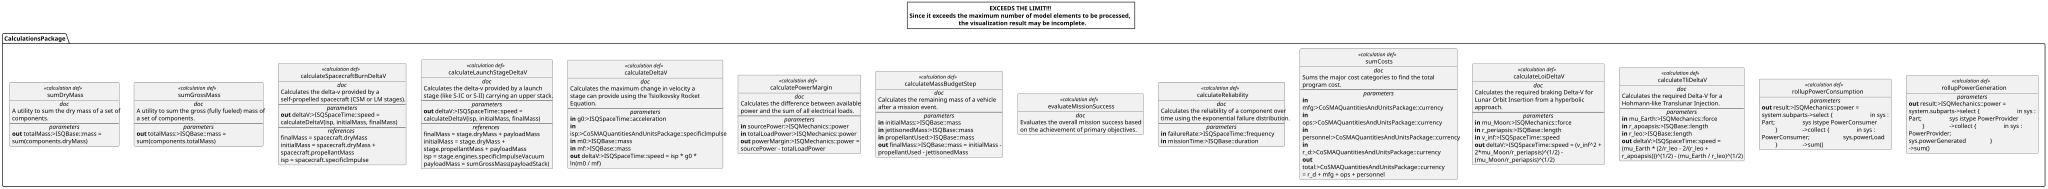

In [ ]:
%viz CalculationsPackage --view tree

### ✅ `TechnicalIndividualsPackage` — `Technical\TechnicalIndividualsPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package TechnicalIndividualsPackage {

	private import TechnicalComponentsPackage::*;

	// https:>//en.wikipedia.org/wiki/Saturn_V
	individual part def 'SA-500F' :> SaturnV {
		doc /* Facilities integration. Used to check precise fits and test facilities operation on Pad 39A before a flight model was ready. First stage scrapped, second stage converted to S-II-F/D, third stage on display at Kennedy Space Center. */
	}	
	individual part def 'SA-500D' :> SaturnV {
		 doc /* Dynamic testing. Used to evaluate the vehicle's response to vibrations. On display at the U.S. Space & Rocket Center, Huntsville, Alabama. */
	}
	individual part def 'S-IC-T' :> SaturnV {
		doc /*  All Systems Test. First stage used for static test firing at Marshall Space Flight Center. On display at Kennedy Space Center. */	
	}
	individual part def 'SA-501' :> SaturnV {	
		doc /* Apollo 4 First uncrewed, all-up test flight. */
	}
	individual part def 'SA-502' :> SaturnV {
		doc /* Apollo 6. Second uncrewed test flight; J-2 engine problems caused early shutdown of two engines in second stage, and prevented third stage restart. */
	}
	individual part def 'SA-503' :> SaturnV {
		doc /* Apollo 8. First crewed flight; first trans-lunar injection of Apollo command and service module. */	
	}
	individual part def 'SA-504' :> SaturnV {
		doc /* Apollo 9. Crewed low Earth orbit test of complete Apollo spacecraft with the Lunar Module (LM). */	
	}
	individual part def 'SA-505' :> SaturnV {
		doc /* Apollo 10. Second crewed trans-lunar injection of complete Apollo spacecraft with LM; Only Saturn V launched from Pad 39B. */	
	}
	individual part def 'SA-506' :> SaturnV {
		doc /* Apollo 11. First crewed lunar landing, at Sea of Tranquility. */
	}
	individual part def 'SA-507' :> SaturnV {
		doc /* Apollo 12. Vehicle was struck twice by lightning shortly after liftoff, but did not suffer serious damage. Made second crewed lunar landing, near Surveyor 3 at Ocean of Storms*/
	}
	individual part def 'SA-508' :> SaturnV {
		doc /* Apollo 13. Severe pogo oscillations in second stage caused early center engine shutdown; guidance compensated by burning remaining engines longer. Lunar landing mission was aborted by service module failure. */
	}
	individual part def 'SA-509' :> SaturnV {
		doc /* Apollo 14. Third crewed lunar landing, near Fra Mauro, Apollo 13's intended landing site. */
	}
	individual part def 'SA-510' :> SaturnV {
		doc /* Apollo 15. Fourth crewed lunar landing, at Hadley-Apennine. First extended Apollo mission, carrying lunar orbital Scientific Instrument Module and Lunar Roving Vehicle. */	
	}
	individual part def 'SA-511' :> SaturnV {
		doc /* Apollo 16. Fifth crewed lunar landing, at Descartes Highlands. */
	}
	individual part def 'SA-512' :> SaturnV {
		doc /* Apollo 17. Only night launch. Sixth and final crewed lunar landing, at Taurus-Littrow. */
		}
	individual part def 'SA-513' :> SaturnV {
		doc /* Skylab 1. Uncrewed launch of the Skylab orbital workshop, which replaced the third stage, S-IVB-513, on display at Johnson Space Center. Originally designated for canceled Apollo 18. */
	}
	individual part def 'SA-514' :> SaturnV {	
		doc /* Unused. Originally designated for canceled Apollo 18 or 19; never used. It was proposed for launching an International Skylab. This station would have been serviced by Apollo, Soyuz and later by the Space Shuttle. The first stage (S-IC-14) on display at Johnson Space Center, second and third stage (S-II-14, S-IV-14) on display at Kennedy Space Center. The S-II interstage is located at Parque de las Ciencias in Puerto Rico. */
	}
	individual part def 'SA-515' :> SaturnV {
		doc /* Unused. Originally designated for Apollo 20, never used. Later it was proposed to launch the backup Skylab station into orbit sometime between January 1975 and April 1976. That way, it could expand the Apollo-Soyuz mission by 56-90 days. The first stage was on display at Michoud Assembly Facility, until June 2016 then was moved to the INFINITY Science Center in Mississippi. The second stage (S-II-15) is on display at Johnson Space Center. The third stage was converted to a backup Skylab orbital workshop and is on display at the National Air and Space Museum. */
	}

	// https:>//en.wikipedia.org/wiki/Apollo_command_and_service_module
	individual part def 'CSM-098' :> ApolloCommandServiceModule {
		doc /* 2TV-1 Used in thermal vacuum tests. CSM on display at Academy of Science Museum, Moscow, Russia as individual part def of the Apollo Soyuz Test Project display. */
	}
	individual part def 'CM-099' :> ApolloCommandServiceModule {
		doc /* 2S-1 Skylab flight crew interface training; impact tests. Scrapped */
	}
	individual part def 'CSM-100' :> ApolloCommandServiceModule {
		doc /* 2S-2 static structural testing. Command module "transferred to Smithsonian as an artifact", service module on display at New Mexico Museum of Space History */
	}
	individual part def 'CSM-101' :> ApolloCommandServiceModule {
		doc /* Apollo 7. Command module was on display at National Museum of Science and Technology, Ottawa, Ontario, Canada from 1974 until 2004, now at the Frontiers of Flight Museum, Dallas, Texas after 30 years of being on loan. */
	}	
	individual part def 'CSM-102' :> ApolloCommandServiceModule {
		doc /* Launch Complex 34 checkout vehicle. Command module scrapped; service module is at JSC on top of the Little Joe II in Rocket Park with Boiler Plate 22 command module. */
	}			
	individual part def 'CSM-103' :> ApolloCommandServiceModule {
		doc /* Apollo 8. Command module on display at the Museum of Science and Industry in Chicago */	
	}		
	individual part def 'CSM-104' :> ApolloCommandServiceModule {
		doc /* Gumdrop	Apollo 9. Command module on display at San Diego Air and Space Museum */
	}	
	individual part def 'CSM-105' :> ApolloCommandServiceModule {
		doc /* acoustic tests	On display at National Air and Space Museum, Washington, D.C. as individual part def of the Apollo Soyuz Test Project display. */
	}		
	individual part def 'CSM-106' :> ApolloCommandServiceModule {
		doc /* Charlie Brown	Apollo 10. Command module on display at Science Museum, London */
	}	
	individual part def 'CSM-107' :> ApolloCommandServiceModule {
		doc /* Columbia	Apollo 11. Command module on display at National Air and Space Museum, Washington, D.C.	*/
	}	
	individual part def 'CSM-108' :> ApolloCommandServiceModule {
		doc /* Yankee Clipper	Apollo 12. Command module on display at Virginia Air & Space Center, Hampton, Virginia; previously on display at the National Naval Aviation Museum at Naval Air Station Pensacola, Pensacola, Florida (exchanged for CSM-116) */
	}	
	individual part def 'CSM-109' :> ApolloCommandServiceModule {
		doc /* Odyssey	Apollo 13. Command module on display at Kansas Cosmosphere and Space Center */
	}
	individual part def 'CSM-110' :> ApolloCommandServiceModule {
		doc /* Kitty Hawk	Apollo 14. Command module on display at the Kennedy Space Center */
	}
	individual part def 'CSM-111' :> ApolloCommandServiceModule {
		doc /* Apollo Soyuz Test Project. Command module currently on display at California Science Center in Los Angeles, California (formerly displayed at the Kennedy Space Center Visitor Complex) */
	}			
	individual part def 'CSM-112' :> ApolloCommandServiceModule {
		doc /* Endeavour	Apollo 15. Command module on display at National Museum of the United States Air Force, Wright-Patterson Air Force Base, Dayton, Ohio */
	}
	individual part def 'CSM-113' :> ApolloCommandServiceModule {
		doc /* Casper	Apollo 16. Command module on display at U.S. Space & Rocket Center, Huntsville, Alabama */
	}
	individual part def 'CSM-114' :> ApolloCommandServiceModule {
		doc /* America	Apollo 17. Command module on display at Space Center Houston, Houston, Texas */
	}
	individual part def 'CSM-115' :> ApolloCommandServiceModule {
		doc /* Apollo 19. Never fully completed - service module does not have its SPS nozzle installed. On display as individual part def of the Saturn V display at Johnson Space Center, Houston, Texas */
	}	
	individual part def 'CSM-115a' :> ApolloCommandServiceModule {
		doc /* Apollo 20. Never fully completed - internal structures not installed, used for spare individual part defs. Remaining items sent to Japan for exhibition in 1978 and never returned, possibly scrapped. */
	}
	individual part def 'CSM-116' :> ApolloCommandServiceModule {
		doc /* Skylab 2. Command module on display at National Museum of Naval Aviation, Naval Air Station Pensacola, Pensacola, Florida */
	}
	individual part def 'CSM-117' :> ApolloCommandServiceModule {
		doc /* Skylab 3. Command module on display at Great Lakes Science Center, current location of the NASA Glenn Research Center Visitor Center, Cleveland, Ohio */
	}
	individual part def 'CSM-118' :> ApolloCommandServiceModule {
		doc /* Skylab 4.	Command module on display at Oklahoma History Center (formerly displayed at the National Air and Space Museum, Washington, D.C.) */
	}
	individual part def 'CSM-119' :> ApolloCommandServiceModule {
		doc /* Skylab Rescue and ASTP backup.	On display at the Kennedy Space Center*/
	}		

	// https:>//en.wikipedia.org/wiki/Apollo_Lunar_Module
	individual part def 'LTA-1' :> ApolloLunarModule {
		doc /* Not flown	Cradle of Aviation Museum (Long Island, New York) */
	}			
	individual part def 'LTA-2R' :> ApolloLunarModule {
		doc /* Apollo 6. Re-entered Earth's atmosphere */
	}			
	individual part def 'LTA-3A' :> ApolloLunarModule {
		doc /* Not flown. Kansas Cosmosphere and Space Center */
	}			
	individual part def 'LTA-3DR' :> ApolloLunarModule {
		doc /* Non-flight descent stage. Franklin Institute */
	}			
	individual part def 'LTA-5D' :> ApolloLunarModule {
		doc /* Not flown. White Sands Test Facility */
	}			
	individual part def 'LTA-8A' :> ApolloLunarModule {
		doc /* Thermal-vacuum tests	Ground tests in 1968	Space Center Houston */
	}			
	individual part def 'LTA-10R' :> ApolloLunarModule {
		doc /* Apollo 4. Re-entered Earth's atmosphere */
	}			
	individual part def 'MSC-16' :> ApolloLunarModule {
		doc /* Lunar Module Trainer. Museum of Science and Industry (Chicago) */
	}			
	individual part def 'TM-5' :> ApolloLunarModule {
		doc /* Non-flight. Museum of Life and Science (Durham, North Carolina) */
	}		
	individual part def 'PA-1' :> ApolloLunarModule {
		doc /* Not flown. White Sands Test Facility */
	}			
	individual part def 'LM-1' :> ApolloLunarModule {
		doc /* Apollo 5. Re-entered Earth's atmosphere */
	}			
	individual part def 'LM-2' :> ApolloLunarModule {
		doc /* Intended for second uncrewed flight, used instead for ground testing. Landing gear added for drop testing. Lacks Alignment Optical Telescope and flight computer National Air and Space Museum (Washington, D.C.) */
	}			
	individual part def 'LM-3' :> ApolloLunarModule {
		doc /* Spider, Apollo 9. Descent and ascent stages reentered Earth's atmosphere separately */
	}	
	individual part def 'LM-4' :> ApolloLunarModule {
		doc /* Snoopy, Apollo 10. Descent stage may have hit the Moon, ascent stage in heliocentric orbit. Snoopy is the only flown LM ascent stage known to have survived intact (possibly asteroid 2018 AV2). */
	}		
	individual part def 'LM-5' :> ApolloLunarModule {
		doc /* Eagle, Apollo 11. Descent stage on lunar surface in Sea of Tranquility, ascent stage left in lunar orbit (could be still orbiting the moon) */
	}	
	individual part def 'LM-6' :> ApolloLunarModule {
		doc /* Intrepid, Apollo 12. Descent stage on lunar surface at Ocean of Storms, ascent stage deliberately crashed into Moon */
	}	
	individual part def 'LM-7' :> ApolloLunarModule {
		doc /* Aquarius, Apollo 13. Successfully served as a lifeboat for the crew for four days after the critical failure of the Service module. Re-entered Earth's atmosphere and burned up over Fiji */
	}		
	individual part def 'LM-8' :> ApolloLunarModule {
		doc /* Antares, Apollo 14. Descent stage on lunar surface at Fra Mauro, ascent stage deliberately crashed into Moon */
	}		
	individual part def 'LM-9' :> ApolloLunarModule {
		doc /* Not flown, intended as Apollo 15, last H-class mission. On display at the Kennedy Space Center (Apollo/Saturn V Center) */
	}		
	individual part def 'LM-10' :> ApolloLunarModule {
		doc /* Falcon, Apollo 15. Descent stage on lunar surface at Hadley-Apennine, ascent stage deliberately crashed into Moon */
	}	
	individual part def 'LM-11' :> ApolloLunarModule {
		doc /* Orion, Apollo 16. Descent stage on lunar surface at Descartes Highlands, ascent stage left in lunar orbit, crashed on Moon*/
	}		
	individual part def 'LM-12' :> ApolloLunarModule {
		doc /* Challenger, Apollo 17. Descent stage on lunar surface at Taurus-Littrow, ascent stage deliberately crashed into Moon	*/
	}	
	individual part def 'LM-13' :> ApolloLunarModule {
		doc /* Not flown, intended as Apollo 19. individual part defially completed by Grumman, restored and on display at Cradle of Aviation Museum (Long Island, New York). Also used during 1998 miniseries From the Earth to the Moon. */        
	}		
	individual part def 'LM-14' :> ApolloLunarModule {
		doc /* Not flown, intended as Apollo 20.Incomplete, most likely scrapped */
	} 		
	individual part def 'LM-15' :> ApolloLunarModule {
		doc /* Not flown, intended for modification into Apollo Telescope Mount. Incomplete,scrapped */
	} 		
}

✅ TechnicalIndividualsPackage loaded successfully (0.155s)


#### ✅ Visualization: `%viz TechnicalIndividualsPackage --view tree`

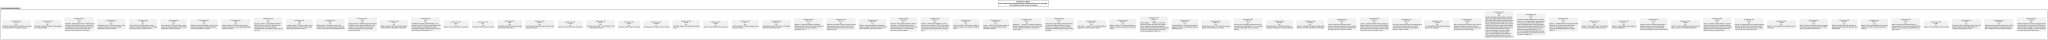

In [ ]:
%viz TechnicalIndividualsPackage --view tree

### ✅ `SystemPackage` — `Technical\SystemPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package SystemPackage {
	
	private import TechnicalComponentsPackage::*;
	private import TechnicalIndividualsPackage::*;
	private import CoSMAPackage::*;
	private import TechnicalPortsPackage::*;
	
	part def Apollo11MissionSystem :> SystemOfSystems {
		individual part launchVehicle : 'SA-506' :> constituentSystems;
		
		part spacecraft : ApolloSpacecraft :> constituentSystems {
			individual part csm : 'CSM-107' :>> commandServiceModule;
			individual part lm: 'LM-5' :>> lunarModule;
		}
		
		part spaceSuits[0..2] : ExtravehicularMobilityUnit :> constituentSystems;
		
		interface lvToPayload : LVPayloadInterface connect
			launchVehicle.instrumentUnit.payloadInterfacePort to spacecraft.spacecraftLMAdapter.launchVehicleInterfacePort;
	}
}

✅ SystemPackage loaded successfully (0.141s)


#### ✅ Visualization: `%viz SystemPackage --view tree`

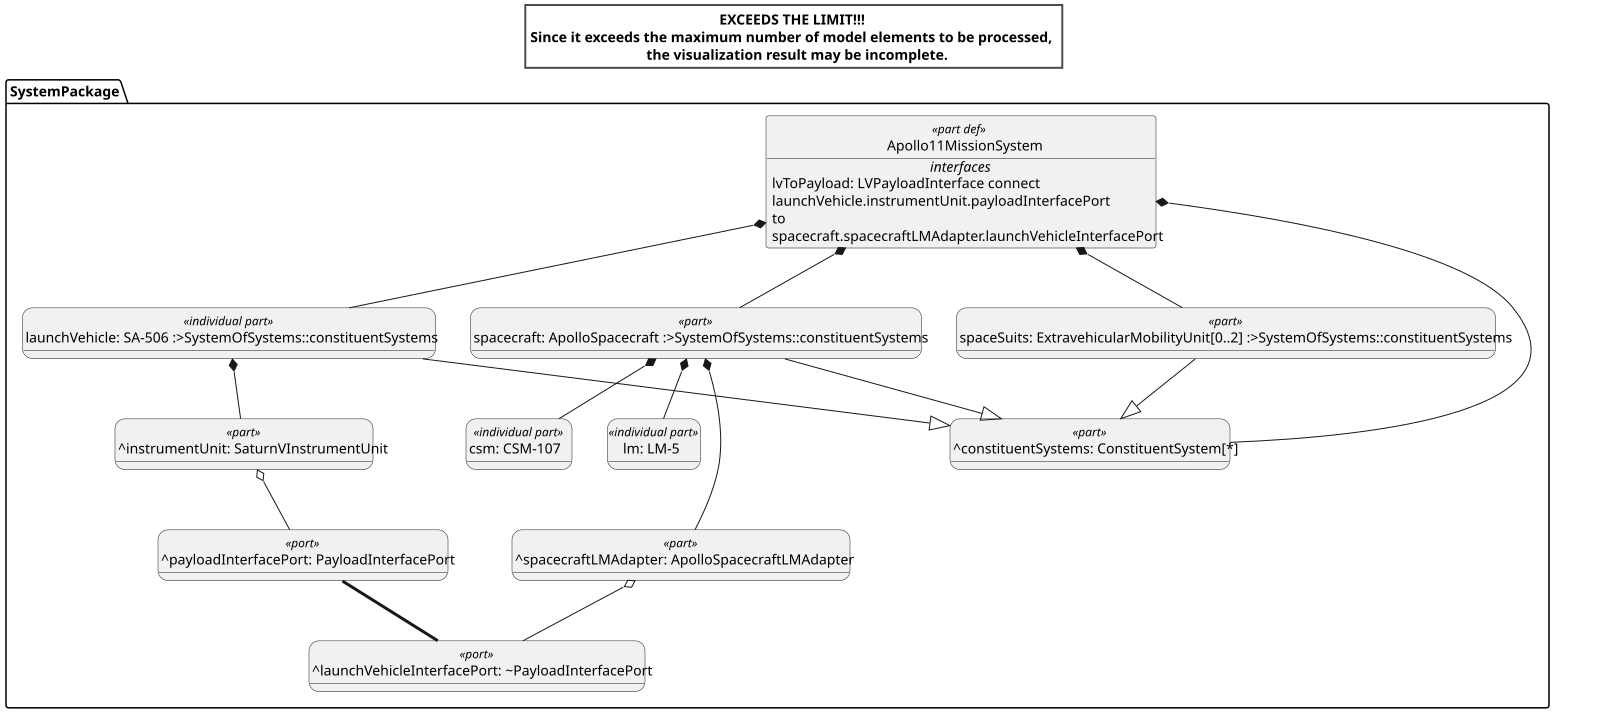

In [ ]:
%viz SystemPackage --view tree

### ✅ `MissionPackage` — `Purpose\MissionPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package MissionPackage {

	private import CoSMAPackage::*;
	private import MissionPhasesPackage::*;
	private import CapabilitiesPackage::*;
	private import SystemPackage::*;
	private import AstronautsPackage::*;
	private import FunctionsPackage::*;
	private import ContextPackage::*;
	private import CoSMAQuantitiesAndUnitsPackage::*;
	private import SI::*;
	private import ISQ::*;

	part def Apollo11Mission :> MannedSpaceMission {
		doc /* Apollo 11 was a spaceflight conducted from July 16 to 24, 1969, by the United States and launched by NASA. */
		
		comment source /* https://www.nasa.gov/history/apollo-11-mission-overview/ */
		
		part apollo11MissionSystem : Apollo11MissionSystem :> system;
		part apollo11MissionContext : Apollo11MissionContext :> context;
		part crew[1..*] : Astronaut, LogicalComponentsPackage::Crew :>> crew;

		perform action performLunarMission : PerformLunarMission;
		
		individual part commander : 'Neil Armstrong' :> crew;
		individual part commandModulePilot : 'Michael Collins' :> crew;
		individual part lunarModulePilot : 'Buzz Aldrin' :> crew;   
		
		attribute :>> plannedDuration = 195.3 [h];
			doc /* Known mission duration: 8 days, 3 hours, 18 minutes. */

		comment cost /* All costs are estimations and more a best guess */        
		attribute :>> researchAndDevelopmentCost = 5E9 ['$'];
		attribute :>> manufacturingCost = 3E9 ['$'];
		attribute :>> operationsCost = 1E9 ['$'];
		attribute :>> personnelCost = 2E9 ['$'];
		
		requirement goToMoon : Goal {
			doc /* Perform a crewed lunar landing and return to Earth. */
		} :> goals;
		requirement flag : Goal {
			doc /* Put a USA flag on the moon. */
		} :> goals;
		requirement samples : Goal {
			doc /* Gather samples of lunar-surface materials and bring them back to Earth. */
		} :> goals;
		requirement pictures : Goal {
			doc /* Extensively photograph the lunar terrain, the deployed scientific equipment, the LM spacecraft, and each other, both with still and motion picture cameras. */
		} :> goals;
		requirement deploy : Goal {
			doc /* Deployment of a television camera to transmit signals to Earth; and deployment of a solar wind composition experiment, seismic experiment package and a Laser Ranging Retroreflector. */
		} :> goals;

		exhibit state apollo11Phases {

			// Declare the states used in this specific state machine
			state initial : Initial;
			state preparation : PrepareForMissionPhase;
			state launch : LaunchPhase;
			state tli : TransLunarInjectionPhase;
			state tlc : TransLunarCoastPhase;
			state loi : LunarOrbitInsertionPhase;
			state lunarOpsDescentPrep : LunarOrbitOperationsDescentPreparationPhase;
			state poweredDescent : PoweredDescentPhase;
			state lunarSurfaceOps : LunarSurfaceOperationsPhase;
			state lunarAscentRendezvous : LunarAscentRendezvousPhase;
			state tei : TransEarthInjectionPhase;
			state tec : TransEarthCoastPhase;
			state reentryLanding : ReentryLandingPhase;
			state recoveryQuarantine : RecoveryQuarantinePhase;
			state final : MissionComplete;
			
			transition first initial then preparation;
			
			transition first preparation accept PreparationPhaseCompletedNotification then launch {
				doc /* if "all preparations concluded successfully"
					*/
			}


			transition first launch accept LaunchPhaseCompletedNotification then tli {
				doc /* if "Successful insertion into stable Earth parking orbit" and "All spacecraft systems verified 'nominal' or 'go' for TLI" and
					"Astronauts report systems nominal and ready for TLI" and
					"Ground stations confirm accurate tracking and TLI burn parameters"
					*/
			}

			transition first tli accept TransLunarInjectionPhaseCompletedNotification then tlc {
				doc /* if "Successful S-IVB TLI burn" and
					"Mission Control confirms free-return trajectory to Moon" and
					"Successful CSM separation, transposition, docking, and LM extraction" and
					"S-IVB stage successfully targeted for disposal"
					*/
			}

			transition first tlc accept TransLunarCoastPhaseCompletedNotification then loi {
				doc /* if "Spacecraft reaches precise LOI burn point" and
					"All CSM systems (SPS engine) verified 'green' and ready for LOI" and
					"Final navigation updates confirm precise trajectory and burn parameters" and
					"Astronauts completed pre-LOI checklists"
					*/
			}

			transition first loi accept LunarOrbitInsertionPhaseCompletedNotification then lunarOpsDescentPrep {
				doc /* if "Successful LOI burn, achieving stable lunar orbit" and
						"Mission Control confirms planned lunar orbit" and
						"Post-LOI checks confirm no anomalies"
					*/
			}

			transition  first lunarOpsDescentPrep accept LunarOrbitOperationsDescentPreparationPhaseCompletedNotification then poweredDescent {
				doc /* if "Astronauts transferred into LM and systems activated" and
					"LM successfully undocked from CSM (visual integrity confirmed)" and
					"Landing site deemed acceptable by crew and Mission Control" and
					"Final navigation updates confirm precise descent trajectory and targeting" and
					"Mission Control gives final 'GO' for Powered Descent"
					*/
			}

			transition first poweredDescent accept PoweredDescentPhaseCompletedNotification then lunarSurfaceOps {
				doc /* if "LM descent stage makes soft landing ('The Eagle has landed!')" and
					"LM integrity confirmed (upright, stable, systems nominal)" and
					"Astronauts safe, healthy, and ready for surface operations" and
					"Adequate consumables remain for abort or planned ascent" and
					"Crew provides initial observations of landing site"
					*/
			}

			transition first lunarSurfaceOps accept LunarSurfaceOperationsPhaseCompletedNotification then lunarAscentRendezvous {
				doc /* if "All planned EVA activities successfully completed" and
					"Both astronauts safely re-entered LM" and
					"LM cabin successfully repressurized" and
					"All LM ascent stage systems confirmed ready for launch" and
					"Sufficient power and propellant for ascent and rendezvous" and
					"Lunar orbital mechanics align for rendezvous"
					*/
			}

			transition first lunarAscentRendezvous accept LunarAscentRendezvousPhaseCompletedNotification then tei {
				doc /* if "LM ascent stage successfully launched and achieved stable lunar orbit" and
					"LM ascent stage successfully rendezvoused and docked with CSM" and
					"Armstrong, Aldrin, and lunar samples transferred back into CSM" and
					"LM ascent stage successfully undocked and jettisoned" and
					"CSM (with all three astronauts) confirmed ready for TEI burn"
					*/
			}

			transition first tei accept TransEarthInjectionPhaseCompletedNotification then tec {
				doc /* if "Successful TEI burn, achieving trans-Earth trajectory" and
					"Mission Control confirms proper return path to Earth" and
					"SPS engine is permanently shut down"
					*/
			}

			transition first tec accept TransEarthCoastPhaseCompletedNotification then reentryLanding {
				doc /* if "CM positioned correctly for atmospheric re-entry (separated from SM)" and
				"Final navigation updates confirm precise re-entry trajectory and landing zone" and
				"All Command Module re-entry systems verified 'go'" and
				"Recovery forces in position and landing zone clear"
				*/
			}

			transition first reentryLanding accept ReentryLandingPhaseCompletedNotification then recoveryQuarantine {
				doc /* if "CM splashes down safely in targeted recovery area" and
					"Astronauts report safe and healthy in capsule" and
					"CM flotation systems active and stable" and
					"Recovery forces have visually acquired CM"
					*/
			}

			transition first recoveryQuarantine accept RecoveryQuarantinePhaseCompletedNotification then final {
				doc /* if "Astronauts extracted to MQF, CM retrieved" and
					"Lunar samples secured and transferred to MQF" and
					"Preliminary health checks of astronauts nominal" and
					"21-day quarantine period officially begins"
					*/
			}

		} :>> phases;

		part programmaticAndPublicAffairsManagement:ProgrammaticAndPublicAffairsManagement :> requiredCapabilites;
		part heavyLiftLaunch:HeavyLiftLaunch :> requiredCapabilites;
		part multiStagePropulsion:MultiStagePropulsion :> requiredCapabilites;
		part precisionOrbitalMechanics:PrecisionOrbitalMechanics :> requiredCapabilites;
		part atmosphericReentryAndLanding:AtmosphericReentryAndLanding :> requiredCapabilites;
		part deepSpaceHabitationAndLifeSupport:DeepSpaceHabitationAndLifeSupport :> requiredCapabilites;
		part autonomousAndAssistedNavigationGuidanceAndControl:AutonomousAndAssistedNavigationGuidanceAndControl :> requiredCapabilites;
		part inSpacePropulsion:InSpacePropulsion :> requiredCapabilites;
		part powerGenerationAndDistribution:PowerGenerationAndDistribution :> requiredCapabilites;
		part lunarSurfaceLandingAndAscent:LunarSurfaceLandingAndAscent :> requiredCapabilites;
		part globalTrackingAndCommunication:GlobalTrackingAndCommunication :> requiredCapabilites;
		part realtimeMissionControl:RealtimeMissionControl :> requiredCapabilites;
		part contingencyPlanningAndRapidResponse:ContingencyPlanningAndRapidResponse :> requiredCapabilites;
		part crewTrainingAndSimulation:CrewTrainingAndSimulation :> requiredCapabilites;
		part humanPerformanceUnderExtremeStress:HumanPerformanceUnderExtremeStress :> requiredCapabilites;
		part complexSoftwareDevelopment:ComplexSoftwareDevelopment :> requiredCapabilites;
		part complexLogisticsAndIntegration:ComplexLogisticsAndIntegration :> requiredCapabilites;
		part launchOperationsManagement:LaunchOperationsManagement :> requiredCapabilites;
		part adaptabilityAndProblemSolving:AdaptabilityAndProblemSolving :> requiredCapabilites;
		part extravehicularActivitySupport:ExtravehicularActivitySupport :> requiredCapabilites;
		part lunarMobility:LunarMobility :> requiredCapabilites;
		part scientificDataAcquisitionAndSampleReturn:ScientificDataAcquisitionAndSampleReturn :> requiredCapabilites;
		part planetaryProtection:PlanetaryProtection :> requiredCapabilites;
		part robustCommunicationAndTelemetry:RobustCommunicationAndTelemetry :> requiredCapabilites;
		part toolDevelopment:ToolDevelopment :> requiredCapabilites;

		connection : CapabilityToGoalDerivation {
			end capa ::> programmaticAndPublicAffairsManagement;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> heavyLiftLaunch;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> multiStagePropulsion;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> precisionOrbitalMechanics;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> atmosphericReentryAndLanding;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> deepSpaceHabitationAndLifeSupport;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> autonomousAndAssistedNavigationGuidanceAndControl;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> inSpacePropulsion;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> powerGenerationAndDistribution;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> lunarSurfaceLandingAndAscent;
			end goal1 ::> goToMoon;
			end goal2 ::> samples;
			end goal3 ::> deploy;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> globalTrackingAndCommunication;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> realtimeMissionControl;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> contingencyPlanningAndRapidResponse;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> crewTrainingAndSimulation;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> humanPerformanceUnderExtremeStress;
			end goal1 ::> goToMoon;
			end goal2 ::> pictures;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> complexSoftwareDevelopment;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> complexLogisticsAndIntegration;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> launchOperationsManagement;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> adaptabilityAndProblemSolving;
			end goal ::> goToMoon;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> extravehicularActivitySupport;
			end goal1 ::> flag;
			end goal2 ::> samples;
			end goal3 ::> pictures;
			end goal4 ::> deploy;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> lunarMobility;
			end goal ::> flag;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> scientificDataAcquisitionAndSampleReturn;
			end goal1 ::> samples;
			end goal2 ::> pictures;
			end goal3 ::> deploy;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> planetaryProtection;
			end goal ::> samples;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> robustCommunicationAndTelemetry;
			end goal ::> pictures;
		} :> capabilityToGoals;
		connection : CapabilityToGoalDerivation {
			end capa ::> toolDevelopment;
			end goal ::> deploy;
		} :> capabilityToGoals;
	}
}

✅ MissionPackage loaded successfully (0.627s)


#### ✅ Visualization: `%viz MissionPackage --view tree`

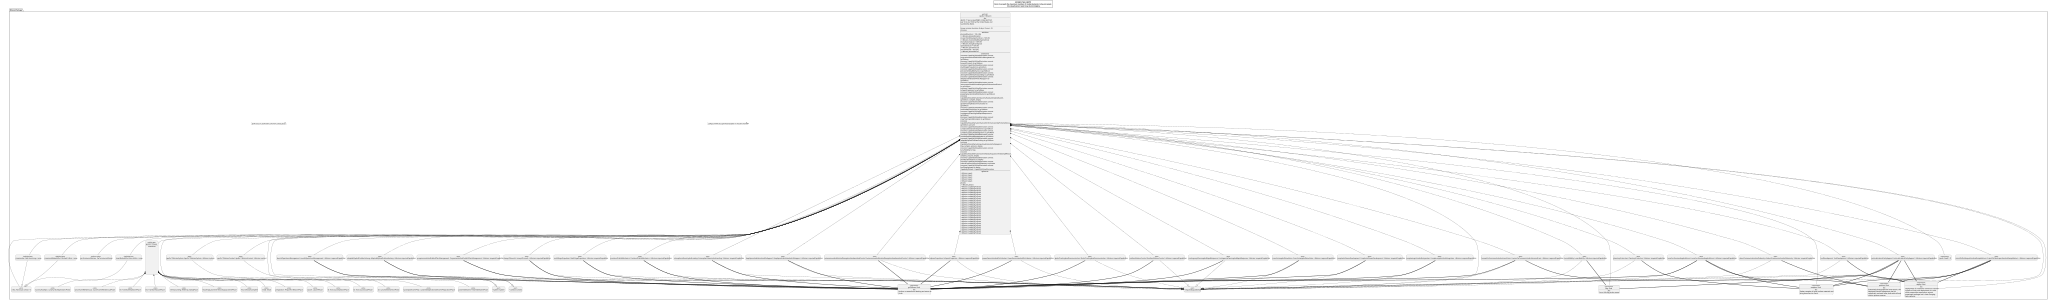

In [ ]:
%viz MissionPackage --view tree

### ✅ `SystemSpecificationPackage` — `Technical\SystemSpecificationPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package SystemSpecificationPackage {
	
	private import TechnicalRequirementsPackage::**;
	private import SystemPackage::*;
	
	requirement apollo11MissionSystemSpecification {
		doc /* Apollo 11 System requirements group */
		subject apollo11MissionSystem : Apollo11MissionSystem;
		
		requirement 'clr-R001' : SICEngineConfiguration;
		requirement 'clr-R002' : SICPropellantCompatibility;
		requirement 'clr-R003' : SICGimbalCapability;
		requirement 'clr-R026' : SICSeparationSystem;
		requirement 'clr-R004' : SIIEngineConfiguration;
		requirement 'clr-R005' : SIIPropellantType;
		requirement 'clr-R027' : SIIStructuralIntegrity;
		requirement 'clr-R006' : SIVBEngineConfiguration;
		requirement 'clr-R007' : SIVBRestartCapability;
		requirement 'clr-R028' : SIVBAttitudeControlSystem;
		requirement 'clr-R008' : IUGuidanceComputer;
		requirement 'clr-R009' : IUCommandAuthority;
		requirement 'clr-R029' : IUTelemetrySystem;
		requirement 'clr-R010' : LESPropulsionType;
		requirement 'clr-R011' : LESJettisonCapability;
		requirement 'clr-R012' : CMHabitableVolume;
		requirement 'clr-R013' : CMHeatShield;
		requirement 'clr-R014' : CMParachuteSystem;
		requirement 'clr-R030' : CMDockingMechanism;
		requirement 'clr-R015' : SMMainPropulsion;
		requirement 'clr-R016' : SMAttitudeControl;
		requirement 'clr-R017' : SMPowerGeneration;
		requirement 'clr-R031' : SMThermalControlSystem;
		requirement 'clr-R018' : LMDSThrottleableEngine;
		requirement 'clr-R019' : LMDSLandingGear;
		requirement 'clr-R032' : LMDSLaunchPlatform;
		requirement 'clr-R020' : LMASAscentEngine;
		requirement 'clr-R021' : LMASCrewCabin;
		requirement 'clr-R033' : LMASRendezvousRadar;
		requirement 'clr-R022' : PSAPressureContainment;
		requirement 'clr-R023' : PSAMobility;
		requirement 'clr-R034' : PSAHelmetVisibility;
		requirement 'clr-R024' : PLSSOxygenSupply;
		requirement 'clr-R025' : PLSSContaminantRemoval;
		requirement 'clr-R035' : PLSSCoolingSystem;
		requirement 'clr-R036' : StagingInterfaceLoadTransfer;
		requirement 'clr-R037' : StagingInterfaceCleanSeparation;
		requirement 'clr-R038' : GuidanceInterfaceCommandIntegrity;
		requirement 'clr-R039' : GuidanceInterfaceTelemetryLatency;
		requirement 'clr-R040' : CSMInterfacePowerTransfer;
		requirement 'clr-R041' : CSMInterfaceLifeSupportIntegrity;
		requirement 'clr-R042' : DockingInterfaceStructuralRigidity;
		requirement 'clr-R043' : DockingInterfacePressurizedSeal;
		requirement 'clr-R044' : LMStagingInterfaceSeparation;
		requirement 'clr-R045' : EVAInterfaceSecureConnection;
		requirement 'clr-R046' : LVPayloadInterfaceStructural;
		requirement 'clr-R047' : SLALMDeployment;
		requirement 'clr-R048' : LESInterfaceStructuralIntegrity;
		requirement 'clr-R049' : LESInterfaceCommandReliability;
		requirement 'clr-R050' : LMDSVelocityLimits;	
		requirement 'clr-R051' : CabinEnvironmentalControlRequirement;
		requirement 'clr-R052' : GNCGuidancePrecision;
		requirement 'clr-R053' : RCSControlStability;
		requirement 'clr-R054' : LMDSRadarPrecision;
		requirement 'clr-R056' : SPSIgnitionReliability;
		requirement 'clr-R057' : DPSThrottlingRange;
		requirement 'clr-R058' : LMASBurnDuration;
		requirement 'clr-R060' : CMHeatShieldThermalPerf;
		requirement 'clr-R067' : CommVideoBandwidth;
		requirement 'clr-R068' : EMUPressureContainment;
		requirement 'clr-R069' : EASEPOperationalDuration;
		requirement 'clr-R071' : FlightSoftwareDefectRate;
		requirement 'clr-R073' : MaterialVacuumResistance;
		requirement 'clr-R075' : ImageResolutionStandard;
		requirement 'clr-R076' : WasteStorageVolume;
		requirement 'clr-R077' : VHFAudioBandwidth;
		requirement 'clr-R078' : SystemRedundancyMapping;
		requirement 'clr-R079' : MedicalKitSpecification;
		requirement 'clr-R080' : GroundArchivalProtocol;
		requirement 'clr-R081' : CrewSeatLoadFactor;
		requirement 'clr-R082' : LaunchAbortThresholds;
		requirement 'clr-R083' : SeparationTimerPrecision;
		requirement 'clr-R084' : CabinPressureHold;
		requirement 'clr-R085' : TimingSynchError;
		requirement 'clr-R086' : EngineStartLatency;
		requirement 'clr-R087' : StagingShockLimit;
		requirement 'clr-R088' : CutoffDeltaVError;
		requirement 'clr-R089' : CockpitDisplayRefresh;
		requirement 'clr-R090' : TelemetrySamplingRate;
		requirement 'clr-R091' : PostTliSeparationVelocity;
		requirement 'clr-R092' : SlaSeparationVelocity;
		requirement 'clr-R093' : TranspositionManeuverRate;
		requirement 'clr-R094' : SextantAngularAccuracy;
		requirement 'clr-R095' : StateVectorIntegrationLatency;
		requirement 'clr-R096' : CommandTurnaroundLatency;
		requirement 'clr-R097' : GroundStationSensitivity;
		requirement 'clr-R098' : RelayNetworkBitErrorRate;
		requirement 'clr-R099' : TimelineDriftAlert;
		requirement 'clr-R100' : SleepAcousticLimit;
		requirement 'clr-R101' : TargetOrbitPerigee;
		requirement 'clr-R102' : HatchClearanceDimensions;
		requirement 'clr-R103' : LmComputerAlignmentTime;
		requirement 'clr-R104' : DockingLatchTorqueThreshold;
		requirement 'clr-R105' : UndockingSeparationVelocity;
		requirement 'clr-R106' : DskyDisplayBrightness;
		requirement 'clr-R107' : LandingRadarLockTime;
		requirement 'clr-R108' : PostLandingSafeTime;
		requirement 'clr-R109' : LmCabinIntegrityLeakRate;
		requirement 'clr-R110' : SymbolicMountRigidity;
		requirement 'clr-R111' : SampleToolMechanicalAdvantage;
		requirement 'clr-R112' : EasepThermalInsulation;
		requirement 'clr-R113' : EvaCommunicationRange;
		requirement 'clr-R114' : SurfaceTimelineSync;
		requirement 'clr-R115' : LmAscentDeltaVMinimum;
		requirement 'clr-R116' : RendezvousOrbitTarget;
		requirement 'clr-R117' : ReentryFlightPathAngle;			
		
		satisfy 'clr-R001' by apollo11MissionSystem.launchVehicle.stage1;
		satisfy 'clr-R002' by apollo11MissionSystem.launchVehicle.stage1;
		satisfy 'clr-R003' by apollo11MissionSystem.launchVehicle.stage1;
		satisfy 'clr-R004' by apollo11MissionSystem.launchVehicle.stage2;
		satisfy 'clr-R005' by apollo11MissionSystem.launchVehicle.stage2;
		satisfy 'clr-R006' by apollo11MissionSystem.launchVehicle.stage3;
		satisfy 'clr-R007' by apollo11MissionSystem.launchVehicle.stage3;
		satisfy 'clr-R008' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R009' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R010' by apollo11MissionSystem.spacecraft.launchEscapeSystem;
		satisfy 'clr-R011' by apollo11MissionSystem.spacecraft.launchEscapeSystem;
		satisfy 'clr-R012' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R013' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R014' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R015' by apollo11MissionSystem.spacecraft.csm.serviceModule;
		satisfy 'clr-R016' by apollo11MissionSystem.spacecraft.csm.serviceModule;
		satisfy 'clr-R017' by apollo11MissionSystem.spacecraft.csm.serviceModule;
		satisfy 'clr-R018' by apollo11MissionSystem.spacecraft.lm.lunarModuleDescentStage;
		satisfy 'clr-R019' by apollo11MissionSystem.spacecraft.lm.lunarModuleDescentStage;
		satisfy 'clr-R050' by apollo11MissionSystem.spacecraft.lm.lunarModuleDescentStage;
		satisfy 'clr-R020' by apollo11MissionSystem.spacecraft.lm.lunarModuleAscentStage;
		satisfy 'clr-R021' by apollo11MissionSystem.spacecraft.lm.lunarModuleAscentStage;
		satisfy 'clr-R022' by apollo11MissionSystem.spaceSuits.psa;
		satisfy 'clr-R023' by apollo11MissionSystem.spaceSuits.psa;
		satisfy 'clr-R024' by apollo11MissionSystem.spaceSuits.plss;
		satisfy 'clr-R025' by apollo11MissionSystem.spaceSuits.plss;
		satisfy 'clr-R026' by apollo11MissionSystem.launchVehicle.stage1;
		satisfy 'clr-R027' by apollo11MissionSystem.launchVehicle.stage2;
		satisfy 'clr-R028' by apollo11MissionSystem.launchVehicle.stage3;
		satisfy 'clr-R029' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R030' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R031' by apollo11MissionSystem.spacecraft.csm.serviceModule;
		satisfy 'clr-R032' by apollo11MissionSystem.spacecraft.lm.lunarModuleDescentStage;
		satisfy 'clr-R033' by apollo11MissionSystem.spacecraft.lm.lunarModuleAscentStage;
		satisfy 'clr-R034' by apollo11MissionSystem.spaceSuits.psa;
		satisfy 'clr-R035' by apollo11MissionSystem.spaceSuits.plss;
		satisfy 'clr-R036' by apollo11MissionSystem.launchVehicle.stage1ToStage2;
		satisfy 'clr-R036' by apollo11MissionSystem.launchVehicle.stage2ToStage3;
		satisfy 'clr-R037' by apollo11MissionSystem.launchVehicle.stage1ToStage2;
		satisfy 'clr-R037' by apollo11MissionSystem.launchVehicle.stage2ToStage3;
		satisfy 'clr-R038' by apollo11MissionSystem.launchVehicle.iuToStage3;
		satisfy 'clr-R039' by apollo11MissionSystem.launchVehicle.iuToStage3;
		satisfy 'clr-R040' by apollo11MissionSystem.spacecraft.csm.cmSMUmbilical;
		satisfy 'clr-R041' by apollo11MissionSystem.spacecraft.csm.cmSMUmbilical;
		satisfy 'clr-R042' by apollo11MissionSystem.spacecraft.cmLMDocking;
		satisfy 'clr-R043' by apollo11MissionSystem.spacecraft.cmLMDocking;
		satisfy 'clr-R044' by apollo11MissionSystem.spacecraft.lm.lmInterstage;
		satisfy 'clr-R045' by apollo11MissionSystem.spaceSuits.suitToPLSSUmbilical;	
		satisfy 'clr-R046' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R046' by apollo11MissionSystem.spacecraft.spacecraftLMAdapter;
		satisfy 'clr-R047' by apollo11MissionSystem.spacecraft.spacecraftLMAdapter;
		satisfy 'clr-R048' by apollo11MissionSystem.spacecraft.lesConnection;
		satisfy 'clr-R049' by apollo11MissionSystem.spacecraft.lesConnection;				
		satisfy 'clr-R050' by apollo11MissionSystem.spacecraft.lm.lunarModuleDescentStage;		

		satisfy 'clr-R086' by apollo11MissionSystem.launchVehicle.stage1;
		satisfy 'clr-R087' by apollo11MissionSystem.launchVehicle.stage2;
		satisfy 'clr-R088' by apollo11MissionSystem.launchVehicle.stage3;
		satisfy 'clr-R091' by apollo11MissionSystem.launchVehicle.stage3;
		
		satisfy 'clr-R008' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R052' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R071' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R082' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R085' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R090' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R094' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R095' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R114' by apollo11MissionSystem.launchVehicle.instrumentUnit;

		satisfy 'clr-R051' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R060' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R075' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R076' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R079' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R081' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R084' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R089' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R099' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R100' by apollo11MissionSystem.spacecraft.csm.commandModule;
		satisfy 'clr-R117' by apollo11MissionSystem.spacecraft.csm.commandModule;

		satisfy 'clr-R053' by apollo11MissionSystem.spacecraft.csm.serviceModule;
		satisfy 'clr-R056' by apollo11MissionSystem.spacecraft.csm.serviceModule;
		satisfy 'clr-R073' by apollo11MissionSystem.spacecraft.csm.serviceModule;
		satisfy 'clr-R078' by apollo11MissionSystem.spacecraft.csm.serviceModule;
		satisfy 'clr-R093' by apollo11MissionSystem.spacecraft.csm.serviceModule;
		satisfy 'clr-R101' by apollo11MissionSystem.spacecraft.csm.serviceModule;

		satisfy 'clr-R054' by apollo11MissionSystem.spacecraft.lm.lunarModuleDescentStage;
		satisfy 'clr-R057' by apollo11MissionSystem.spacecraft.lm.lunarModuleDescentStage;
		satisfy 'clr-R069' by apollo11MissionSystem.spacecraft.lm.lunarModuleDescentStage;
		satisfy 'clr-R107' by apollo11MissionSystem.spacecraft.lm.lunarModuleDescentStage;
		satisfy 'clr-R108' by apollo11MissionSystem.spacecraft.lm.lunarModuleDescentStage;
		satisfy 'clr-R112' by apollo11MissionSystem.spacecraft.lm.lunarModuleDescentStage;

		satisfy 'clr-R058' by apollo11MissionSystem.spacecraft.lm.lunarModuleAscentStage;
		satisfy 'clr-R067' by apollo11MissionSystem.spacecraft.lm.lunarModuleAscentStage;
		satisfy 'clr-R102' by apollo11MissionSystem.spacecraft.lm.lunarModuleAscentStage;
		satisfy 'clr-R103' by apollo11MissionSystem.spacecraft.lm.lunarModuleAscentStage;
		satisfy 'clr-R106' by apollo11MissionSystem.spacecraft.lm.lunarModuleAscentStage;
		satisfy 'clr-R109' by apollo11MissionSystem.spacecraft.lm.lunarModuleAscentStage;
		satisfy 'clr-R115' by apollo11MissionSystem.spacecraft.lm.lunarModuleAscentStage;
		satisfy 'clr-R116' by apollo11MissionSystem.spacecraft.lm.lunarModuleAscentStage;

		satisfy 'clr-R068' by apollo11MissionSystem.spaceSuits.psa;
		satisfy 'clr-R110' by apollo11MissionSystem.spaceSuits.psa;
		satisfy 'clr-R111' by apollo11MissionSystem.spaceSuits.psa;
		satisfy 'clr-R113' by apollo11MissionSystem.spaceSuits.psa;
		satisfy 'clr-R024' by apollo11MissionSystem.spaceSuits.plss;
		satisfy 'clr-R025' by apollo11MissionSystem.spaceSuits.plss;
		satisfy 'clr-R035' by apollo11MissionSystem.spaceSuits.plss;


		satisfy 'clr-R113' by apollo11MissionSystem.spacecraft.cmLMDocking;
		satisfy 'clr-R092' by apollo11MissionSystem.spacecraft.spacecraftLMAdapter;
		satisfy 'clr-R083' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R096' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R097' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R098' by apollo11MissionSystem.launchVehicle.instrumentUnit;
		satisfy 'clr-R080' by apollo11MissionSystem.launchVehicle.instrumentUnit;		
		
	}
}

✅ SystemSpecificationPackage loaded successfully (2.297s)


#### ✅ Visualization: `%viz SystemSpecificationPackage --view tree`

In [ ]:
%viz SystemSpecificationPackage --view tree

### ✅ `Apollo11MissionExecutionPackage` — `Execution\Apollo11MissionExecutionPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package Apollo11MissionExecutionPackage {
	
	private import SI::*;
	private import ISQ::*;
	private import Time::*;
	private import ScalarValues::*;
	private import MissionPackage::*;
	private import FunctionsPackage::*;
	private import SystemPackage::*;
	private import LogicalComponentsPackage::*;
	private import ContextPackage::*;
	private import OccurrenceFunctions::*;
	private import TechnicalComponentsPackage::*;
	private import AstronautsPackage::*;
	private import CoSMAQuantitiesAndUnitsPackage::*;

	individual part def Apollo11MissionIndividual :> Apollo11Mission {
		attribute crewReturnedSafely : ScalarValues::Boolean;
		attribute softLandingAchieved : ScalarValues::Boolean;
		attribute requiredSamplesReturned : ScalarValues::Boolean;
		attribute instrumentsDeployed : ScalarValues::Boolean;
	}

	individual part apollo11MissionIndividual : Apollo11MissionIndividual {
		doc /* A timeline representing the key events of the actual Apollo 11 mission from July 16, 1969, to July 24, 1969. */

		timeslice crewIngress {
			doc /* The flight crew enters the Command Module 'Columbia'. */
			assert constraint { isDuring(apollo11Phases.preparation) }
			snapshot atIngress {
				doc /* The flight crew begins entering the Command Module 'Columbia'. */
				attribute missionTime :> ISQ::time = -9000 ['s']; 
				snapshot missionSystemAtIngress :> apollo11MissionSystem {
					part :>> spaceSuits[2];
					part :>> spacecraft {
						part :>> csm {
							part :>> commandModule {
								attribute cabinPressure :> ISQ::pressure = 101 ['kPa'];
								attribute oxygenLevel :> ratio = 21['%'];
							}
						}
					}
				}
				snapshot groundSystemAtIngress :> context : Apollo11MissionContext {
					part :>> launchControlCenter {
						perform GroundSupportSystem::performCrewIngress :>> performCrewIngress;
					}	
				}
				snapshot crewAtIngress :> crew {
					attribute location: String = "Ingressing Command Module 'Columbia'";
					attribute status: String = "Performing pre-flight checks";
				}
			}
			snapshot atIngressComplete {
				doc /* Crew is secured and the Command Module hatch is sealed. */
				attribute missionTime :> ISQ::time = -3600 ['s'];
				snapshot missionSystemAtIngressComplete :> apollo11MissionSystem {
					part :>> spacecraft {
						part :>> csm {
							part :>> commandModule {
								attribute cabinPressure :> ISQ::pressure = 34 ['kPa'];
								attribute oxygenLevel :> ratio = 100['%'];
							}
						}
					}
				}
			}
		}
		
		then timeslice liftoff {
			doc /* This timeslice covers the ascent through Earth's atmosphere. */
			assert constraint { isDuring(apollo11Phases.launch) }
			snapshot atT0 {
				doc /* State Activation: LaunchPhase begins with liftoff. */
				attribute missionTime :> ISQ::time = 0 [s];
				snapshot missionSystemAtT0 :> apollo11MissionSystem {
					attribute velocity :> ISQ::speed = 0 ['m⋅s⁻¹'];
					part :>> launchVehicle {
						part :>> stage1 {
							attribute thrust :> ISQ::force = 35100 ['kN'];
						}
						perform LaunchSystem::provideStage1Thrust :>> provideStage1Thrust;
						perform LaunchSystem::guideAscentTrajectory :>> guideAscentTrajectory;
					}
					part :>> crew {
						perform Crew::observeAscentDataFromCockpit :>> observeAscentDataFromCockpit;
					}
				}
				snapshot groundSystemAtT0 :> context : Apollo11MissionContext {
					part :>> launchControlCenter {
						perform GroundSupportSystem::analyzeLaunchTelemetryFromGround :>> analyzeLaunchTelemetryFromGround;
					}
				}
			}
			snapshot atSICSeparation {
				doc /* Separation Event: The S-IC first stage separates. */
				attribute missionTime :> ISQ::time = 168 [s];
				snapshot missionSystemAtS1Sep :> apollo11MissionSystem {
					attribute velocity :> ISQ::speed = 2400 ['m⋅s⁻¹'];
					attribute altitude :> ISQ::length = 67 ['km'];
					part :>> launchVehicle {
						perform LaunchSystem::provideStage2Thrust :>> provideStage2Thrust;
					}
				}
			}
			snapshot atSIISeparation {
				doc /* Separation Event: The S-II second stage separates. */
				attribute missionTime :> ISQ::time = 540 [s];
				snapshot missionSystemAtS2Sep :> apollo11MissionSystem {
					attribute velocity :> ISQ::speed = 6800 ['m⋅s⁻¹'];
					attribute altitude :> ISQ::length = 185 ['km'];
					part :>> launchVehicle {
						perform LaunchSystem::provideOrbitInsertionThrust :>> provideOrbitInsertionThrust;
					}
				}
			}
		}

		then timeslice translunarInjection {
			doc /* This timeslice covers the burn to leave Earth orbit. */
			assert constraint { isDuring(apollo11Phases.tli) }
			snapshot atTLI {
				doc /* State Activation: TransLunarInjectionPhase begins with the S-IVB burn. */
				attribute missionTime :> ISQ::time = 10036 [s]; 
				snapshot missionSystemAtTLI :> apollo11MissionSystem {
					part :>> launchVehicle {
						part :>> stage3 {
							attribute engineStatus: String = "Burning";
						}
						perform LaunchSystem::provideTranslunarInjectionThrust :>> provideTranslunarInjectionThrust;
						perform LaunchSystem::controlTranslunarInjectionBurn :>> controlTranslunarInjectionBurn;
					}
				}
			}
			snapshot atTLIComplete {
				doc /* The TLI burn is complete, placing the vehicle on a translunar trajectory. */
				attribute missionTime :> ISQ::time = 10384 [s];
				snapshot missionSystemAtTLIEnd :> apollo11MissionSystem {
					attribute status: String = "Translunar trajectory established";
					attribute velocity :> ISQ::speed = 10840 ['m⋅s⁻¹'];
				}
			}
		}

		then timeslice transpositionAndDocking {
			doc /* This timeslice covers the CSM/LM docking and extraction maneuver. */
			assert constraint { isDuring(apollo11Phases.tli) }
			snapshot atCSMSeparation {
				doc /* Separation Event: The CSM separates from the S-IVB/SLA. */
				attribute missionTime :> ISQ::time = 11400 [s];
				snapshot missionSystemAtCSMSep :> apollo11MissionSystem {
					part :>> spacecraft {
						part :>> csm {
							attribute relativeVelocity :> ISQ::speed = 0.5 [m/s];
							attribute status: String = "Separated and maneuvering";
						}
						perform Spacecraft::provideAttitudeControlThrust :>> provideAttitudeControlThrust;
					}
					part :>> crew {
						perform Crew::executeTranspositionManeuver :>> executeTranspositionManeuver;
					}
				}
			}
			snapshot atCSLMDocking {
				doc /* The CSM has turned around and is docking with the LM. */
				attribute missionTime :> ISQ::time = 12000 [s];
				snapshot missionSystemAtDocking :> apollo11MissionSystem {
					part :>> spacecraft {
						part :>> csm {
							part :>> commandModule {
								attribute dockingProbeStatus: String = "Capture latches engaged";
							}
						}
						attribute status: String = "Soft docked";
						perform Spacecraft::mechanicallyLatchModules :>> mechanicallyLatchModules;
					}
					part :>> crew {
						perform Crew::connectSpacecraft :>> connectSpacecraft;
					}
				}
			}
			snapshot atExtractionComplete {
				doc /* The docked CSM and LM have been extracted from the S-IVB stage. */
				attribute missionTime :> ISQ::time = 14400 [s];
				snapshot missionSystemAtExtraction :> apollo11MissionSystem {
					part :>> spacecraft {
						attribute status: String = "Docked stack extracted";
					}
				}
			}
		}
		
		then timeslice translunarCoast {
			doc /* This timeslice represents the coast to the Moon. */
			assert constraint { isDuring(apollo11Phases.tlc) }
			snapshot atTLCStart {
				doc /* State Activation: TransLunarCoastPhase begins. */
				attribute missionTime :> ISQ::time = 14401 [s];
				snapshot missionSystemAtTLC :> apollo11MissionSystem {
					part :>> spacecraft {
						attribute status: String = "Passive thermal control (barbecue roll) initiated";
						perform Spacecraft::provideAttitudeControlThrust :>> provideAttitudeControlThrust;
					}
					part :>> crew {
						perform Crew::monitorOnboardSystems :>> monitorOnboardSystems;
					}
				}
			}
		}

		then timeslice lunarOrbitInsertion {
			doc /* This timeslice covers the maneuver to enter lunar orbit. */
			assert constraint { isDuring(apollo11Phases.loi) }
			snapshot atLOI {
				doc /* State Activation: LunarOrbitInsertionPhase begins with the LOI burn. */
				attribute missionTime :> ISQ::time = 273110 [s]; 
				snapshot missionSystemAtLOI :> apollo11MissionSystem {
					part :>> spacecraft {
						part :>> csm {
							part :>> serviceModule {
								attribute engineStatus: String = "Burning (SPS)";
								attribute fuelRemaining :> ISQ::mass = 18400 [kg];
							}
						}
						perform Spacecraft::provideLunarOrbitInsertionThrust :>> provideLunarOrbitInsertionThrust;
						perform Spacecraft::controlLunarOrbitInsertionBurn :>> controlLunarOrbitInsertionBurn;
					}
				}
			}
			snapshot atLOIComplete {
				doc /* The LOI burn is complete and the spacecraft is in a stable orbit. */
				attribute missionTime :> ISQ::time = 273470 [s];
				snapshot missionSystemAtLOIEnd :> apollo11MissionSystem {
					attribute status: String = "In stable elliptical lunar orbit";
					attribute orbitalParameters: String = "113km x 314km";
				}
			}
		}

		then timeslice descentPreparation {
			doc /* This timeslice covers checking out and undocking the LM. */
			assert constraint { isDuring(apollo11Phases.lunarOpsDescentPrep) }
			snapshot atDescentPrep {
				doc /* State Activation: LunarOrbitOperationsDescentPreparationPhase begins. */
				attribute missionTime :> ISQ::time = 352800 [s];
				snapshot missionSystemAtDescentPrep :> apollo11MissionSystem {
					part :>> spacecraft {
						part :>> lm {
							attribute powerStatus: String = "Activated on internal batteries";
						}
					}
					part :>> crew {
						perform Crew::performOrbitalSystemCheckouts :>> performOrbitalSystemCheckouts;
						perform Crew::prepareLanderForSeparation :>> prepareLanderForSeparation;
					}
				}
			}
			snapshot atLMUndocking {
				doc /* Separation Event: The LM undocks from the CSM. */
				attribute missionTime :> ISQ::time = 353100 [s]; 
				snapshot missionSystemAtUndocking :> apollo11MissionSystem {
					part :>> spacecraft {
						perform Spacecraft::separateLanderFromOrbiter :>> separateLanderFromOrbiter;
					}
				}
			}
		}

		then timeslice poweredDescent {
			doc /* This timeslice covers the powered descent to the lunar surface. */
			assert constraint { isDuring(apollo11Phases.poweredDescent) }
			snapshot atPDI {
				doc /* State Activation: PoweredDescentPhase begins with Powered Descent Initiation. */
				attribute missionTime :> ISQ::time = 360205 [s];
				snapshot missionSystemAtPDI :> apollo11MissionSystem {
					part :>> spacecraft {
						part :>> lm {
							part :>> lunarModuleDescentStage {
								attribute engineStatus: String = "Burning";
								attribute throttleLevel :> ratio = 90['%'];
							}
						}
						perform Spacecraft::executeDescentBurn :>> executeDescentBurn;
					}
				}
			}
			snapshot atLanding {
				doc /* The Lunar Module 'Eagle' touches down in the Sea of Tranquility. */
				attribute missionTime :> ISQ::time = 360940 [s]; 
				snapshot missionSystemAtLanding :> apollo11MissionSystem {
					part :>> spacecraft {
						part :>> lm {
							part :>> lunarModuleDescentStage {
								attribute engineStatus: String = "Shutdown";
								attribute propellantRemaining :> ISQ::mass = 45 [kg];
							}
						}
					}
					part :>> crew {
						perform Crew::manuallyPilotLander :>> manuallyPilotLander;
						perform Crew::performPostLandingCheck :>> performPostLandingCheck;
					}
				}
			}
			
			attribute :>> softLandingAchieved = true;
		}

		then timeslice lunarSurfaceOps {
			doc /* This timeslice covers the activities on the lunar surface. */
			assert constraint { isDuring(apollo11Phases.lunarSurfaceOps) }
			snapshot atEVAStart {
				doc /* State Activation: LunarSurfaceOperationsPhase begins with the first EVA. */
				attribute missionTime :> ISQ::time = 384300 [s]; 
				snapshot missionSystemAtEVAStart :> apollo11MissionSystem {
					part :>> spaceSuits[0] {
						attribute oxygenRemaining :> ISQ::duration = 6.5 ['h'];
						attribute status: String = "Nominal";
						perform EVASystem::provideIndividualLifesupport :>> provideIndividualLifesupport;
					}
					part :>> crew {
						part :>> commander {
							perform Crew::conductSurfaceExploration :>> conductSurfaceExploration;
							perform Crew::gatherLunarSamples :>> gatherLunarSamples;
							perform Crew::deploySurfaceExperiments :>> deploySurfaceExperiments;
						}
					}
				}
			}
			
			attribute :>> instrumentsDeployed = true;
			
			snapshot atEVAEnd {
				doc /* The EVA is complete and the crew are back inside the LM. */
				attribute missionTime :> ISQ::time = 393300 [s];
				snapshot missionSystemAtEVAEnd :> apollo11MissionSystem {
					part :>> spaceSuits[2];
					part :>> spacecraft {
						part :>> lm {
							attribute samplesStowed: Boolean = true;
							attribute cabinPressure :> ISQ::pressure = 34 ['kPa'];
						}
					}
					part :>> crew {
						perform Crew::completeExtravehicularActivity :>> completeExtravehicularActivity;
					}
				}
			}
		}

		then timeslice ascentAndRendezvous {
			doc /* This timeslice covers returning to lunar orbit and docking with the CSM. */
			assert constraint { isDuring(apollo11Phases.lunarAscentRendezvous) }
			snapshot atLunarLiftoff {
				doc /* State Activation: LunarAscentRendezvousPhase begins with liftoff from the Moon. */
				attribute missionTime :> ISQ::time = 447721 [s]; 
				snapshot missionSystemAtLunarLiftoff :> apollo11MissionSystem {
					part :>> spacecraft {
						perform Spacecraft::executeAscentBurn :>> executeAscentBurn;
					}
				}
			}
			snapshot atLunarDocking {
				doc /* The LM Ascent Stage has completed rendezvous and docks with the CSM. */
				attribute missionTime :> ISQ::time = 460200 [s];
				snapshot missionSystemAtDocking :> apollo11MissionSystem {
					attribute status: String = "Docked in lunar orbit, preparing for crew transfer";
					part :>> crew {
						perform Crew::connectSpacecraft :>> connectSpacecraft;
						perform Crew::transferCrewAndMaterials :>> transferCrewAndMaterials;
					}
				}
			}
		}

		then timeslice transearthInjection {
			doc /* This timeslice covers the burn to leave lunar orbit. */
			assert constraint { isDuring(apollo11Phases.tei) }
			snapshot atTEI {
				doc /* State Activation: TransEarthInjectionPhase begins with the TEI burn. */
				attribute missionTime :> ISQ::time = 478500 [s]; 
				snapshot missionSystemAtTEI :> apollo11MissionSystem {
					part :>> spacecraft {
						perform Spacecraft::executeTransearthBurn :>> executeTransearthBurn;
					}
				}
			}
		}
		
		then timeslice transearthCoast {
			doc /* This timeslice represents the coast back to Earth. */
			assert constraint { isDuring(apollo11Phases.tec) }
			snapshot atTECStart {
				doc /* State Activation: TransEarthCoastPhase begins. */
				attribute missionTime :> ISQ::time = 478651 [s];
				snapshot missionSystemAtTEC :> apollo11MissionSystem {
					part :>> spacecraft {
						attribute status: String = "Passive thermal control (barbecue roll) initiated";
					}
				}
			}
		}

		then timeslice reentryAndLanding {
			doc /* This timeslice covers the atmospheric entry and splashdown. */
			assert constraint { isDuring(apollo11Phases.reentryLanding) }
			snapshot atCMSMSeparation {
				doc /* Separation Event: The Command Module separates from the Service Module. */
				attribute missionTime :> ISQ::time = 688200 [s];
				snapshot missionSystemAtCMSMSep :> apollo11MissionSystem {
					part :>> spacecraft {
						perform Spacecraft::separateReturnCapsule :>> separateReturnCapsule;
					}
				}
			}
			snapshot atReentry {
				doc /* State Activation: ReentryLandingPhase begins as the CM hits the atmosphere. */
				attribute missionTime :> ISQ::time = 689100 [s]; 
				snapshot missionSystemAtReentry :> apollo11MissionSystem {
					part :>> spacecraft {
						part :>> csm {
							part :>> commandModule {
								attribute heatshieldTemp :> ISQ::thermodynamicTemperature = 2760 ['K'];
								attribute gForce :> ISQ::acceleration = 6.5 [gn];
							}
						}
						perform Spacecraft::guideAtmosphericEntry :>> guideAtmosphericEntry;
					}
				}
			}
			snapshot atSplashdown {
				doc /* The Command Module 'Columbia' splashes down in the Pacific Ocean. */
				attribute missionTime :> ISQ::time = 690395 [s]; 
				snapshot missionSystemAtSplashdown :> apollo11MissionSystem {
					part :>> spacecraft {
						perform Spacecraft::deployDecelerators :>> deployDecelerators;
						perform Spacecraft::performSplashdown :>> performSplashdown;
					}
				}
			}
		}
		
		then timeslice recoveryAndQuarantine {
			doc /* This timeslice covers the recovery of the crew. */
			assert constraint { isDuring(apollo11Phases.recoveryQuarantine) }
			snapshot atRecovery {
				doc /* State Activation: RecoveryQuarantinePhase begins with crew retrieval. */
				attribute missionTime :> ISQ::time = 693000 [s]; 
				snapshot groundSystemAtRecovery :> context : Apollo11MissionContext {
					part :>> recoveryForces {
						perform GroundSupportSystem::retrieveVehicleAndCrew :>> retrieveVehicleAndCrew;
						perform GroundSupportSystem::executeQuarantine :>> executeQuarantine;
					}
				}
			}
			snapshot atRecoveryComplete {
				doc /* The Command Module is hoisted aboard the recovery ship. */
				attribute missionTime :> ISQ::time = 694800 [s];
				snapshot missionSystemAtRecEnd :> apollo11MissionSystem {
					part :>> spacecraft {
						part :>> csm {
							part :>> commandModule {
								attribute status: String = "Secured on deck of USS Hornet";
							}
						}
					}
				}
			}
			
			attribute :>> crewReturnedSafely = true;
			attribute :>> requiredSamplesReturned = true;
		}
	}
}

✅ Apollo11MissionExecutionPackage loaded successfully (1.033s)


#### ✅ Visualization: `%viz Apollo11MissionExecutionPackage --view tree`

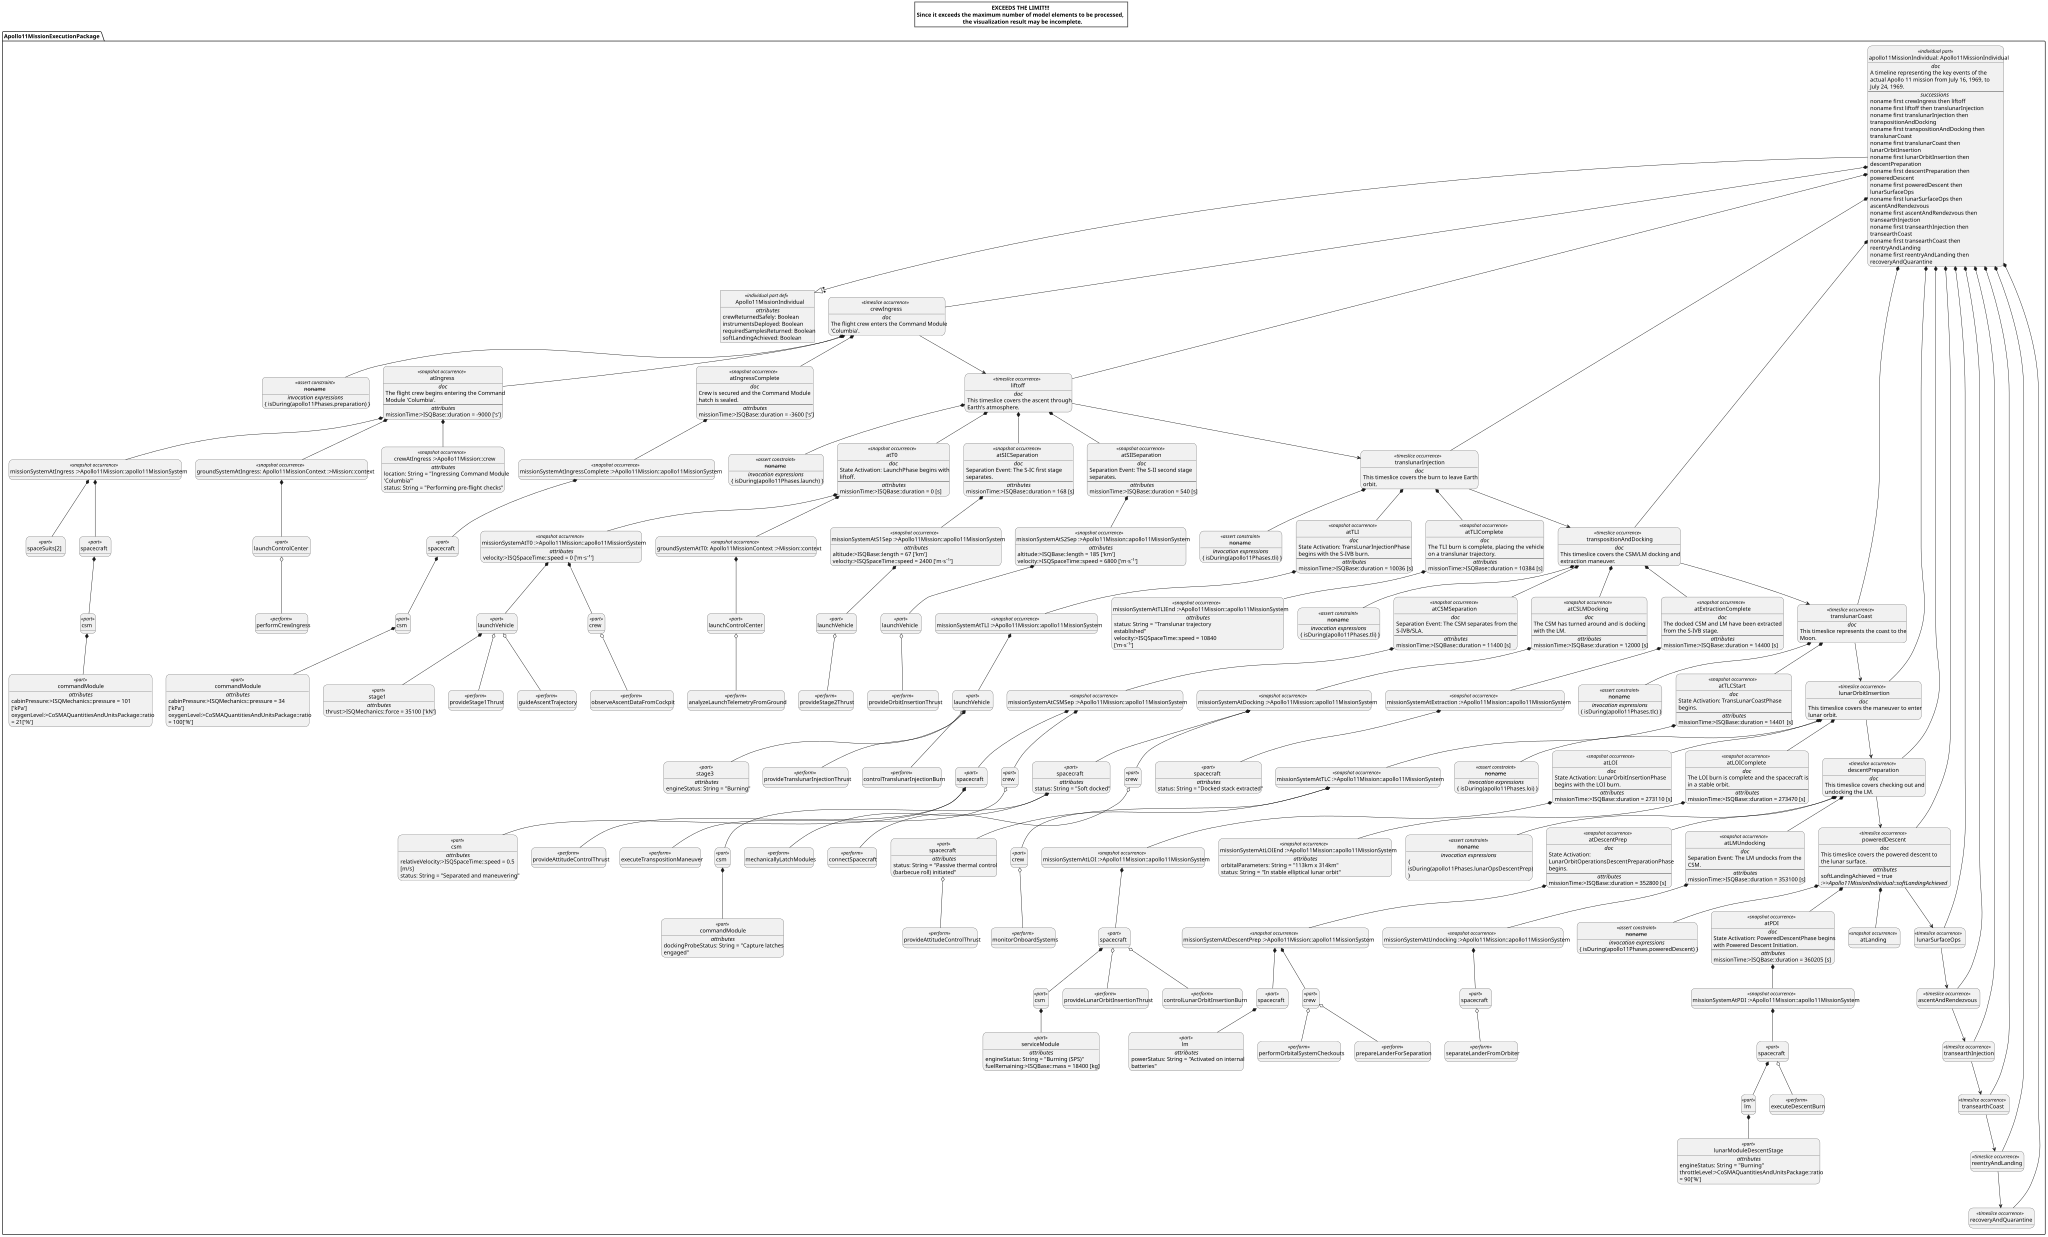

In [ ]:
%viz Apollo11MissionExecutionPackage --view tree

### ✅ `MissionSpecificationPackage` — `Purpose\MissionSpecificationPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package MissionSpecificationPackage {
	
	private import MissionRequirementsPackage::*;
	private import MissionPackage::*;
	private import OperationsPackage::*;
	
	requirement apollo11MissionSpecification {
		doc /* Apollo 11 Mission requirements group */
		subject apollo11Mission : Apollo11Mission;
		
		requirement 'hlr-R001' : CrewReturnSafetyRequirement;
		requirement 'hlr-R002' : LunarLanderSoftLandingRequirement;
		requirement 'hlr-R003' : TransLunarInjectionAccuracyRequirement;
		requirement 'hlr-R004' : CommunicationUptimeRequirement;
		requirement 'hlr-R006' : LunarSampleCollectionQuantityRequirement;
		requirement 'hlr-R007' : ScientificInstrumentDeploymentRequirement;
		requirement 'hlr-R008' : LunarVisualDocumentationRequirement;
		requirement 'hlr-R009' : NationalSymbolDeploymentRequirement;
		requirement 'hlr-R010' : PlanetaryProtectionQuarantineRequirement;
		requirement 'hlr-R026' : WasteManagementEffectiveness;
		requirement 'hlr-R028' : CrewSleepEnvironmentQuality;
		requirement 'hlr-R030' : CrewAlarmResponseTime;
		requirement 'hlr-R032' : LunarLanderToOrbiterVoiceComm;
		requirement 'hlr-R033' : ExtravehicularMobilityUnitLifeSupportDuration;
		requirement 'hlr-R035' : ExtravehicularMobilityUnitDexterityForTasks;
		requirement 'hlr-R036' : LunarSurfaceMobilityRange;
		requirement 'hlr-R037' : ExtravehicularActivityToolSecurity;
		requirement 'hlr-R038' : SamplePristinePreservation;
		requirement 'hlr-R040' : SampleGeologicalContext;
		requirement 'hlr-R045' : CriticalComponentRedundancy;
		requirement 'hlr-R046' : AbortSequenceExecutionTime;
		requirement 'hlr-R047' : ManualOverrideResponseTime;
		requirement 'hlr-R048' : GroundSegmentDataUpdateFrequency;
		requirement 'hlr-R049' : LunarLanderAscentReadinessTime;
		requirement 'hlr-R050' : FlightSoftwareUpdateTime;
		requirement 'hlr-R052' : CrewEmergencyMedicalProficiency;
		requirement 'hlr-R053' : InFlightProcedureErrorRate;
		requirement 'hlr-R054' : CrewNutritionAndHydration;
		requirement 'hlr-R055' : CrewPsychologicalState;
		requirement 'hlr-R057' : MicrometeoroidPenetrationRisk;
		requirement 'hlr-R059' : LunarElementEnvironmentalResistance;
		requirement 'hlr-R060' : PostFlightDataArchiving;

		requirement 'hlr-R005' : SustainedCabinHabitability;
		requirement 'hlr-R011' : TrajectoryNavigationPrecision;
		requirement 'hlr-R061' : PropulsionSystemMissionReliability;
		requirement 'hlr-R062' : MechanicalLoadResilience;
		requirement 'hlr-R063' : LiveVisualBroadcast;
		requirement 'hlr-R064' : ExtendedScientificOperation;
		requirement 'hlr-R065' : CriticalSystemAvailability;
		requirement 'hlr-R066' : PublicSupportAndAffairsManagement;
		requirement 'hlr-R067' : ElectricalPowerAvailability;
		requirement 'hlr-R068' : LaunchWindowPrecision;
		requirement 'hlr-R069' : OperationalWorkaroundProtocol;
		
		satisfy 'hlr-R001' by apollo11Mission.apollo11Phases.recoveryQuarantine.recoveryQuarantineOperations.retrieveCrewAndCM;
		satisfy 'hlr-R002' by apollo11Mission.apollo11Phases.poweredDescent.poweredDescentOperations.executePoweredDescentBurn;
		satisfy 'hlr-R003' by apollo11Mission.apollo11Phases.tli.tliPhaseOperations.executeTLIBurn;
		satisfy 'hlr-R004' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.communicateWithMissionControl;
		satisfy 'hlr-R006' by apollo11Mission.apollo11Phases.lunarSurfaceOps.lunarSurfaceOpsOperations.collectLunarSamples;
		satisfy 'hlr-R007' by apollo11Mission.apollo11Phases.lunarSurfaceOps.lunarSurfaceOpsOperations.deployScientificInstruments;
		satisfy 'hlr-R008' by apollo11Mission.apollo11Phases.lunarSurfaceOps.lunarSurfaceOpsOperations.performLunarEVA;
		satisfy 'hlr-R009' by apollo11Mission.apollo11Phases.lunarSurfaceOps.lunarSurfaceOpsOperations.performLunarEVA;
		satisfy 'hlr-R010' by apollo11Mission.apollo11Phases.recoveryQuarantine.recoveryQuarantineOperations.initiateQuarantineProcedures;
		satisfy 'hlr-R026' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.monitorSpacecraftSystems;
		satisfy 'hlr-R028' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.manageCrewRestPeriods;
		satisfy 'hlr-R030' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.monitorSpacecraftSystems;
		satisfy 'hlr-R032' by apollo11Mission.apollo11Phases.lunarSurfaceOps.lunarSurfaceOpsOperations.performLunarEVA;
		satisfy 'hlr-R033' by apollo11Mission.apollo11Phases.lunarSurfaceOps.lunarSurfaceOpsOperations.performLunarEVA;
		satisfy 'hlr-R035' by apollo11Mission.apollo11Phases.lunarSurfaceOps.lunarSurfaceOpsOperations.performLunarEVA;
		satisfy 'hlr-R036' by apollo11Mission.apollo11Phases.lunarSurfaceOps.lunarSurfaceOpsOperations.performLunarEVA;
		satisfy 'hlr-R037' by apollo11Mission.apollo11Phases.lunarSurfaceOps.lunarSurfaceOpsOperations.performLunarEVA;
		satisfy 'hlr-R038' by apollo11Mission.apollo11Phases.lunarSurfaceOps.lunarSurfaceOpsOperations.collectLunarSamples;
		satisfy 'hlr-R040' by apollo11Mission.apollo11Phases.lunarSurfaceOps.lunarSurfaceOpsOperations.collectLunarSamples;
		satisfy 'hlr-R045' by apollo11Mission.apollo11Phases.loi.loiPhaseOperations.executeLOIBurn;
		satisfy 'hlr-R046' by apollo11Mission.apollo11Phases.launch.launchPhaseOperations.executeLaunchSequence;
		satisfy 'hlr-R047' by apollo11Mission.apollo11Phases.poweredDescent.poweredDescentOperations.performManualPiloting;
		satisfy 'hlr-R048' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.communicateWithMissionControl;
		satisfy 'hlr-R049' by apollo11Mission.apollo11Phases.lunarAscentRendezvous.lunarAscentRendezvousOperations.executeLunarAscentBurn;
		satisfy 'hlr-R050' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.communicateWithMissionControl;
		satisfy 'hlr-R052' by apollo11Mission.apollo11Phases.preparation.prepareForMissionPhaseOperations.transferCrewToVehicle;
		satisfy 'hlr-R053' by apollo11Mission.apollo11Phases.lunarAscentRendezvous.lunarAscentRendezvousOperations.conductLMCSMDocking;
		satisfy 'hlr-R054' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.manageCrewRestPeriods;
		satisfy 'hlr-R055' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.manageCrewRestPeriods;
		satisfy 'hlr-R057' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.monitorSpacecraftSystems;
		satisfy 'hlr-R059' by apollo11Mission.apollo11Phases.lunarSurfaceOps.lunarSurfaceOpsOperations.deployScientificInstruments;
		satisfy 'hlr-R060' by apollo11Mission.apollo11Phases.recoveryQuarantine.recoveryQuarantineOperations;

		satisfy 'hlr-R005' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.monitorSpacecraftSystems;
		satisfy 'hlr-R005' by apollo11Mission.apollo11Phases.tec.tecPhaseOperations.monitorSpacecraftSystems;
		satisfy 'hlr-R011' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.conductMidCourseCorrections;
		satisfy 'hlr-R061' by apollo11Mission.apollo11Phases.loi.loiPhaseOperations.executeLOIBurn;
		satisfy 'hlr-R062' by apollo11Mission.apollo11Phases.launch.launchPhaseOperations.executeLaunchSequence;
		satisfy 'hlr-R063' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.communicateWithMissionControl;
		satisfy 'hlr-R063' by apollo11Mission.apollo11Phases.tec.tecPhaseOperations.communicateWithMissionControl;
		satisfy 'hlr-R064' by apollo11Mission.apollo11Phases.lunarSurfaceOps.lunarSurfaceOpsOperations.deployScientificInstruments;
		satisfy 'hlr-R065' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.monitorSpacecraftSystems;
		satisfy 'hlr-R065' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.monitorSpacecraftSystems;
		satisfy 'hlr-R066' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.communicateWithMissionControl;
		satisfy 'hlr-R066' by apollo11Mission.apollo11Phases.tec.tecPhaseOperations.communicateWithMissionControl;
		satisfy 'hlr-R067' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.monitorSpacecraftSystems;
		satisfy 'hlr-R067' by apollo11Mission.apollo11Phases.tlc.tlcPhaseOperations.monitorSpacecraftSystems;
		satisfy 'hlr-R068' by apollo11Mission.apollo11Phases.launch.launchPhaseOperations.performPreLaunchCountdown;
		satisfy 'hlr-R069' by apollo11Mission.apollo11Phases.poweredDescent.poweredDescentOperations.performManualPiloting;
	}
}

✅ MissionSpecificationPackage loaded successfully (0.915s)


#### ✅ Visualization: `%viz MissionSpecificationPackage --view tree`

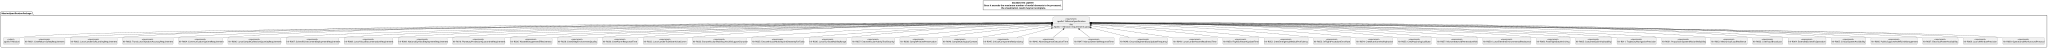

In [ ]:
%viz MissionSpecificationPackage --view tree

### ✅ `ProgramPackage` — `Program\ProgramPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package ProgramPackage {
	
	private import MissionPackage::*;
	private import CoSMAPackage::*;
	private import AstronautsPackage::*;

	part def ApolloProgram :> Program {
		doc /* The Apollo program, also known as Project Apollo, was the United States human spaceflight program led by NASA, which landed the first humans on the Moon in 1969. */
		
		part apollo11 : Apollo11Mission :> missions;
		
		//https://en.wikipedia.org/wiki/Apollo_program
		part 'as-201' : Mission {
			doc /* First flight of Saturn IB and Block I CSM; suborbital to Atlantic Ocean; qualified heat shield to orbital reentry speed. */
		} :> missions;
		part 'as-203' : Mission {
			doc /* No spacecraft; observations of liquid hydrogen fuel behavior in orbit to support design of S-IVB restart capability. */
		} :> missions;
		part 'as-202' : Mission {
			doc /* Suborbital flight of CSM to Pacific Ocean. */
		} :> missions;
		part apollo1 : MannedSpaceMission {
			doc /* Not flown. All crew members died in a fire during a launch pad test on January 27, 1967. */
			individual part : 'Gus Grissom' :> crew;
			individual part : 'Ed White' :> crew;
			individual part : 'Roger B. Chaffee' :> crew; 			
		} :> missions;
		part apollo4 : Mission {
			doc /* First test flight of Saturn V, placed a CSM in a high Earth orbit; demonstrated S-IVB restart; qualified CM heat shield to lunar reentry speed. */
		} :> missions;
		part apollo5 : Mission {
			doc /* Earth orbital flight test of LM, launched on Saturn IB; demonstrated ascent and descent propulsion; human-rated the LM. No crew. */
		} :> missions;
		part apollo6 : Mission {
			doc /* Uncrewed, second flight of Saturn V, attempted demonstration of trans-lunar injection, and direct-return abort using SM engine; three engine failures, including failure of S-IVB restart. Flight controllers used SM engine to repeat Apollo 4's flight profile. Human-rated the Saturn V. */
		} :> missions;
		part apollo7 : MannedSpaceMission {
			doc /* First crewed Earth orbital demonstration of Block II CSM, launched on Saturn IB. First live television broadcast from a crewed mission. */
			individual part : 'Wally Schirra' :> crew;
			individual part : 'Walt Cunningham' :> crew;
			individual part : 'Donn Eisele' :> crew; 				
		} :> missions;
		part apollo8 : MannedSpaceMission {
			doc /* First crewed flight of Saturn V; First crewed flight to Moon; CSM made 10 lunar orbits in 20 hours. */
			individual part : 'Frank Borman' :> crew;
			individual part : 'James Lovell' :> crew;
			individual part : 'William Anders' :> crew; 				
		} :> missions;
		part apollo9 : MannedSpaceMission {
			doc /* Second crewed flight of Saturn V; First crewed flight of CSM and LM in Earth orbit; demonstrated portable life support system to be used on the lunar surface. */
			individual part : 'James McDivitt' :> crew;
			individual part : 'David Scott' :> crew;
			individual part : 'Russell Schweickart' :> crew; 				
		} :> missions;
		part apollo10 : MannedSpaceMission {
			doc /* Dress rehearsal for first lunar landing; flew LM down to 50,000 ft (15 km; 9.5 mi) from lunar surface. */
			individual part : 'Thomas Stafford' :> crew;
			individual part : 'John Young' :> crew;
			individual part : 'Eugene Cernan' :> crew; 				
		} :> missions;
		part apollo12 : MannedSpaceMission {
			doc /* Second landing, in Ocean of Storms near Surveyor 3. Surface EVA time: 7h 45m. Samples returned: 75.62 lb (34.30 kg). */
			individual part : 'Pete Conrad' :> crew;
			individual part : 'Richard Gordon' :> crew;
			individual part : 'Alan Bean' :> crew; 				
		} :> missions;
		part apollo13 : MannedSpaceMission {
			doc /* Third landing attempt aborted in transit to the Moon, due to SM failure. Crew used LM as "lifeboat" to return to Earth. Mission called a "successful failure". */
			individual part : 'James Lovell' :> crew;
			individual part : 'Jack Swigert' :> crew;
			individual part : 'Fred Haise' :> crew; 				
		} :> missions;
		part apollo14 : MannedSpaceMission {
			doc /* Third landing, in Fra Mauro formation. Surface EVA time: 9h 21m. Samples returned: 94.35 lb (42.80 kg). */
			individual part : 'Alan Shepard' :> crew;
			individual part : 'Stuart Roosa' :> crew;
			individual part : 'Edgar Mitchell' :> crew; 				
		} :> missions;
		part apollo15 : MannedSpaceMission {
			doc /* Fourth landing, in Hadley-Apennine. First extended mission, used Rover on Moon. Surface EVA time: 18h 33m. Samples returned: 169.10 lb (76.70 kg). */
			individual part : 'David Scott' :> crew;
			individual part : 'Alfred Worden' :> crew;
			individual part : 'James Irwin' :> crew; 				
		} :> missions;
		part apollo16 : MannedSpaceMission {
			doc /* Fifth landing, in Plain of Descartes. Second extended mission, used Rover on Moon. Surface EVA time: 20h 14m. Samples returned: 207.89 lb (94.30 kg). */
			individual part : 'John Young' :> crew;
			individual part : 'Ken Mattingly' :> crew;
			individual part : 'Charles Duke' :> crew; 				
		} :> missions;
		part apollo17 : MannedSpaceMission {
			doc /* Only Saturn V night launch. Sixth landing, in Taurus-Littrow. Third extended mission, used Rover on Moon. First geologist on the Moon. Apollo's last crewed Moon landing. Surface EVA time: 22h 2m. Samples returned: 243.40 lb (110.40 kg). */
			individual part : 'Eugene Cernan' :> crew;
			individual part : 'Ronald Evans' :> crew;
			individual part : 'Harrison Schmitt' :> crew; 				
		} :> missions;
		
	}

}

✅ ProgramPackage loaded successfully (0.178s)


#### ✅ Visualization: `%viz ProgramPackage --view tree`

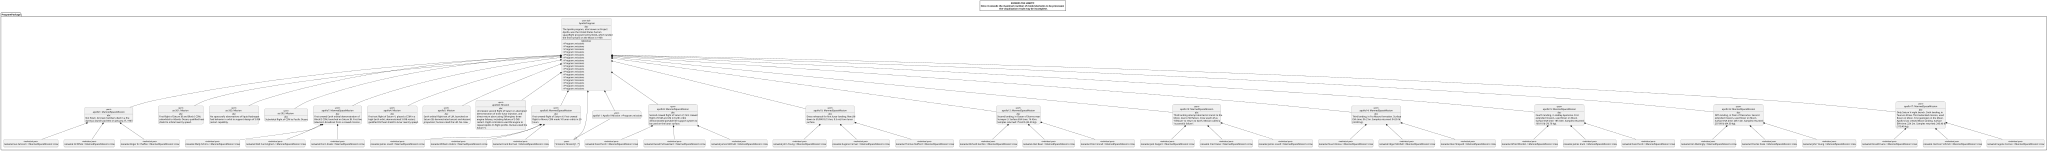

In [ ]:
%viz ProgramPackage --view tree

### ✅ `AnalysisPackage` — `Analysis\AnalysisPackage.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package AnalysisPackage {
	
	private import MissionPackage::*;
	private import CoSMAPackage::*;
	private import CoSMAQuantitiesAndUnitsPackage::*;
	private import CoSMAPackage::*;
	private import CalculationsPackage::*;
	private import ISQ::*;
	private import SI::*;
	private import TechnicalComponentsPackage::*;
	private import Apollo11MissionExecutionPackage::*;
	
	analysis def SystemPowerAnalysis {
		doc /* Analysis to calculate the total power generation, load, and margin for a composite system by iterating over its parts. */
		subject systemToAnalyze : System; 

		out totalPowerGenerated :> ISQ::power = rollupPowerGeneration(systemToAnalyze);
		out totalPowerLoad :> ISQ::power = rollupPowerConsumption(systemToAnalyze);
		out powerMargin :> ISQ::power = calculatePowerMargin(totalPowerGenerated, totalPowerLoad);

		assert constraint {
			powerMargin > 0[W]
		}
	}

	analysis Apollo11MissionSystemPowerAnalysis : SystemPowerAnalysis {
		doc /* Runs the iterative power analysis on the entire Apollo 11 Mission System. */

		subject apollo11MissionSystem : System;
	}
	
	analysis def SystemMassAnalysis {
		doc /* An analysis to track the total mass of the spacecraft throughout the mission (mass budget). */
		subject apollo11Mission : Apollo11Mission;

		in initialLaunchMass :> ISQ::mass;
		in propellantMassPerStage :> ISQ::mass[*];
		in jettisonedComponentMass :> ISQ::mass[*];
		out massAfterBurn :> ISQ::mass = calculateMassBudgetStep(initialLaunchMass, propellantMassPerStage, jettisonedComponentMass);
	}
	
	analysis Apollo11MissionSuccessAnalysis {
		doc /* A top-level analysis to evaluate whether the primary mission objectives were met. */
		subject apollo11Mission : Apollo11MissionIndividual;

		out overallMissionSuccess : ScalarValues::Boolean = evaluateMissionSuccess(apollo11Mission.crewReturnedSafely, apollo11Mission.softLandingAchieved, apollo11Mission.requiredSamplesReturned, apollo11Mission.instrumentsDeployed);
		
		assert constraint {
			overallMissionSuccess = true;
		}		
	}	
	
	analysis Apollo11LifecycleReliabilityAnalysis {
		doc /* An analysis to predict the probability of mission success based on the reliability of critical components over time. */
		subject apollo11Mission : Apollo11Mission;

		out cmReliability : RatioValue = calculateReliability(
			apollo11Mission.apollo11MissionSystem.spacecraft.csm.commandModule.failureRate,
			apollo11Mission.plannedDuration
		);
		out smReliability : RatioValue = calculateReliability(
			apollo11Mission.apollo11MissionSystem.spacecraft.csm.serviceModule.failureRate,
			apollo11Mission.plannedDuration
		);
		out lmReliability : RatioValue = calculateReliability(
			apollo11Mission.apollo11MissionSystem.spacecraft.lm.failureRate,
			apollo11Mission.plannedDuration / 2 // LM is only used for half the mission
		);
	}	
	
	analysis def MissionCostAnalysis {
		doc /* A budgetary analysis to determine the total financial cost of a mission. */
		subject mission : Mission;

		out totalMissionCost :> currency = sumCosts(mission.researchAndDevelopmentCost, mission.manufacturingCost, mission.operationsCost, mission.personnelCost);

	}
	
	analysis Apollo11MissionCostAnalysis : MissionCostAnalysis {
		subject apollo11Mission : Apollo11Mission;
	} 
	
	analysis Apollo11MissionDeltaVBudgetAnalysis {
		doc /* Performs a full delta-v budget analysis for the Apollo 11 mission to verify that the propulsive capabilities of the hardware can meet the demands of the mission trajectory. */
		
		subject apollo11Mission : Apollo11Mission;
		
		launchVehicle : SaturnV = apollo11Mission.apollo11MissionSystem.launchVehicle;
		spacecraft : ApolloSpacecraft = apollo11Mission.apollo11MissionSystem.spacecraft;
		
		sic = launchVehicle.stage1;
		sii = launchVehicle.stage2;
		sivb = launchVehicle.stage3;
		iu = launchVehicle.instrumentUnit;
		les = spacecraft.launchEscapeSystem;
		sla = spacecraft.spacecraftLMAdapter;
		cm = spacecraft.commandServiceModule.commandModule;
		sm = spacecraft.commandServiceModule.serviceModule;
		lmds = spacecraft.lunarModule.lunarModuleDescentStage;
		lmas = spacecraft.lunarModule.lunarModuleAscentStage;

		// Define mass stacks for each phase
		fullStack = (sii, sivb, iu, sla, sm, cm, lm);
		secondStageStack = (sivb, iu, sla, sm, cm, lm);
		tliStack = (sla, sm, cm, lm);
		spacecraftStack = (sm, cm, lm);
		
		// Calculate delta-v capability for each stage
		dv_stage1 = calculateLaunchStageDeltaV(sic, fullStack);
		dv_stage2 = calculateLaunchStageDeltaV(sii, secondStageStack);
		dv_stage3_tli = calculateLaunchStageDeltaV(sivb, spacecraftStack);
		
		dv_csm = calculateSpacecraftBurnDeltaV(sm);
		dv_lm_descent = calculateSpacecraftBurnDeltaV(lmds);
		dv_lm_ascent = calculateSpacecraftBurnDeltaV(lmas);
		
		// Required delta-v for phases
		dv_required_tli = calculateTliDeltaV(3.986E14 ['m³⋅s⁻²'], 6563 ['km'], 384400 ['km']);
		dv_required_loi = calculateLoiDeltaV(1000 ['m⋅s⁻¹'], 4.9E12 ['m³⋅s⁻²'], 1839 ['km']);
		dv_required_leo = 9400 ['m⋅s⁻¹'];
		dv_required_landing = 2100 ['m⋅s⁻¹'];
		dv_required_ascent = 1870 ['m⋅s⁻¹'];
		dv_required_tei = 1000 ['m⋅s⁻¹'];

		// S-IC and S-II combine to provide most of the velocity to orbit.
		ascentCapability = dv_stage1 + dv_stage2;
		ascentMargin = ascentCapability - dv_required_leo;
			
		// S-IVB performs the final orbit insertion and the TLI burn.
		tliMargin = dv_stage3_tli - dv_required_tli;
			
		// Service module performs LOI and TEI
		loiMargin = dv_csm - (dv_required_loi + dv_required_tei);
			
		// LM Descent Stage must have enough delta-v to land
		landingMargin = dv_lm_descent - dv_required_landing;
			
		// LM Ascent Stage must have enough delta-v to reach orbit
		ascentMargin_lunar = dv_lm_ascent - dv_required_ascent;

		// The mission is feasible if all margins are positive.
		assert constraint { 
			ascentMargin > 0 ['m⋅s⁻¹'] and
			tliMargin > 0 ['m⋅s⁻¹'] and
			loiMargin > 0 ['m⋅s⁻¹'] and
			landingMargin > 0 ['m⋅s⁻¹'] and
			ascentMargin_lunar > 0 ['m⋅s⁻¹']
		}
	}
}

✅ AnalysisPackage loaded successfully (0.577s)


#### ✅ Visualization: `%viz AnalysisPackage --view tree`

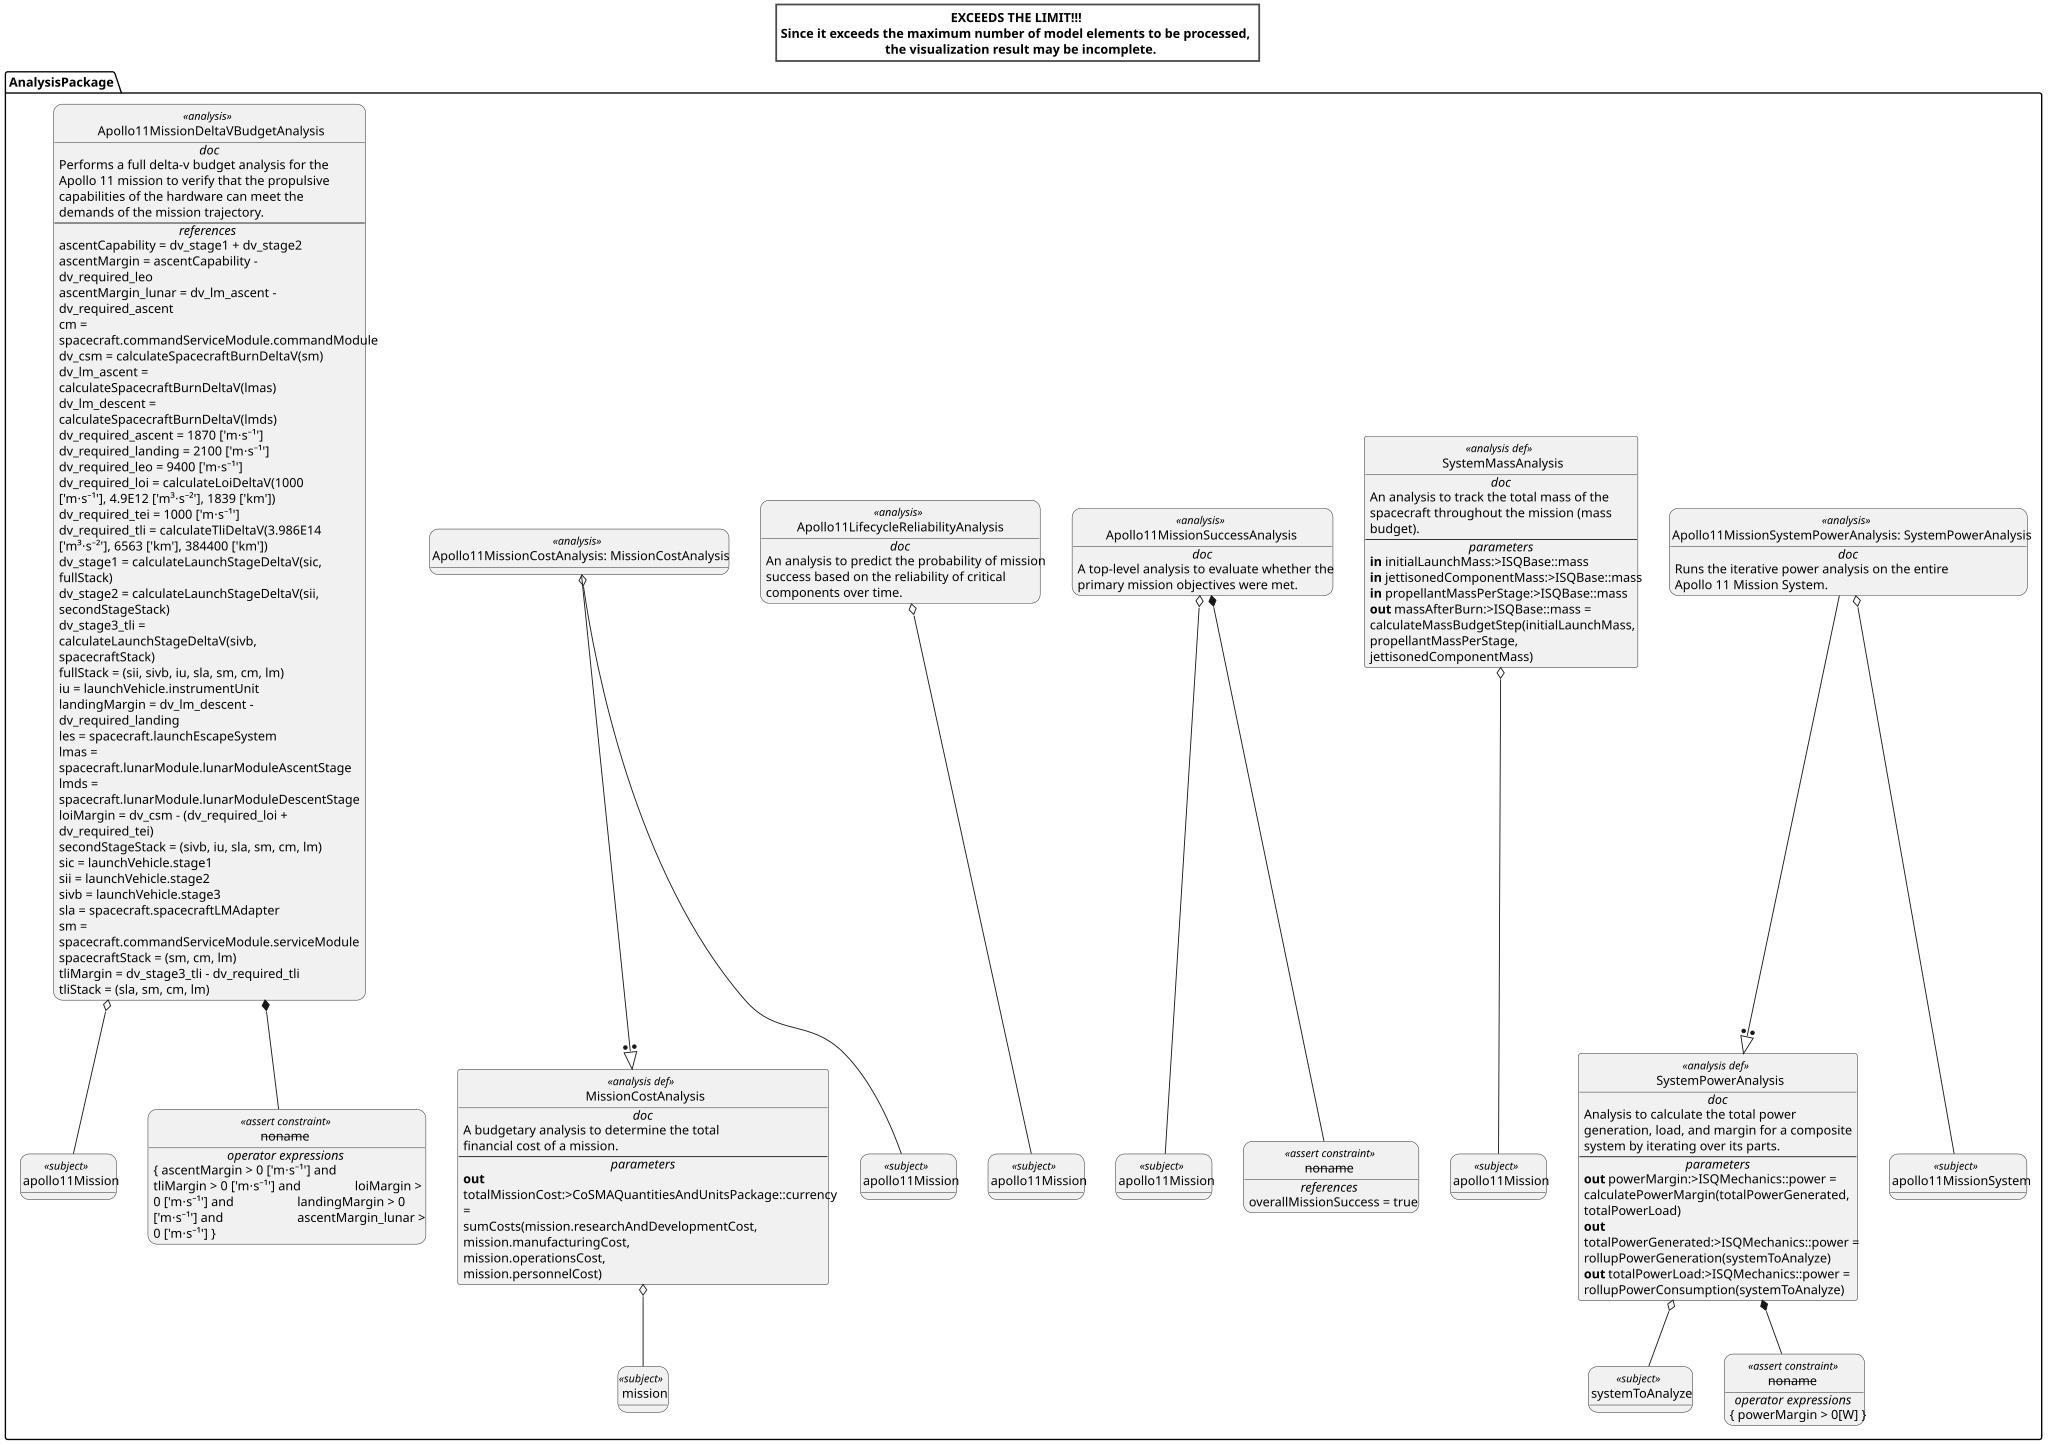

In [ ]:
%viz AnalysisPackage --view tree

### ✅ `Apollo11Model` — `Apollo11Model.sysml`

In [ ]:
//
// Copyright (c) 2026 AIRBUS and its affiliates.
// This Source Code Form is subject to the terms of the Mozilla Public
// License, v. 2.0. If a copy of the MPL was not distributed with this
// file, You can obtain one at http://mozilla.org/MPL/2.0/.
//

package Apollo11Model {
	
	//Analysis folder
	private import AnalysisPackage::*;
	private import CalculationsPackage::*;
	
	//CoSMA folder
	private import CoSMAPackage::*;
	private import CoSMAViewsPackage::*;
	private import CoSMAQuantitiesAndUnitsPackage::*;
	
	//Execution folder
	private import Apollo11MissionExecutionPackage::*;
	
	//Function folder
	private import FunctionsPackage::*;
	private import FunctionSpecificationPackage::*;
	
	//Logical folder
	private import LogicalComponentsPackage::*;
	
	//Purpose folder
	private import CapabilitiesPackage::*;
	private import ContextPackage::*;
	private import MissionPackage::*;
	private import MissionPhasesPackage::*;
	private import MissionSpecificationPackage::*;
	private import StakeholderPackage::*;
	
	//Operation folder
	private import OperationsPackage::*;
	
	//Program folder
	private import ProgramPackage::*;
	
	//Requirements folder
	private import FunctionalRequirementsPackage::*;
	private import MissionRequirementsPackage::*;
	private import StakeholderNeedsPackage::*;
	private import TechnicalRequirementsPackage::*;
	
	//Technical folder
	private import AstronautsPackage::*;
	private import SystemPackage::*;
	private import SystemSpecificationPackage::*;
	private import TechnicalComponentsPackage::*;
	private import TechnicalIndividualsPackage::*;
	private import TechnicalPortsPackage::*;
}

✅ Apollo11Model loaded successfully (0.12s)


#### ✅ Visualization: `%viz Apollo11Model --view tree`

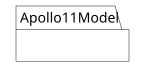

In [ ]:
%viz Apollo11Model --view tree

## Summary

| Package | Status | Time | Error |
|---------|--------|------|-------|
| `CoSMAQuantitiesAndUnitsPackage` | ✅ Pass | 0.991s | — |
| `TechnicalPortsPackage` | ✅ Pass | 0.322s | — |
| `CoSMAPackage` | ✅ Pass | 0.379s | — |
| `AstronautsPackage` | ✅ Pass | 0.442s | — |
| `OperationsPackage` | ✅ Pass | 0.128s | — |
| `StakeholderNeedsPackage` | ✅ Pass | 0.44s | — |
| `MissionPhasesPackage` | ✅ Pass | 0.541s | — |
| `CapabilitiesPackage` | ✅ Pass | 0.254s | — |
| `StakeholderPackage` | ✅ Pass | 0.492s | — |
| `MissionRequirementsPackage` | ✅ Pass | 1.443s | — |
| `CoSMAViewsPackage` | ✅ Pass | 0.118s | — |
| `FunctionalRequirementsPackage` | ✅ Pass | 1.353s | — |
| `FunctionsPackage` | ✅ Pass | 0.43s | — |
| `TechnicalRequirementsPackage` | ✅ Pass | 1.98s | — |
| `FunctionSpecificationPackage` | ✅ Pass | 2.415s | — |
| `LogicalComponentsPackage` | ✅ Pass | 0.193s | — |
| `ContextPackage` | ✅ Pass | 0.215s | — |
| `TechnicalComponentsPackage` | ✅ Pass | 0.647s | — |
| `CalculationsPackage` | ✅ Pass | 0.415s | — |
| `TechnicalIndividualsPackage` | ✅ Pass | 0.155s | — |
| `SystemPackage` | ✅ Pass | 0.141s | — |
| `MissionPackage` | ✅ Pass | 0.627s | — |
| `SystemSpecificationPackage` | ✅ Pass | 2.297s | — |
| `Apollo11MissionExecutionPackage` | ✅ Pass | 1.033s | — |
| `MissionSpecificationPackage` | ✅ Pass | 0.915s | — |
| `ProgramPackage` | ✅ Pass | 0.178s | — |
| `AnalysisPackage` | ✅ Pass | 0.577s | — |
| `Apollo11Model` | ✅ Pass | 0.12s | — |